# Overlap Group-Rep Retrieval Metrics

This notebook starts from the overlap-filtered `.h5ad` files produced by `scripts/build_overlap_filtered_h5ads.py`, uses the same matched-context reconstruction as `notebooks/overlap_group_rep_signature_similarity.ipynb`, and evaluates cross-dataset retrieval rather than direct matched-sample correlation. The reviewer analysis scores negative-L2, cosine, and Spearman retrieval together.

For each dataset pair and matched `cell_type + pert_time_h` stratum, it constructs a retrieval task between all retained non-control compound-dose conditions in that stratum.

Eligibility rules:
- each side must have at least `2` unique compounds in the stratum
- the target-side candidate pool must contain at least `5` conditions
- a query is scored only if it has at least one positive in the target pool under the chosen retrieval variant

Representations:
- signed significance: `-log10(adj.P.Value) * sign(logFC)`
- moderated `t`
- `logFC`

Similarity:
- the full original retrieval analysis uses negative Euclidean distance, i.e. similarity `S(i,j) = -||r_i - r_j||_2`
- a focused strict-matched-condition `logFC` ablation at the end reports negative Euclidean distance and cosine similarity side by side

Primary retrieval variant:
- **compound across doses**: positives are all target-side conditions with the same compound, regardless of dose

Sensitivity variants:
- **dose-aware compound retrieval**: positives are same-compound candidates with a raw-dose fold difference `max(dose_q / dose_t, dose_t / dose_q) <= 10`, with nearest-fold fallback if none exist
- **strict matched-condition retrieval**: positives are only the reciprocal-nearest-dose matches reconstructed by the overlap matching logic

For each query, the notebook reports:
- normalized best-positive rank
- Recall@1
- AUROC over positives vs wrong-compound negatives

Retrieval is done in both directions (`A -> B` and `B -> A`). Summaries are aggregated by:
1. query
2. `dataset pair + direction + cell_type + time` stratum
3. dataset-pair direction
4. symmetric dataset pair, averaging the two directions


In [1]:
from __future__ import annotations

from collections import defaultdict
from dataclasses import dataclass, field
from pathlib import Path
from typing import Optional
import itertools
import os

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.spatial.distance import cdist
from scipy.stats import rankdata


sns.set_theme(style="whitegrid")


In [2]:
# Set this to a list such as ["tahoe", "sciplex"] for an isolated test run.
# Leave it as None for the production dataset set and production output directory.
DATASET_SUBSET_ENV = os.environ.get("CPB_DATASET_SUBSET", "").strip()
TEST_DATASET_SUBSET = (
    None
    if not DATASET_SUBSET_ENV
    else [value.strip() for value in DATASET_SUBSET_ENV.split(",") if value.strip()]
)

def find_repo_root(start=None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "results" / "overlap_filtered_h5ads").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")


REPO_ROOT = find_repo_root()

import sys

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from scripts.notebook_cache import (
    ProgressReporter,
    cache_summary,
    cached_frame,
    force_recompute,
    frame_identity_fingerprint,
    is_cached,
    stable_json_fingerprint,
)
import scripts.cross_source_core as cross_source_core
from scripts.cross_source_strata import SignatureStratum

ANALYSIS_PROFILE = "retrieval"
PRODUCTION_DATASET_ORDER = cross_source_core.production_dataset_order(ANALYSIS_PROFILE)
DATASET_ORDER = cross_source_core.selected_dataset_order(ANALYSIS_PROFILE, TEST_DATASET_SUBSET)
DISPLAY_LABELS = dict(cross_source_core.DISPLAY_LABELS)
MATCH_SETTINGS = cross_source_core.DEFAULT_MATCH_SETTINGS
MAX_DOSE_FOLD_DIFFERENCE = MATCH_SETTINGS.max_dose_fold_difference
MIN_CONTEXT_SHARED_DRUGS = MATCH_SETTINGS.min_context_shared_drugs
TOP_K = cross_source_core.TOP_K
NUMERIC_SIG_FIGS = cross_source_core.NUMERIC_SIG_FIGS
INVALID_STRING_VALUES = cross_source_core.INVALID_STRING_VALUES

DATA_ROOT = REPO_ROOT / "data" / "theislab_temp"
SOURCE_DATASET_DIRS = cross_source_core.source_dataset_dirs(DATA_ROOT, ANALYSIS_PROFILE)
OVERLAP_DIR = REPO_ROOT / "results" / "overlap_filtered_h5ads"
PRODUCTION_OUTPUT_DIR = REPO_ROOT / "results" / "overlap_group_rep_retrieval_metrics"
RUN_TAG = os.environ.get("CPB_RUN_TAG", "").strip()
OUTPUT_DIR = cross_source_core.analysis_output_dir(
    PRODUCTION_OUTPUT_DIR,
    dataset_subset=TEST_DATASET_SUBSET,
    dataset_names=DATASET_ORDER,
    run_tag=RUN_TAG,
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repository root: {REPO_ROOT}")
print(f"Data root: {DATA_ROOT}")
print(f"Overlap directory: {OVERLAP_DIR}")
print(f"Datasets selected: {', '.join(DATASET_ORDER)}")
print(f"Output directory: {OUTPUT_DIR}")


# --- Resumability -----------------------------------------------------------------
# Expensive stages below go through cached_frame: if the stage's output TSV already
# exists it is reloaded instead of recomputed, so this notebook can be restarted after
# a crash without redoing completed stages.
#
#   force_recompute("retrieval_ablation") # rebuild one stage
#   CPB_FORCE_RECOMPUTE=all jupyter lab    # ignore every cache
# Deleting a stage's TSV has the same effect as naming it.
# Stages here: matched_pairs, primary_retrieval, retrieval_ablation, focused_retrieval,
# ablation_ci, null_calibration, null_ci, w4_retrieval_metrics, and w4_retrieval_ci.


Repository root: /home/cirro/Chem-PerturBridge_analysis
Data root: /home/cirro/Chem-PerturBridge_analysis/data/theislab_temp
Overlap directory: /home/cirro/Chem-PerturBridge_analysis/results/overlap_filtered_h5ads
Datasets selected: tahoe, sciplex
Output directory: /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_retrieval_metrics/tahoe__sciplex


In [3]:
# Shared cross-source utilities.
pretty_label = cross_source_core.pretty_label
format_numeric = cross_source_core.format_numeric


In [4]:
# One shared source catalog owns backed H5AD handles and gene-position caches.
SOURCE_CATALOG = cross_source_core.LineSourceCatalog(SOURCE_DATASET_DIRS)
LineSource = cross_source_core.LineSource
resolve_line_path = SOURCE_CATALOG.resolve_line_path
get_line_source = SOURCE_CATALOG.get_line_source
shared_gene_positions = SOURCE_CATALOG.shared_gene_positions
set_global_shared_gene_keys = SOURCE_CATALOG.set_global_shared_gene_keys
global_gene_positions = SOURCE_CATALOG.global_gene_positions
close_all_line_sources = SOURCE_CATALOG.close

# Compatibility aliases used by the metric-specific cells below.
filter_finite_pair = cross_source_core.filter_finite_pair
signed_spearman = cross_source_core.signed_spearman
signed_overlap_at_k = cross_source_core.signed_overlap_at_k
score_signature_pair = cross_source_core.score_signature_pair
mean_available = cross_source_core.mean_available
empty_score_dict = cross_source_core.empty_score_dict


In [5]:
cross_source_scope = cross_source_core.prepare_cross_source_scope(
    dataset_order=DATASET_ORDER,
    overlap_dir=OVERLAP_DIR,
    output_dir=OUTPUT_DIR,
    source_catalog=SOURCE_CATALOG,
    settings=MATCH_SETTINGS,
)
dataset_indices = cross_source_scope.dataset_indices
active_datasets = cross_source_scope.active_datasets
retained_lines = cross_source_scope.retained_lines
matched_pairs = cross_source_scope.matched_pairs
MATCHED_PAIRS_FINGERPRINT = cross_source_scope.matched_pairs_fingerprint
matched_lines = cross_source_scope.matched_lines
matched_active_datasets = cross_source_scope.matched_active_datasets
global_gene_lines = cross_source_scope.global_gene_lines
line_global_gene_keys = cross_source_scope.line_global_gene_keys
pair_match_summary = cross_source_scope.pair_match_summary
line_match_summary = cross_source_scope.line_match_summary

print("Datasets in scope:", ", ".join(
    pretty_label(dataset_name) for dataset_name in active_datasets
))
retained_lines_display = pd.DataFrame(
    {
        "dataset": [pretty_label(name) for name in retained_lines],
        "cell_types": [", ".join(lines) for lines in retained_lines.values()],
    }
)
display(retained_lines_display)

line_global_gene_counts = {
    cell_type: int(gene_keys.size)
    for cell_type, gene_keys in line_global_gene_keys.items()
}
n_opened_gene_sources = sum(len(lines) for lines in global_gene_lines.values())
n_available_gene_sources = sum(len(lines) for lines in retained_lines.values())
print(
    f"Line-specific shared-gene sets computed for {len(line_global_gene_counts):,} "
    f"matched cell types using {n_opened_gene_sources:,}/{n_available_gene_sources:,} "
    "available line sources."
)
if not line_global_gene_counts or max(line_global_gene_counts.values()) < 2:
    print(
        "Line-specific shared-gene evaluation will be unavailable because no "
        "matched line has at least two genes shared across the datasets that retain it."
    )
else:
    print(
        "Line-specific shared-gene count range across matched lines: "
        f"{min(line_global_gene_counts.values()):,} to "
        f"{max(line_global_gene_counts.values()):,}"
    )

pair_match_summary_display = pair_match_summary.copy()
pair_match_summary_display["dataset_a"] = pair_match_summary_display["dataset_a"].map(pretty_label)
pair_match_summary_display["dataset_b"] = pair_match_summary_display["dataset_b"].map(pretty_label)
display(pair_match_summary_display)

line_match_summary_display = line_match_summary.copy()
line_match_summary_display["dataset_a"] = line_match_summary_display["dataset_a"].map(pretty_label)
line_match_summary_display["dataset_b"] = line_match_summary_display["dataset_b"].map(pretty_label)
display(line_match_summary_display)


Datasets in scope: Tahoe-100M, sci-Plex


,dataset,cell_types
0,Tahoe-100M,"CVCL_0023, CVCL_0320, CVCL_0332"
1,sci-Plex,"CVCL_0023, CVCL_0031"


Line-specific shared-gene sets computed for 4 retained lines.
Line-specific shared-gene count range across retained lines: 6,742 to 19,824
Saved matched sample pairs to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_retrieval_metrics/tahoe__sciplex/matched_sample_pairs.tsv


,dataset_a,dataset_b,n_matched_sample_pairs,n_matching_drugs,n_matching_lines,n_matching_conditions
0,Tahoe-100M,sci-Plex,170,23,1,69


,dataset_a,dataset_b,cell_type,n_matched_sample_pairs,n_matching_drugs,n_matching_conditions
0,Tahoe-100M,sci-Plex,CVCL_0023,170,23,69


**Retrieval Definitions**

For a fixed dataset pair and matched `cell_type + time_key` stratum, every retained condition in dataset A is queried against all retained conditions in dataset B within that same stratum.

The primary task is compound retrieval across doses. For query `i`, the positive set is all target-side conditions with the same `pubchem_cid`.

Scores:
- normalized best-positive rank: `1` is best and `0` is worst; its random expectation depends on both candidate-pool size and the number of positives and is calibrated exactly below
- Recall@1
- AUROC with same-compound conditions as positives and other compounds as negatives

The legacy retrieval tables use negative Euclidean distance on the chosen representation vector. The focused reviewer analysis below reruns strict-condition `logFC` retrieval with negative-L2, cosine, and Spearman similarity on the same query and candidate pools.

Additional baseline retrieval score:
- for each query, build a same-dataset baseline candidate by averaging all other compounds with the same `cell_type + time_key + dose_key`
- append that single baseline candidate to the cross-dataset target pool
- score the real query against `target pool ∪ {baseline candidate}`
- the baseline metrics report the rank of that injected baseline candidate within the augmented pool
- `observed - baseline` therefore compares the rank of the true cross-dataset match against the rank of the within-dataset baseline candidate


In [6]:
RETRIEVAL_VARIANTS = {
    "compound_across_doses": "Compound retrieval across doses",
    "dose_aware_compound": "Dose-aware compound retrieval",
    "strict_matched_condition": "Strict matched-condition retrieval",
}
REPRESENTATION_LABELS = {
    "signed_significance": "Signed significance",
    "moderated_t": "Moderated t",
    "logFC": "logFC",
}
MIN_TARGET_CANDIDATES = 5
MIN_UNIQUE_COMPOUNDS_PER_SIDE = 2
ADJ_PVALUE_LAYER_PREFERENCES = (
    "adj.P.Value.within_one_contrast",
    "adj.P.Value.across_all_contrasts",
)


get_adjusted_pvalue_layer = lambda source: (
    cross_source_core.first_available_layer(
        source,
        ADJ_PVALUE_LAYER_PREFERENCES,
    )
)


def signed_significance(logfc: np.ndarray, adj_p: np.ndarray) -> np.ndarray:
    adj_p = np.asarray(adj_p, dtype=np.float64)
    logfc = np.asarray(logfc, dtype=np.float64)
    return -np.log10(np.clip(adj_p, 1e-300, None)) * np.sign(logfc)


def negative_l2_similarity_matrix(query_matrix: np.ndarray, candidate_matrix: np.ndarray) -> np.ndarray:
    query_matrix = np.asarray(query_matrix, dtype=np.float64)
    candidate_matrix = np.asarray(candidate_matrix, dtype=np.float64)
    # cdist avoids a query x candidate x gene broadcast allocation.
    return -cdist(query_matrix, candidate_matrix, metric="euclidean")


def normalized_best_positive_rank(scores: np.ndarray, positive_mask: np.ndarray) -> tuple[float, float]:
    positive_mask = np.asarray(positive_mask, dtype=bool)
    scores = np.asarray(scores, dtype=np.float64)
    if scores.size < 2 or int(positive_mask.sum()) == 0:
        return float("nan"), float("nan")
    ranks = rankdata(-scores, method="min")
    best_rank = float(np.min(ranks[positive_mask]))
    normalized_rank = 1.0 - ((best_rank - 1.0) / (len(scores) - 1.0))
    return float(best_rank), float(normalized_rank)


def recall_at_1(scores: np.ndarray, positive_mask: np.ndarray) -> float:
    positive_mask = np.asarray(positive_mask, dtype=bool)
    scores = np.asarray(scores, dtype=np.float64)
    if scores.size == 0 or int(positive_mask.sum()) == 0:
        return float("nan")
    ranks = rankdata(-scores, method="min")
    return float(np.min(ranks[positive_mask]) == 1)


def auroc_from_scores(scores: np.ndarray, positive_mask: np.ndarray) -> float:
    positive_mask = np.asarray(positive_mask, dtype=bool)
    scores = np.asarray(scores, dtype=np.float64)
    positive_scores = scores[positive_mask]
    negative_scores = scores[~positive_mask]
    if positive_scores.size == 0 or negative_scores.size == 0:
        return float("nan")
    wins = 0.0
    total = float(positive_scores.size * negative_scores.size)
    for positive_score in positive_scores:
        wins += float(np.sum(positive_score > negative_scores))
        wins += 0.5 * float(np.sum(np.isclose(positive_score, negative_scores, rtol=0.0, atol=1e-12)))
    return float(wins / total)


def summarize_retrieval_scores(scores: np.ndarray, positive_mask: np.ndarray) -> dict[str, float]:
    positive_mask = np.asarray(positive_mask, dtype=bool)
    scores = np.asarray(scores, dtype=np.float64)
    n_positives = int(np.sum(positive_mask))
    n_negatives = int(len(positive_mask) - n_positives)
    if n_positives == 0 or n_negatives == 0 or scores.size == 0 or not np.isfinite(scores).all():
        return {
            "n_positives": n_positives,
            "n_negatives": n_negatives,
            "best_rank": float("nan"),
            "normalized_rank": float("nan"),
            "recall_at_1": float("nan"),
            "auroc": float("nan"),
        }
    best_rank, normalized_rank = normalized_best_positive_rank(scores, positive_mask)
    return {
        "n_positives": n_positives,
        "n_negatives": n_negatives,
        "best_rank": best_rank,
        "normalized_rank": normalized_rank,
        "recall_at_1": recall_at_1(scores, positive_mask),
        "auroc": auroc_from_scores(scores, positive_mask),
    }


difference_if_both_defined = cross_source_core.difference_if_both_defined


def build_strict_positive_maps(matched_pairs: pd.DataFrame) -> dict[tuple[str, str, str], dict[str, set[str]]]:
    maps: dict[tuple[str, str, str], dict[str, set[str]]] = {}
    for (dataset_a, dataset_b), group in matched_pairs.groupby(["dataset_a", "dataset_b"], sort=False):
        forward: dict[str, set[str]] = defaultdict(set)
        reverse: dict[str, set[str]] = defaultdict(set)
        for _, row in group.iterrows():
            forward[str(row["left_obs_id"])].add(str(row["right_obs_id"]))
            reverse[str(row["right_obs_id"])].add(str(row["left_obs_id"]))
        maps[(str(dataset_a), str(dataset_b), "A_to_B")] = forward
        maps[(str(dataset_a), str(dataset_b), "B_to_A")] = reverse
    return maps


def pool_frame_for_context(dataset_frame: pd.DataFrame, cell_type: str, time_key: str) -> pd.DataFrame:
    return dataset_frame.loc[
        (dataset_frame["cell_type"].astype(str) == str(cell_type))
        & (dataset_frame["time_key"].astype(str) == str(time_key))
    ].copy().reset_index(drop=True)


def build_pool_matrices(
    pool_frame: pd.DataFrame,
    source: LineSource,
    gene_positions: np.ndarray,
    *,
    adj_layer_name: str,
    include_baselines: bool = True,
) -> tuple[pd.DataFrame, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, list[dict[str, object]]]:
    resolved_rows: list[dict[str, object]] = []
    unresolved_records: list[dict[str, object]] = []
    logfc_rows: list[np.ndarray] = []
    t_rows: list[np.ndarray] = []
    adj_p_rows: list[np.ndarray] = []
    baseline_logfc_rows: list[np.ndarray] = []
    baseline_t_rows: list[np.ndarray] = []
    baseline_adj_p_rows: list[np.ndarray] = []
    baseline_peer_counts: list[int] = []
    n_genes = int(len(gene_positions))
    nan_vector = np.full(n_genes, np.nan, dtype=np.float64)

    for _, row in pool_frame.iterrows():
        lookup = {
            "pubchem_cid": str(row["pubchem_cid"]),
            "dose_key": str(row["dose_key"]),
            "time_key": str(row["time_key"]),
        }
        obs_id = str(row["obs_id"])
        try:
            logfc_rows.append(source.get_vector(obs_id, "logFC", **lookup)[gene_positions])
            t_rows.append(source.get_vector(obs_id, "t", **lookup)[gene_positions])
            adj_p_rows.append(source.get_vector(obs_id, adj_layer_name, **lookup)[gene_positions])

            if include_baselines:
                baseline_logfc = source.get_baseline_vector(obs_id, "logFC", **lookup)
                baseline_t = source.get_baseline_vector(obs_id, "t", **lookup)
                baseline_adj_p = source.get_baseline_vector(obs_id, adj_layer_name, **lookup)
                baseline_peer_count = source.baseline_peer_count(obs_id, **lookup)
                baseline_peer_counts.append(int(baseline_peer_count))

                if baseline_logfc is None or baseline_t is None or baseline_adj_p is None:
                    baseline_logfc_rows.append(nan_vector.copy())
                    baseline_t_rows.append(nan_vector.copy())
                    baseline_adj_p_rows.append(nan_vector.copy())
                else:
                    baseline_logfc_rows.append(np.asarray(baseline_logfc, dtype=np.float64)[gene_positions])
                    baseline_t_rows.append(np.asarray(baseline_t, dtype=np.float64)[gene_positions])
                    baseline_adj_p_rows.append(np.asarray(baseline_adj_p, dtype=np.float64)[gene_positions])

            resolved_rows.append(row.to_dict())
        except KeyError as exc:
            unresolved_records.append({
                **row.to_dict(),
                "source_dataset": source.dataset_name,
                "source_cell_type": source.cell_type,
                "source_path": str(source.path),
                "adj_pvalue_layer": adj_layer_name,
                "error": str(exc),
            })
    if not logfc_rows:
        empty = np.empty((0, 0), dtype=np.float64)
        return (
            pool_frame.iloc[0:0].copy(),
            empty,
            empty,
            empty,
            empty,
            empty,
            empty,
            np.empty(0, dtype=np.int64),
            unresolved_records,
        )
    if include_baselines:
        baseline_logfc_matrix = np.vstack(baseline_logfc_rows).astype(np.float64)
        baseline_t_matrix = np.vstack(baseline_t_rows).astype(np.float64)
        baseline_adj_p_matrix = np.vstack(baseline_adj_p_rows).astype(np.float64)
        baseline_count_array = np.asarray(baseline_peer_counts, dtype=np.int64)
    else:
        baseline_logfc_matrix = np.empty((len(logfc_rows), 0), dtype=np.float64)
        baseline_t_matrix = np.empty((len(logfc_rows), 0), dtype=np.float64)
        baseline_adj_p_matrix = np.empty((len(logfc_rows), 0), dtype=np.float64)
        baseline_count_array = np.zeros(len(logfc_rows), dtype=np.int64)
    return (
        pd.DataFrame(resolved_rows).reset_index(drop=True),
        np.vstack(logfc_rows).astype(np.float64),
        np.vstack(t_rows).astype(np.float64),
        np.vstack(adj_p_rows).astype(np.float64),
        baseline_logfc_matrix,
        baseline_t_matrix,
        baseline_adj_p_matrix,
        baseline_count_array,
        unresolved_records,
    )


def primary_positive_mask(query_compound: str, candidate_compounds: np.ndarray) -> np.ndarray:
    return np.asarray(candidate_compounds, dtype=object) == str(query_compound)



def raw_dose_fold_differences(
    query_dose_uM: float,
    candidate_doses_uM: np.ndarray,
) -> np.ndarray:
    query_dose_uM = float(query_dose_uM)
    candidate_doses_uM = np.asarray(candidate_doses_uM, dtype=np.float64)
    if (
        not np.isfinite(query_dose_uM)
        or query_dose_uM <= 0.0
        or np.any(~np.isfinite(candidate_doses_uM))
        or np.any(candidate_doses_uM <= 0.0)
    ):
        raise ValueError("Raw query and candidate doses must be finite and positive.")
    return np.maximum(
        candidate_doses_uM / query_dose_uM,
        query_dose_uM / candidate_doses_uM,
    )


def dose_aware_positive_mask(
    query_compound: str,
    query_dose_uM: float,
    candidate_compounds: np.ndarray,
    candidate_doses_uM: np.ndarray,
) -> np.ndarray:
    same_compound = np.asarray(candidate_compounds, dtype=object) == str(query_compound)
    if int(same_compound.sum()) == 0:
        return np.zeros(len(candidate_compounds), dtype=bool)
    fold_difference = raw_dose_fold_differences(
        query_dose_uM,
        candidate_doses_uM,
    )
    within = same_compound & (
        fold_difference <= MAX_DOSE_FOLD_DIFFERENCE + 1e-12
    )
    if int(within.sum()) > 0:
        return within
    nearest_fold = float(np.min(fold_difference[same_compound]))
    return same_compound & np.isclose(
        fold_difference,
        nearest_fold,
        rtol=0.0,
        atol=1e-12,
    )


def strict_positive_mask(
    query_obs_id: str,
    candidate_obs_ids: np.ndarray,
    strict_map: dict[str, set[str]],
) -> np.ndarray:
    positives = strict_map.get(str(query_obs_id), set())
    if not positives:
        return np.zeros(len(candidate_obs_ids), dtype=bool)
    return np.asarray([str(obs_id) in positives for obs_id in candidate_obs_ids], dtype=bool)


def representation_matrices_from_raw(
    left_logfc: np.ndarray,
    right_logfc: np.ndarray,
    left_t: np.ndarray,
    right_t: np.ndarray,
    left_adj_p: np.ndarray,
    right_adj_p: np.ndarray,
) -> dict[str, tuple[np.ndarray, np.ndarray]]:
    return {
        "signed_significance": (
            signed_significance(left_logfc, left_adj_p),
            signed_significance(right_logfc, right_adj_p),
        ),
        "moderated_t": (left_t, right_t),
        "logFC": (left_logfc, right_logfc),
    }


In [7]:
strict_positive_maps = build_strict_positive_maps(matched_pairs)
retrieval_records: list[dict[str, object]] = []
skipped_context_records: list[dict[str, object]] = []
unresolved_pool_records: list[dict[str, object]] = []

pair_contexts = (
    matched_pairs[["dataset_a", "dataset_b", "cell_type", "time_key"]]
    .drop_duplicates()
    .sort_values(["dataset_a", "dataset_b", "cell_type", "time_key"])
    .reset_index(drop=True)
)

query_retrieval_metrics_path = OUTPUT_DIR / "query_retrieval_metrics.tsv"
PRIMARY_RETRIEVAL_FINGERPRINT = stable_json_fingerprint(
    {
        "version": "primary-retrieval-v4-shared-core",
        "datasets": DATASET_ORDER,
        "matched_pairs": frame_identity_fingerprint(
            matched_pairs,
            cross_source_core.MATCH_PAIR_IDENTITY_COLUMNS,
        ),
        "min_candidates": MIN_TARGET_CANDIDATES,
        "min_compounds": MIN_UNIQUE_COMPOUNDS_PER_SIDE,
        "max_dose_fold": MAX_DOSE_FOLD_DIFFERENCE,
        "sources": cross_source_core.line_source_inventory(
            matched_lines,
            resolve_line_path,
        ),
    }
)
primary_retrieval_is_cached = is_cached(
    "primary_retrieval",
    query_retrieval_metrics_path,
    fingerprint=PRIMARY_RETRIEVAL_FINGERPRINT,
)
primary_context_input = pair_contexts.iloc[0:0] if primary_retrieval_is_cached else pair_contexts
primary_progress = ProgressReporter(
    total=len(primary_context_input),
    label="primary_retrieval_contexts",
    every=1,
    min_interval_seconds=20.0,
)
for context_index, (_, context_row) in enumerate(primary_context_input.iterrows(), start=1):
    dataset_a = str(context_row["dataset_a"])
    dataset_b = str(context_row["dataset_b"])
    cell_type = str(context_row["cell_type"])
    time_key = str(context_row["time_key"])
    primary_progress.update(
        completed=context_index - 1,
        detail=f"{pretty_label(dataset_a)} vs {pretty_label(dataset_b)} / {cell_type} / {time_key}",
        force=True,
    )

    left_pool = pool_frame_for_context(dataset_indices[dataset_a]["frame"], cell_type, time_key)
    right_pool = pool_frame_for_context(dataset_indices[dataset_b]["frame"], cell_type, time_key)

    left_unique_compounds = int(left_pool["pubchem_cid"].astype(str).nunique())
    right_unique_compounds = int(right_pool["pubchem_cid"].astype(str).nunique())
    if (
        left_unique_compounds < MIN_UNIQUE_COMPOUNDS_PER_SIDE
        or right_unique_compounds < MIN_UNIQUE_COMPOUNDS_PER_SIDE
        or len(left_pool) < MIN_TARGET_CANDIDATES
        or len(right_pool) < MIN_TARGET_CANDIDATES
    ):
        skipped_context_records.append(
            {
                **context_row.to_dict(),
                "reason": "insufficient_candidates_or_unique_compounds",
                "n_left_conditions": int(len(left_pool)),
                "n_right_conditions": int(len(right_pool)),
                "n_left_unique_compounds": left_unique_compounds,
                "n_right_unique_compounds": right_unique_compounds,
            }
        )
        continue

    left_source = get_line_source(dataset_a, cell_type)
    right_source = get_line_source(dataset_b, cell_type)
    shared_genes, left_gene_pos, right_gene_pos = shared_gene_positions(left_source, right_source)
    if shared_genes.size < 2:
        skipped_context_records.append(
            {
                **context_row.to_dict(),
                "reason": "too_few_shared_genes",
                "n_shared_genes": int(shared_genes.size),
            }
        )
        continue

    left_adj_layer = get_adjusted_pvalue_layer(left_source)
    right_adj_layer = get_adjusted_pvalue_layer(right_source)
    (
        left_pool,
        left_logfc,
        left_t,
        left_adj_p,
        left_baseline_logfc,
        left_baseline_t,
        left_baseline_adj_p,
        left_baseline_peer_counts,
        left_unresolved,
    ) = build_pool_matrices(
        left_pool,
        left_source,
        left_gene_pos,
        adj_layer_name=left_adj_layer,
    )
    (
        right_pool,
        right_logfc,
        right_t,
        right_adj_p,
        right_baseline_logfc,
        right_baseline_t,
        right_baseline_adj_p,
        right_baseline_peer_counts,
        right_unresolved,
    ) = build_pool_matrices(
        right_pool,
        right_source,
        right_gene_pos,
        adj_layer_name=right_adj_layer,
    )
    unresolved_pool_records.extend(
        [
            {
                **record,
                "dataset_a": dataset_a,
                "dataset_b": dataset_b,
                "cell_type": cell_type,
                "time_key": time_key,
                "pool_side": "left",
            }
            for record in left_unresolved
        ]
    )
    unresolved_pool_records.extend(
        [
            {
                **record,
                "dataset_a": dataset_a,
                "dataset_b": dataset_b,
                "cell_type": cell_type,
                "time_key": time_key,
                "pool_side": "right",
            }
            for record in right_unresolved
        ]
    )

    left_unique_compounds = int(left_pool["pubchem_cid"].astype(str).nunique())
    right_unique_compounds = int(right_pool["pubchem_cid"].astype(str).nunique())
    if (
        left_unique_compounds < MIN_UNIQUE_COMPOUNDS_PER_SIDE
        or right_unique_compounds < MIN_UNIQUE_COMPOUNDS_PER_SIDE
        or len(left_pool) < MIN_TARGET_CANDIDATES
        or len(right_pool) < MIN_TARGET_CANDIDATES
    ):
        skipped_context_records.append(
            {
                **context_row.to_dict(),
                "reason": "insufficient_resolved_candidates_or_unique_compounds",
                "n_left_conditions": int(len(left_pool)),
                "n_right_conditions": int(len(right_pool)),
                "n_left_unique_compounds": left_unique_compounds,
                "n_right_unique_compounds": right_unique_compounds,
                "n_left_unresolved": int(len(left_unresolved)),
                "n_right_unresolved": int(len(right_unresolved)),
            }
        )
        continue

    finite_gene_mask = (
        np.isfinite(left_logfc).all(axis=0)
        & np.isfinite(right_logfc).all(axis=0)
        & np.isfinite(left_t).all(axis=0)
        & np.isfinite(right_t).all(axis=0)
        & np.isfinite(left_adj_p).all(axis=0)
        & np.isfinite(right_adj_p).all(axis=0)
    )
    shared_genes = shared_genes[finite_gene_mask]
    left_logfc = left_logfc[:, finite_gene_mask]
    right_logfc = right_logfc[:, finite_gene_mask]
    left_t = left_t[:, finite_gene_mask]
    right_t = right_t[:, finite_gene_mask]
    left_adj_p = left_adj_p[:, finite_gene_mask]
    right_adj_p = right_adj_p[:, finite_gene_mask]
    left_baseline_logfc = left_baseline_logfc[:, finite_gene_mask]
    right_baseline_logfc = right_baseline_logfc[:, finite_gene_mask]
    left_baseline_t = left_baseline_t[:, finite_gene_mask]
    right_baseline_t = right_baseline_t[:, finite_gene_mask]
    left_baseline_adj_p = left_baseline_adj_p[:, finite_gene_mask]
    right_baseline_adj_p = right_baseline_adj_p[:, finite_gene_mask]

    if shared_genes.size < 2:
        skipped_context_records.append(
            {
                **context_row.to_dict(),
                "reason": "too_few_finite_shared_genes",
                "n_shared_genes": int(shared_genes.size),
            }
        )
        continue

    representations = representation_matrices_from_raw(
        left_logfc,
        right_logfc,
        left_t,
        right_t,
        left_adj_p,
        right_adj_p,
    )
    baseline_representations = representation_matrices_from_raw(
        left_baseline_logfc,
        right_baseline_logfc,
        left_baseline_t,
        right_baseline_t,
        left_baseline_adj_p,
        right_baseline_adj_p,
    )

    directional_specs = [
        {
            "direction": "A_to_B",
            "query_dataset": dataset_a,
            "target_dataset": dataset_b,
            "query_pool": left_pool,
            "target_pool": right_pool,
            "query_side": 0,
            "target_side": 1,
            "strict_map": strict_positive_maps.get((dataset_a, dataset_b, "A_to_B"), {}),
            "query_baseline_peer_counts": left_baseline_peer_counts,
        },
        {
            "direction": "B_to_A",
            "query_dataset": dataset_b,
            "target_dataset": dataset_a,
            "query_pool": right_pool,
            "target_pool": left_pool,
            "query_side": 1,
            "target_side": 0,
            "strict_map": strict_positive_maps.get((dataset_a, dataset_b, "B_to_A"), {}),
            "query_baseline_peer_counts": right_baseline_peer_counts,
        },
    ]

    for direction_spec in directional_specs:
        query_pool = direction_spec["query_pool"].reset_index(drop=True)
        target_pool = direction_spec["target_pool"].reset_index(drop=True)
        if len(target_pool) < MIN_TARGET_CANDIDATES:
            continue

        query_compounds = query_pool["pubchem_cid"].astype(str).to_numpy(dtype=object)
        target_compounds = target_pool["pubchem_cid"].astype(str).to_numpy(dtype=object)
        query_obs_ids = query_pool["obs_id"].astype(str).to_numpy(dtype=object)
        target_obs_ids = target_pool["obs_id"].astype(str).to_numpy(dtype=object)
        query_doses_uM = query_pool["pert_dose_uM"].to_numpy(dtype=np.float64)
        target_doses_uM = target_pool["pert_dose_uM"].to_numpy(dtype=np.float64)
        query_baseline_peer_counts = np.asarray(direction_spec["query_baseline_peer_counts"], dtype=np.int64)

        for representation_name, (left_matrix, right_matrix) in representations.items():
            baseline_left_matrix, baseline_right_matrix = baseline_representations[representation_name]
            if direction_spec["query_side"] == 0:
                query_matrix = left_matrix
                target_matrix = right_matrix
                query_baseline_matrix = baseline_left_matrix
            else:
                query_matrix = right_matrix
                target_matrix = left_matrix
                query_baseline_matrix = baseline_right_matrix

            similarity = negative_l2_similarity_matrix(query_matrix, target_matrix)
            for query_idx in range(len(query_pool)):
                query_compound = str(query_compounds[query_idx])
                query_obs_id = str(query_obs_ids[query_idx])
                query_dose_uM = float(query_doses_uM[query_idx])
                query_scores = similarity[query_idx]

                positive_masks = {
                    "compound_across_doses": primary_positive_mask(query_compound, target_compounds),
                    "dose_aware_compound": dose_aware_positive_mask(
                        query_compound,
                        query_dose_uM,
                        target_compounds,
                        target_doses_uM,
                    ),
                    "strict_matched_condition": strict_positive_mask(
                        query_obs_id,
                        target_obs_ids,
                        direction_spec["strict_map"],
                    ),
                }

                for retrieval_variant, positive_mask in positive_masks.items():
                    observed_metrics = summarize_retrieval_scores(query_scores, positive_mask)
                    if observed_metrics["n_positives"] == 0 or observed_metrics["n_negatives"] == 0:
                        continue

                    baseline_best_rank = float("nan")
                    baseline_normalized_rank = float("nan")
                    baseline_recall = float("nan")
                    baseline_auroc = float("nan")
                    baseline_candidate_similarity = float("nan")
                    baseline_available = False
                    if int(query_baseline_peer_counts[query_idx]) > 0:
                        baseline_candidate_vector = np.asarray(query_baseline_matrix[query_idx], dtype=np.float64)
                        query_vector = np.asarray(query_matrix[query_idx], dtype=np.float64)
                        if np.isfinite(baseline_candidate_vector).all() and np.isfinite(query_vector).all():
                            baseline_candidate_similarity = float(
                                negative_l2_similarity_matrix(
                                    query_vector[np.newaxis, :],
                                    baseline_candidate_vector[np.newaxis, :],
                                )[0, 0]
                            )
                            augmented_scores = np.concatenate(
                                [query_scores, np.asarray([baseline_candidate_similarity], dtype=np.float64)]
                            )
                            baseline_positive_mask = np.zeros(len(augmented_scores), dtype=bool)
                            baseline_positive_mask[-1] = True
                            baseline_metrics = summarize_retrieval_scores(
                                augmented_scores,
                                baseline_positive_mask,
                            )
                            baseline_best_rank = baseline_metrics["best_rank"]
                            baseline_normalized_rank = baseline_metrics["normalized_rank"]
                            baseline_recall = baseline_metrics["recall_at_1"]
                            baseline_auroc = baseline_metrics["auroc"]
                            baseline_available = np.isfinite(baseline_normalized_rank)

                    retrieval_records.append(
                        {
                            "dataset_a": dataset_a,
                            "dataset_b": dataset_b,
                            "direction": direction_spec["direction"],
                            "query_dataset": direction_spec["query_dataset"],
                            "target_dataset": direction_spec["target_dataset"],
                            "cell_type": cell_type,
                            "time_key": time_key,
                            "representation": representation_name,
                            "retrieval_variant": retrieval_variant,
                            "query_obs_id": query_obs_id,
                            "query_pubchem_cid": query_compound,
                            "query_dose_key": str(query_pool.loc[query_idx, "dose_key"]),
                            "query_dose_uM": query_dose_uM,
                            "target_pool_size": int(len(target_pool)),
                            "n_query_side_conditions": int(len(query_pool)),
                            "n_target_side_conditions": int(len(target_pool)),
                            "n_query_side_unique_compounds": int(query_pool["pubchem_cid"].astype(str).nunique()),
                            "n_target_side_unique_compounds": int(target_pool["pubchem_cid"].astype(str).nunique()),
                            "n_shared_genes": int(shared_genes.size),
                            "n_positive_candidates": observed_metrics["n_positives"],
                            "query_baseline_peer_count": int(query_baseline_peer_counts[query_idx]),
                            "baseline_candidate_similarity": baseline_candidate_similarity,
                            "baseline_available": bool(baseline_available),
                            "best_positive_rank": observed_metrics["best_rank"],
                            "normalized_best_positive_rank": observed_metrics["normalized_rank"],
                            "recall_at_1": observed_metrics["recall_at_1"],
                            "auroc": observed_metrics["auroc"],
                            "baseline_best_positive_rank": baseline_best_rank,
                            "baseline_normalized_best_positive_rank": baseline_normalized_rank,
                            "baseline_recall_at_1": baseline_recall,
                            "baseline_auroc": baseline_auroc,
                            "delta_vs_baseline_normalized_best_positive_rank": difference_if_both_defined(
                                observed_metrics["normalized_rank"],
                                baseline_normalized_rank,
                            ),
                            "delta_vs_baseline_recall_at_1": difference_if_both_defined(
                                observed_metrics["recall_at_1"],
                                baseline_recall,
                            ),
                            "delta_vs_baseline_auroc": difference_if_both_defined(
                                observed_metrics["auroc"],
                                baseline_auroc,
                            ),
                            "random_recall_at_1": float(observed_metrics["n_positives"] / len(target_pool)),
                            "random_normalized_best_positive_rank": 1.0
                            - (
                                (
                                    (len(target_pool) + 1.0)
                                    / (observed_metrics["n_positives"] + 1.0)
                                    - 1.0
                                )
                                / (len(target_pool) - 1.0)
                            ),
                            "random_auroc": 0.5,
                        }
                    )

def build_primary_retrieval_metrics() -> pd.DataFrame:
    frame = pd.DataFrame(retrieval_records)
    if frame.empty:
        raise ValueError("No eligible retrieval queries were scored.")
    return frame

query_retrieval_metrics = cached_frame(
    "primary_retrieval",
    query_retrieval_metrics_path,
    build_primary_retrieval_metrics,
    fingerprint=PRIMARY_RETRIEVAL_FINGERPRINT,
)
print(f"Scored {len(query_retrieval_metrics):,} retrieval queries")

skipped_contexts = pd.DataFrame(skipped_context_records)
if not skipped_contexts.empty:
    skipped_contexts_path = OUTPUT_DIR / "skipped_retrieval_contexts.tsv"
    skipped_contexts.to_csv(skipped_contexts_path, sep="	", index=False)
    print(f"Saved skipped retrieval contexts to {skipped_contexts_path}")

unresolved_pool_frame = pd.DataFrame(unresolved_pool_records)
if not unresolved_pool_frame.empty:
    unresolved_pool_path = OUTPUT_DIR / "unresolved_retrieval_pool_rows.tsv"
    unresolved_pool_frame.to_csv(unresolved_pool_path, sep="	", index=False)
    print(f"Saved unresolved retrieval pool rows to {unresolved_pool_path}")

stratum_retrieval_summary = (
    query_retrieval_metrics.groupby(
        ["dataset_a", "dataset_b", "direction", "query_dataset", "target_dataset", "cell_type", "time_key", "representation", "retrieval_variant"],
        as_index=False,
    )
    .agg(
        n_queries=("query_obs_id", "size"),
        n_queries_with_baseline=("baseline_normalized_best_positive_rank", lambda values: int(values.notna().sum())),
        n_unique_query_compounds=("query_pubchem_cid", "nunique"),
        mean_target_pool_size=("target_pool_size", "mean"),
        mean_shared_genes=("n_shared_genes", "mean"),
        mean_positive_candidates=("n_positive_candidates", "mean"),
        mean_query_baseline_peer_count=("query_baseline_peer_count", "mean"),
        mean_normalized_best_positive_rank=("normalized_best_positive_rank", "mean"),
        mean_baseline_normalized_best_positive_rank=("baseline_normalized_best_positive_rank", "mean"),
        mean_delta_vs_baseline_normalized_best_positive_rank=("delta_vs_baseline_normalized_best_positive_rank", "mean"),
        mean_recall_at_1=("recall_at_1", "mean"),
        mean_baseline_recall_at_1=("baseline_recall_at_1", "mean"),
        mean_delta_vs_baseline_recall_at_1=("delta_vs_baseline_recall_at_1", "mean"),
        mean_auroc=("auroc", "mean"),
        mean_baseline_auroc=("baseline_auroc", "mean"),
        mean_delta_vs_baseline_auroc=("delta_vs_baseline_auroc", "mean"),
    )
    .sort_values(["dataset_a", "dataset_b", "direction", "cell_type", "time_key", "representation", "retrieval_variant"])
    .reset_index(drop=True)
)
stratum_retrieval_summary_path = OUTPUT_DIR / "line_time_retrieval_summary.tsv"
stratum_retrieval_summary.to_csv(stratum_retrieval_summary_path, sep="	", index=False)
print(f"Saved line-time retrieval summary to {stratum_retrieval_summary_path}")

pair_direction_retrieval_summary = (
    stratum_retrieval_summary.groupby(
        ["dataset_a", "dataset_b", "direction", "query_dataset", "target_dataset", "representation", "retrieval_variant"],
        as_index=False,
    )
    .agg(
        n_line_time_strata=("cell_type", "size"),
        n_queries=("n_queries", "sum"),
        n_queries_with_baseline=("n_queries_with_baseline", "sum"),
        mean_query_baseline_peer_count=("mean_query_baseline_peer_count", "mean"),
        mean_normalized_best_positive_rank=("mean_normalized_best_positive_rank", "mean"),
        mean_baseline_normalized_best_positive_rank=("mean_baseline_normalized_best_positive_rank", "mean"),
        mean_delta_vs_baseline_normalized_best_positive_rank=("mean_delta_vs_baseline_normalized_best_positive_rank", "mean"),
        mean_recall_at_1=("mean_recall_at_1", "mean"),
        mean_baseline_recall_at_1=("mean_baseline_recall_at_1", "mean"),
        mean_delta_vs_baseline_recall_at_1=("mean_delta_vs_baseline_recall_at_1", "mean"),
        mean_auroc=("mean_auroc", "mean"),
        mean_baseline_auroc=("mean_baseline_auroc", "mean"),
        mean_delta_vs_baseline_auroc=("mean_delta_vs_baseline_auroc", "mean"),
    )
    .sort_values(["dataset_a", "dataset_b", "direction", "representation", "retrieval_variant"])
    .reset_index(drop=True)
)
pair_direction_retrieval_summary_path = OUTPUT_DIR / "dataset_pair_direction_retrieval_summary.tsv"
pair_direction_retrieval_summary.to_csv(pair_direction_retrieval_summary_path, sep="	", index=False)
print(f"Saved pair-direction retrieval summary to {pair_direction_retrieval_summary_path}")

pair_retrieval_summary = (
    pair_direction_retrieval_summary.groupby(["dataset_a", "dataset_b", "representation", "retrieval_variant"], as_index=False)
    .agg(
        n_directions=("direction", "size"),
        mean_line_time_strata=("n_line_time_strata", "mean"),
        mean_queries=("n_queries", "mean"),
        mean_queries_with_baseline=("n_queries_with_baseline", "mean"),
        mean_query_baseline_peer_count=("mean_query_baseline_peer_count", "mean"),
        mean_normalized_best_positive_rank=("mean_normalized_best_positive_rank", "mean"),
        mean_baseline_normalized_best_positive_rank=("mean_baseline_normalized_best_positive_rank", "mean"),
        mean_delta_vs_baseline_normalized_best_positive_rank=("mean_delta_vs_baseline_normalized_best_positive_rank", "mean"),
        mean_recall_at_1=("mean_recall_at_1", "mean"),
        mean_baseline_recall_at_1=("mean_baseline_recall_at_1", "mean"),
        mean_delta_vs_baseline_recall_at_1=("mean_delta_vs_baseline_recall_at_1", "mean"),
        mean_auroc=("mean_auroc", "mean"),
        mean_baseline_auroc=("mean_baseline_auroc", "mean"),
        mean_delta_vs_baseline_auroc=("mean_delta_vs_baseline_auroc", "mean"),
    )
    .sort_values(["dataset_a", "dataset_b", "representation", "retrieval_variant"])
    .reset_index(drop=True)
)
pair_retrieval_summary_path = OUTPUT_DIR / "dataset_pair_retrieval_summary.tsv"
pair_retrieval_summary.to_csv(pair_retrieval_summary_path, sep="	", index=False)
print(f"Saved symmetric dataset-pair retrieval summary to {pair_retrieval_summary_path}")

line_retrieval_summary = (
    stratum_retrieval_summary.groupby(["dataset_a", "dataset_b", "cell_type", "representation", "retrieval_variant"], as_index=False)
    .agg(
        n_time_strata=("time_key", "size"),
        n_queries=("n_queries", "sum"),
        n_queries_with_baseline=("n_queries_with_baseline", "sum"),
        mean_query_baseline_peer_count=("mean_query_baseline_peer_count", "mean"),
        mean_normalized_best_positive_rank=("mean_normalized_best_positive_rank", "mean"),
        mean_baseline_normalized_best_positive_rank=("mean_baseline_normalized_best_positive_rank", "mean"),
        mean_delta_vs_baseline_normalized_best_positive_rank=("mean_delta_vs_baseline_normalized_best_positive_rank", "mean"),
        mean_recall_at_1=("mean_recall_at_1", "mean"),
        mean_baseline_recall_at_1=("mean_baseline_recall_at_1", "mean"),
        mean_delta_vs_baseline_recall_at_1=("mean_delta_vs_baseline_recall_at_1", "mean"),
        mean_auroc=("mean_auroc", "mean"),
        mean_baseline_auroc=("mean_baseline_auroc", "mean"),
        mean_delta_vs_baseline_auroc=("mean_delta_vs_baseline_auroc", "mean"),
    )
    .sort_values(["dataset_a", "dataset_b", "cell_type", "representation", "retrieval_variant"])
    .reset_index(drop=True)
)
line_retrieval_summary_path = OUTPUT_DIR / "dataset_pair_line_retrieval_summary.tsv"
line_retrieval_summary.to_csv(line_retrieval_summary_path, sep="	", index=False)
print(f"Saved dataset-pair-line retrieval summary to {line_retrieval_summary_path}")

query_retrieval_metrics.head()


Saved query-level retrieval metrics to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_retrieval_metrics/tahoe__sciplex/query_retrieval_metrics.tsv
Scored 2,007 retrieval queries
Saved unresolved retrieval pool rows to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_retrieval_metrics/tahoe__sciplex/unresolved_retrieval_pool_rows.tsv
Saved line-time retrieval summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_retrieval_metrics/tahoe__sciplex/line_time_retrieval_summary.tsv
Saved pair-direction retrieval summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_retrieval_metrics/tahoe__sciplex/dataset_pair_direction_retrieval_summary.tsv
Saved symmetric dataset-pair retrieval summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_retrieval_metrics/tahoe__sciplex/dataset_pair_retrieval_summary.tsv
Saved dataset-pair-line retrieval su

,dataset_a,dataset_b,direction,query_dataset,target_dataset,cell_type,time_key,representation,retrieval_variant,query_obs_id,...,baseline_best_positive_rank,baseline_normalized_best_positive_rank,baseline_recall_at_1,baseline_auroc,delta_vs_baseline_normalized_best_positive_rank,delta_vs_baseline_recall_at_1,delta_vs_baseline_auroc,random_recall_at_1,random_normalized_best_positive_rank,random_auroc
0,tahoe,sciplex,A_to_B,tahoe,sciplex,CVCL_0023,24,signed_significance,compound_across_doses,plate1_B7_regorafenib_CVCL_0023,...,15.0,0.970588,0.0,0.970588,-0.000062,0.0,-0.269879,0.012605,0.858647,0.5
1,tahoe,sciplex,A_to_B,tahoe,sciplex,CVCL_0023,24,signed_significance,dose_aware_compound,plate1_B7_regorafenib_CVCL_0023,...,15.0,0.970588,0.0,0.970588,-0.000062,0.0,-0.000124,0.004202,0.667368,0.5
2,tahoe,sciplex,A_to_B,tahoe,sciplex,CVCL_0023,24,signed_significance,strict_matched_condition,plate1_B7_regorafenib_CVCL_0023,...,15.0,0.970588,0.0,0.970588,-0.000062,0.0,-0.000124,0.004202,0.667368,0.5
3,tahoe,sciplex,A_to_B,tahoe,sciplex,CVCL_0023,24,signed_significance,compound_across_doses,plate1_C11_trametinib_CVCL_0023,...,1.0,1.000000,1.0,1.000000,-0.696842,-1.0,-0.779433,0.012605,0.858647,0.5
4,tahoe,sciplex,A_to_B,tahoe,sciplex,CVCL_0023,24,signed_significance,dose_aware_compound,plate1_C11_trametinib_CVCL_0023,...,1.0,1.000000,1.0,1.000000,-0.696842,-1.0,-0.698312,0.004202,0.667368,0.5


In [8]:

import sys

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from scripts.cluster_bootstrap_ci import cluster_bca_nested_mean_ci_table, summarize_ci_half_width_ranges

BOOTSTRAP_ITERATIONS = 2000
BOOTSTRAP_RANDOM_SEED = 20260505

retrieval_ci_source = query_retrieval_metrics.loc[
    (query_retrieval_metrics["retrieval_variant"] == "strict_matched_condition")
    & (query_retrieval_metrics["representation"] == "logFC")
].copy()
if retrieval_ci_source.empty:
    raise ValueError("No strict matched-condition logFC retrieval rows are available for cluster-BCa CIs.")

retrieval_ci_metrics = {
    "observed_normalized_best_positive_rank": "normalized_best_positive_rank",
    "baseline_normalized_best_positive_rank": "baseline_normalized_best_positive_rank",
    "delta_vs_baseline_normalized_best_positive_rank": "delta_vs_baseline_normalized_best_positive_rank",
}

overlap_retrieval_cluster_bca_ci = pd.concat(
    [
        cluster_bca_nested_mean_ci_table(
            retrieval_ci_source,
            group_cols=["dataset_a", "dataset_b", "representation", "retrieval_variant"],
            metric_cols=retrieval_ci_metrics,
            cluster_col="query_pubchem_cid",
            inner_cols=["direction", "cell_type", "time_key"],
            outer_cols=["direction"],
            n_boot=BOOTSTRAP_ITERATIONS,
            seed=BOOTSTRAP_RANDOM_SEED,
            summary_level="dataset_pair",
        ),
        cluster_bca_nested_mean_ci_table(
            retrieval_ci_source,
            group_cols=["dataset_a", "dataset_b", "direction", "query_dataset", "target_dataset", "representation", "retrieval_variant"],
            metric_cols=retrieval_ci_metrics,
            cluster_col="query_pubchem_cid",
            inner_cols=["cell_type", "time_key"],
            n_boot=BOOTSTRAP_ITERATIONS,
            seed=BOOTSTRAP_RANDOM_SEED,
            summary_level="dataset_pair_direction",
        ),
        cluster_bca_nested_mean_ci_table(
            retrieval_ci_source,
            group_cols=["dataset_a", "dataset_b", "cell_type", "representation", "retrieval_variant"],
            metric_cols=retrieval_ci_metrics,
            cluster_col="query_pubchem_cid",
            inner_cols=["time_key"],
            n_boot=BOOTSTRAP_ITERATIONS,
            seed=BOOTSTRAP_RANDOM_SEED,
            summary_level="dataset_pair_line",
        ),
    ],
    ignore_index=True,
)
overlap_retrieval_cluster_bca_ci_path = OUTPUT_DIR / "retrieval_strict_logfc_cluster_bca_ci.tsv"
overlap_retrieval_cluster_bca_ci.to_csv(overlap_retrieval_cluster_bca_ci_path, sep="\t", index=False)
print(f"Saved overlap retrieval cluster-BCa CI table to {overlap_retrieval_cluster_bca_ci_path}")

overlap_retrieval_cluster_bca_ci_ranges = summarize_ci_half_width_ranges(overlap_retrieval_cluster_bca_ci)
overlap_retrieval_cluster_bca_ci_ranges_path = OUTPUT_DIR / "retrieval_strict_logfc_cluster_bca_ci_ranges.tsv"
overlap_retrieval_cluster_bca_ci_ranges.to_csv(overlap_retrieval_cluster_bca_ci_ranges_path, sep="\t", index=False)
print(f"Saved overlap retrieval CI half-width ranges to {overlap_retrieval_cluster_bca_ci_ranges_path}")
display(overlap_retrieval_cluster_bca_ci)
display(overlap_retrieval_cluster_bca_ci_ranges)


Saved overlap retrieval cluster-BCa CI table to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_retrieval_metrics/tahoe__sciplex/retrieval_strict_logfc_cluster_bca_ci.tsv
Saved overlap retrieval CI half-width ranges to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_retrieval_metrics/tahoe__sciplex/retrieval_strict_logfc_cluster_bca_ci_ranges.tsv


,dataset_a,dataset_b,representation,retrieval_variant,summary_level,metric,value_col,mean,ci_low,ci_high,...,n_finite_rows,n_compounds,cluster_col,inner_strata,outer_strata,uncertainty_scope,direction,query_dataset,target_dataset,cell_type
0,tahoe,sciplex,logFC,strict_matched_condition,dataset_pair,observed_normalized_best_positive_rank,normalized_best_positive_rank,0.562807,0.500410,0.630765,...,223,23,query_pubchem_cid,"direction,cell_type,time_key",direction,95% BCa bootstrap CI clustered by PubChem comp...,NaN,NaN,NaN,NaN
1,tahoe,sciplex,logFC,strict_matched_condition,dataset_pair,baseline_normalized_best_positive_rank,baseline_normalized_best_positive_rank,0.999217,0.996894,1.000000,...,223,23,query_pubchem_cid,"direction,cell_type,time_key",direction,95% BCa bootstrap CI clustered by PubChem comp...,NaN,NaN,NaN,NaN
2,tahoe,sciplex,logFC,strict_matched_condition,dataset_pair,delta_vs_baseline_normalized_best_positive_rank,delta_vs_baseline_normalized_best_positive_rank,-0.436410,-0.504118,-0.368930,...,223,23,query_pubchem_cid,"direction,cell_type,time_key",direction,95% BCa bootstrap CI clustered by PubChem comp...,NaN,NaN,NaN,NaN
3,tahoe,sciplex,logFC,strict_matched_condition,dataset_pair_direction,observed_normalized_best_positive_rank,normalized_best_positive_rank,0.535901,0.468538,0.621905,...,85,23,query_pubchem_cid,"cell_type,time_key",,95% BCa bootstrap CI clustered by PubChem comp...,A_to_B,tahoe,sciplex,NaN
4,tahoe,sciplex,logFC,strict_matched_condition,dataset_pair_direction,baseline_normalized_best_positive_rank,baseline_normalized_best_positive_rank,0.999456,0.997145,1.000000,...,85,23,query_pubchem_cid,"cell_type,time_key",,95% BCa bootstrap CI clustered by PubChem comp...,A_to_B,tahoe,sciplex,NaN
5,tahoe,sciplex,logFC,strict_matched_condition,dataset_pair_direction,delta_vs_baseline_normalized_best_positive_rank,delta_vs_baseline_normalized_best_positive_rank,-0.463555,-0.537988,-0.375610,...,85,23,query_pubchem_cid,"cell_type,time_key",,95% BCa bootstrap CI clustered by PubChem comp...,A_to_B,tahoe,sciplex,NaN
6,tahoe,sciplex,logFC,strict_matched_condition,dataset_pair_direction,observed_normalized_best_positive_rank,normalized_best_positive_rank,0.589714,0.496896,0.674465,...,138,23,query_pubchem_cid,"cell_type,time_key",,95% BCa bootstrap CI clustered by PubChem comp...,B_to_A,sciplex,tahoe,NaN
7,tahoe,sciplex,logFC,strict_matched_condition,dataset_pair_direction,baseline_normalized_best_positive_rank,baseline_normalized_best_positive_rank,0.998978,0.996364,0.999553,...,138,23,query_pubchem_cid,"cell_type,time_key",,95% BCa bootstrap CI clustered by PubChem comp...,B_to_A,sciplex,tahoe,NaN
8,tahoe,sciplex,logFC,strict_matched_condition,dataset_pair_direction,delta_vs_baseline_normalized_best_positive_rank,delta_vs_baseline_normalized_best_positive_rank,-0.409264,-0.494769,-0.315227,...,138,23,query_pubchem_cid,"cell_type,time_key",,95% BCa bootstrap CI clustered by PubChem comp...,B_to_A,sciplex,tahoe,NaN
9,tahoe,sciplex,logFC,strict_matched_condition,dataset_pair_line,observed_normalized_best_positive_rank,normalized_best_positive_rank,0.569202,0.504719,0.636385,...,223,23,query_pubchem_cid,time_key,,95% BCa bootstrap CI clustered by PubChem comp...,NaN,NaN,NaN,CVCL_0023


,summary_level,metric,n_intervals,min_ci_half_width,median_ci_half_width,max_ci_half_width,min_n_compounds,max_n_compounds,ci_methods,ci_statuses
0,dataset_pair,baseline_normalized_best_positive_rank,1,0.001553,0.001553,0.001553,23,23,bca,ok
1,dataset_pair,delta_vs_baseline_normalized_best_positive_rank,1,0.067594,0.067594,0.067594,23,23,bca,ok
2,dataset_pair,observed_normalized_best_positive_rank,1,0.065178,0.065178,0.065178,23,23,bca,ok
3,dataset_pair_direction,baseline_normalized_best_positive_rank,2,0.001428,0.001511,0.001595,23,23,bca,ok
4,dataset_pair_direction,delta_vs_baseline_normalized_best_positive_rank,2,0.081189,0.085480,0.089771,23,23,bca,ok
5,dataset_pair_direction,observed_normalized_best_positive_rank,2,0.076683,0.082734,0.088784,23,23,bca,ok
6,dataset_pair_line,baseline_normalized_best_positive_rank,1,0.001650,0.001650,0.001650,23,23,bca,ok
7,dataset_pair_line,delta_vs_baseline_normalized_best_positive_rank,1,0.068672,0.068672,0.068672,23,23,bca,ok
8,dataset_pair_line,observed_normalized_best_positive_rank,1,0.065833,0.065833,0.065833,23,23,bca,ok


**Primary Retrieval Task: Compound Retrieval Across Doses**

The main score is normalized best-positive rank. Random baseline is `0.5`.

This section now keeps both:
- direction-specific summaries (`A -> B` and `B -> A`) without averaging across directions
- symmetric dataset-pair summaries that average the two directions

It also reports the baseline rank of the injected same-line / same-time / same-dose other-compound mean candidate, plus the observed-minus-baseline delta.


In [9]:
primary_direction_summary = pair_direction_retrieval_summary.loc[
    pair_direction_retrieval_summary["retrieval_variant"] == "compound_across_doses"
].copy()
primary_pair_summary = pair_retrieval_summary.loc[
    pair_retrieval_summary["retrieval_variant"] == "compound_across_doses"
].copy()

primary_direction_summary["dataset_a"] = primary_direction_summary["dataset_a"].map(pretty_label)
primary_direction_summary["dataset_b"] = primary_direction_summary["dataset_b"].map(pretty_label)
primary_direction_summary["query_dataset"] = primary_direction_summary["query_dataset"].map(pretty_label)
primary_direction_summary["target_dataset"] = primary_direction_summary["target_dataset"].map(pretty_label)
primary_pair_summary["dataset_a"] = primary_pair_summary["dataset_a"].map(pretty_label)
primary_pair_summary["dataset_b"] = primary_pair_summary["dataset_b"].map(pretty_label)

for representation_name, representation_label in REPRESENTATION_LABELS.items():
    print(representation_label)

    direction_frame = primary_direction_summary.loc[
        primary_direction_summary["representation"] == representation_name
    ].copy()
    print("Direction-specific summary")
    display(direction_frame)
    display(direction_frame.pivot(index="query_dataset", columns="target_dataset", values="mean_normalized_best_positive_rank"))
    display(direction_frame.pivot(index="query_dataset", columns="target_dataset", values="mean_baseline_normalized_best_positive_rank"))
    display(direction_frame.pivot(index="query_dataset", columns="target_dataset", values="mean_delta_vs_baseline_normalized_best_positive_rank"))
    display(direction_frame.pivot(index="query_dataset", columns="target_dataset", values="mean_recall_at_1"))
    display(direction_frame.pivot(index="query_dataset", columns="target_dataset", values="mean_auroc"))

    representation_frame = primary_pair_summary.loc[
        primary_pair_summary["representation"] == representation_name
    ].copy()
    print("Symmetric pair summary")
    display(representation_frame)
    display(representation_frame.pivot(index="dataset_a", columns="dataset_b", values="mean_normalized_best_positive_rank"))
    display(representation_frame.pivot(index="dataset_a", columns="dataset_b", values="mean_baseline_normalized_best_positive_rank"))
    display(representation_frame.pivot(index="dataset_a", columns="dataset_b", values="mean_delta_vs_baseline_normalized_best_positive_rank"))
    display(representation_frame.pivot(index="dataset_a", columns="dataset_b", values="mean_recall_at_1"))
    display(representation_frame.pivot(index="dataset_a", columns="dataset_b", values="mean_auroc"))


Signed significance
Direction-specific summary


,dataset_a,dataset_b,direction,query_dataset,target_dataset,representation,retrieval_variant,n_line_time_strata,n_queries,n_queries_with_baseline,mean_query_baseline_peer_count,mean_normalized_best_positive_rank,mean_baseline_normalized_best_positive_rank,mean_delta_vs_baseline_normalized_best_positive_rank,mean_recall_at_1,mean_baseline_recall_at_1,mean_delta_vs_baseline_recall_at_1,mean_auroc,mean_baseline_auroc,mean_delta_vs_baseline_auroc
6,Tahoe-100M,sci-Plex,A_to_B,Tahoe-100M,sci-Plex,signed_significance,compound_across_doses,1,85,85,376.364706,0.753362,0.916906,-0.163543,0.152941,0.494118,-0.341176,0.571723,0.916906,-0.345183
15,Tahoe-100M,sci-Plex,B_to_A,sci-Plex,Tahoe-100M,signed_significance,compound_across_doses,1,138,138,180.666667,0.709888,0.935836,-0.225948,0.057971,0.304348,-0.246377,0.525554,0.935836,-0.410282


target_dataset,Tahoe-100M,sci-Plex
query_dataset,,
Tahoe-100M,NaN,0.753362
sci-Plex,0.709888,NaN


target_dataset,Tahoe-100M,sci-Plex
query_dataset,,
Tahoe-100M,NaN,0.916906
sci-Plex,0.935836,NaN


target_dataset,Tahoe-100M,sci-Plex
query_dataset,,
Tahoe-100M,NaN,-0.163543
sci-Plex,-0.225948,NaN


...

dataset_b,sci-Plex
dataset_a,
Tahoe-100M,0.712734


dataset_b,sci-Plex
dataset_a,
Tahoe-100M,0.999217


dataset_b,sci-Plex
dataset_a,
Tahoe-100M,-0.286483


dataset_b,sci-Plex
dataset_a,
Tahoe-100M,0.062489


dataset_b,sci-Plex
dataset_a,
Tahoe-100M,0.549358


**Sensitivity Variants**

These tables summarize the stricter retrieval variants:
- dose-aware compound retrieval
- strict matched-condition retrieval

For each variant, the notebook keeps both direction-specific and symmetric pair summaries.


In [10]:
sensitivity_direction_summary = pair_direction_retrieval_summary.loc[
    pair_direction_retrieval_summary["retrieval_variant"] != "compound_across_doses"
].copy()
sensitivity_pair_summary = pair_retrieval_summary.loc[
    pair_retrieval_summary["retrieval_variant"] != "compound_across_doses"
].copy()

sensitivity_direction_summary["dataset_a"] = sensitivity_direction_summary["dataset_a"].map(pretty_label)
sensitivity_direction_summary["dataset_b"] = sensitivity_direction_summary["dataset_b"].map(pretty_label)
sensitivity_direction_summary["query_dataset"] = sensitivity_direction_summary["query_dataset"].map(pretty_label)
sensitivity_direction_summary["target_dataset"] = sensitivity_direction_summary["target_dataset"].map(pretty_label)
sensitivity_pair_summary["dataset_a"] = sensitivity_pair_summary["dataset_a"].map(pretty_label)
sensitivity_pair_summary["dataset_b"] = sensitivity_pair_summary["dataset_b"].map(pretty_label)

for retrieval_variant, retrieval_label in RETRIEVAL_VARIANTS.items():
    if retrieval_variant == "compound_across_doses":
        continue
    print(retrieval_label)
    variant_direction_frame = sensitivity_direction_summary.loc[
        sensitivity_direction_summary["retrieval_variant"] == retrieval_variant
    ].copy()
    variant_pair_frame = sensitivity_pair_summary.loc[
        sensitivity_pair_summary["retrieval_variant"] == retrieval_variant
    ].copy()
    for representation_name, representation_label in REPRESENTATION_LABELS.items():
        print(representation_label)
        direction_frame = variant_direction_frame.loc[
            variant_direction_frame["representation"] == representation_name
        ].copy()
        print("Direction-specific summary")
        display(direction_frame)
        pair_frame = variant_pair_frame.loc[
            variant_pair_frame["representation"] == representation_name
        ].copy()
        print("Symmetric pair summary")
        display(pair_frame)


Dose-aware compound retrieval
Signed significance
Direction-specific summary


,dataset_a,dataset_b,direction,query_dataset,target_dataset,representation,retrieval_variant,n_line_time_strata,n_queries,n_queries_with_baseline,mean_query_baseline_peer_count,mean_normalized_best_positive_rank,mean_baseline_normalized_best_positive_rank,mean_delta_vs_baseline_normalized_best_positive_rank,mean_recall_at_1,mean_baseline_recall_at_1,mean_delta_vs_baseline_recall_at_1,mean_auroc,mean_baseline_auroc,mean_delta_vs_baseline_auroc
7,Tahoe-100M,sci-Plex,A_to_B,Tahoe-100M,sci-Plex,signed_significance,dose_aware_compound,1,85,85,376.364706,0.681833,0.916906,-0.235073,0.117647,0.494118,-0.376471,0.604473,0.916906,-0.312432
16,Tahoe-100M,sci-Plex,B_to_A,sci-Plex,Tahoe-100M,signed_significance,dose_aware_compound,1,138,138,180.666667,0.576760,0.935836,-0.359076,0.028986,0.304348,-0.275362,0.506019,0.935836,-0.429818


Symmetric pair summary


,dataset_a,dataset_b,representation,retrieval_variant,n_directions,mean_line_time_strata,mean_queries,mean_queries_with_baseline,mean_query_baseline_peer_count,mean_normalized_best_positive_rank,mean_baseline_normalized_best_positive_rank,mean_delta_vs_baseline_normalized_best_positive_rank,mean_recall_at_1,mean_baseline_recall_at_1,mean_delta_vs_baseline_recall_at_1,mean_auroc,mean_baseline_auroc,mean_delta_vs_baseline_auroc
7,Tahoe-100M,sci-Plex,signed_significance,dose_aware_compound,2,1.0,111.5,111.5,278.515686,0.629297,0.926371,-0.297074,0.073316,0.399233,-0.325916,0.555246,0.926371,-0.371125


Moderated t
Direction-specific summary


...

,dataset_a,dataset_b,representation,retrieval_variant,n_directions,mean_line_time_strata,mean_queries,mean_queries_with_baseline,mean_query_baseline_peer_count,mean_normalized_best_positive_rank,mean_baseline_normalized_best_positive_rank,mean_delta_vs_baseline_normalized_best_positive_rank,mean_recall_at_1,mean_baseline_recall_at_1,mean_delta_vs_baseline_recall_at_1,mean_auroc,mean_baseline_auroc,mean_delta_vs_baseline_auroc
5,Tahoe-100M,sci-Plex,moderated_t,strict_matched_condition,2,1.0,111.5,111.5,278.515686,0.615709,0.99911,-0.383402,0.024893,0.976471,-0.951577,0.613162,0.99911,-0.385948


logFC
Direction-specific summary


,dataset_a,dataset_b,direction,query_dataset,target_dataset,representation,retrieval_variant,n_line_time_strata,n_queries,n_queries_with_baseline,mean_query_baseline_peer_count,mean_normalized_best_positive_rank,mean_baseline_normalized_best_positive_rank,mean_delta_vs_baseline_normalized_best_positive_rank,mean_recall_at_1,mean_baseline_recall_at_1,mean_delta_vs_baseline_recall_at_1,mean_auroc,mean_baseline_auroc,mean_delta_vs_baseline_auroc
2,Tahoe-100M,sci-Plex,A_to_B,Tahoe-100M,sci-Plex,logFC,strict_matched_condition,1,85,85,376.364706,0.535901,0.999456,-0.463555,0.011765,0.976471,-0.964706,0.534922,0.999456,-0.464534
11,Tahoe-100M,sci-Plex,B_to_A,sci-Plex,Tahoe-100M,logFC,strict_matched_condition,1,138,138,180.666667,0.589714,0.998978,-0.409264,0.057971,0.942029,-0.884058,0.586263,0.998978,-0.412715


Symmetric pair summary


,dataset_a,dataset_b,representation,retrieval_variant,n_directions,mean_line_time_strata,mean_queries,mean_queries_with_baseline,mean_query_baseline_peer_count,mean_normalized_best_positive_rank,mean_baseline_normalized_best_positive_rank,mean_delta_vs_baseline_normalized_best_positive_rank,mean_recall_at_1,mean_baseline_recall_at_1,mean_delta_vs_baseline_recall_at_1,mean_auroc,mean_baseline_auroc,mean_delta_vs_baseline_auroc
2,Tahoe-100M,sci-Plex,logFC,strict_matched_condition,2,1.0,111.5,111.5,278.515686,0.562807,0.999217,-0.43641,0.034868,0.95925,-0.924382,0.560593,0.999217,-0.438625


**Line-Level Primary Retrieval Summary**

These line-level summaries average across matched `time_key` strata and both directions for the primary across-dose compound retrieval task.


In [11]:
primary_line_summary = line_retrieval_summary.loc[
    line_retrieval_summary["retrieval_variant"] == "compound_across_doses"
].copy()
primary_line_summary["dataset_a"] = primary_line_summary["dataset_a"].map(pretty_label)
primary_line_summary["dataset_b"] = primary_line_summary["dataset_b"].map(pretty_label)
display(primary_line_summary)


,dataset_a,dataset_b,cell_type,representation,retrieval_variant,n_time_strata,n_queries,n_queries_with_baseline,mean_query_baseline_peer_count,mean_normalized_best_positive_rank,mean_baseline_normalized_best_positive_rank,mean_delta_vs_baseline_normalized_best_positive_rank,mean_recall_at_1,mean_baseline_recall_at_1,mean_delta_vs_baseline_recall_at_1,mean_auroc,mean_baseline_auroc,mean_delta_vs_baseline_auroc
0,Tahoe-100M,sci-Plex,CVCL_0023,logFC,compound_across_doses,2,223,223,278.515686,0.712734,0.999217,-0.286483,0.062489,0.959250,-0.896760,0.549358,0.999217,-0.449860
3,Tahoe-100M,sci-Plex,CVCL_0023,moderated_t,compound_across_doses,2,223,223,278.515686,0.775719,0.999110,-0.223391,0.055669,0.976471,-0.920801,0.591754,0.999110,-0.407356
6,Tahoe-100M,sci-Plex,CVCL_0023,signed_significance,compound_across_doses,2,223,223,278.515686,0.731625,0.926371,-0.194745,0.105456,0.399233,-0.293777,0.548638,0.926371,-0.377733


Optional cleanup:

```python
close_all_line_sources()
```


**Strict Matched-Condition Retrieval Heatmaps**

These heatmaps summarize the symmetric dataset-pair retrieval results for the `logFC` representation under the strict matched-condition retrieval variant.

They show:
- observed normalized best-positive rank
- baseline normalized best-positive rank
- observed minus baseline normalized best-positive rank

As in [overlap_group_rep_deg_metrics.ipynb](./overlap_group_rep_deg_metrics.ipynb), the layout is lower-triangular and the diagonal is masked because these are cross-dataset summaries only.

In [12]:
RETRIEVAL_HEATMAP_OUTPUT_PATHS = {
    "observed": OUTPUT_DIR / "dataset_pair_strict_matched_condition_logfc_observed_normalized_rank_heatmap.pdf",
    "baseline": OUTPUT_DIR / "dataset_pair_strict_matched_condition_logfc_baseline_normalized_rank_heatmap.pdf",
    "delta": OUTPUT_DIR / "dataset_pair_strict_matched_condition_logfc_delta_normalized_rank_heatmap.pdf",
}


build_symmetric_pair_metric_matrix = cross_source_core.build_symmetric_pair_metric_matrix


def plot_pair_metric_heatmap(
    summary_frame: pd.DataFrame,
    value_col: str,
    title: str,
    cmap: str,
    output_path: Path,
    *,
    dataset_order: list[str],
    vmin: Optional[float] = None,
    vmax: Optional[float] = None,
    center: Optional[float] = None,
    cbar_label: Optional[str] = None,
):
    matrix = build_symmetric_pair_metric_matrix(summary_frame, value_col, dataset_order)
    display_matrix = matrix.rename(index=pretty_label, columns=pretty_label).iloc[1:, :-1]
    mask = np.triu(np.ones(display_matrix.shape, dtype=bool), k=1)

    fig_width = max(5.5, 1.35 * len(display_matrix.columns))
    fig_height = max(4.5, 1.15 * len(display_matrix.index))
    fig, ax = plt.subplots(figsize=(fig_width, fig_height), constrained_layout=True)
    sns.heatmap(
        display_matrix,
        mask=mask,
        annot=True,
        fmt=".3f",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        center=center,
        linewidths=0.5,
        linecolor="white",
        square=True,
        cbar_kws={"shrink": 0.85},
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.grid(False)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, bbox_inches="tight")
    plt.show()
    print(f"Saved heatmap to {output_path}")


heatmap_dataset_order = [dataset_name for dataset_name in DATASET_ORDER if dataset_name in active_datasets]
strict_logfc_pair_summary = pair_retrieval_summary.loc[
    (pair_retrieval_summary["retrieval_variant"] == "strict_matched_condition")
    & (pair_retrieval_summary["representation"] == "logFC")
].copy()

if strict_logfc_pair_summary.empty:
    raise ValueError("No symmetric strict matched-condition logFC retrieval rows are available for heatmap plotting.")

observed_baseline_values = pd.concat(
    [
        strict_logfc_pair_summary["mean_normalized_best_positive_rank"],
        strict_logfc_pair_summary["mean_baseline_normalized_best_positive_rank"],
    ],
    ignore_index=True,
).replace([np.inf, -np.inf], np.nan).dropna()
if observed_baseline_values.empty:
    observed_baseline_vmin = None
    observed_baseline_vmax = None
else:
    observed_baseline_vmin = float(observed_baseline_values.min())
    observed_baseline_vmax = float(observed_baseline_values.max())

delta_values = strict_logfc_pair_summary["mean_delta_vs_baseline_normalized_best_positive_rank"].replace([np.inf, -np.inf], np.nan).dropna()
delta_abs_max = None if delta_values.empty else float(np.nanmax(np.abs(delta_values.to_numpy(dtype=float))))

print("Heatmap datasets:", ", ".join(pretty_label(dataset_name) for dataset_name in heatmap_dataset_order))


Heatmap datasets: Tahoe-100M, sci-Plex


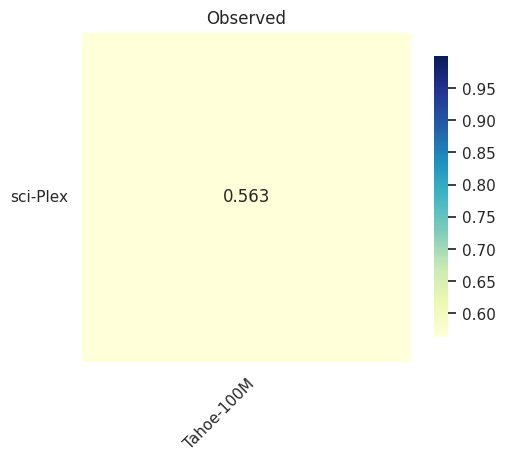

Saved heatmap to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_retrieval_metrics/tahoe__sciplex/dataset_pair_strict_matched_condition_logfc_observed_normalized_rank_heatmap.pdf


In [13]:
plot_pair_metric_heatmap(
    strict_logfc_pair_summary,
    value_col="mean_normalized_best_positive_rank",
    title="Observed",
    cmap="YlGnBu",
    output_path=RETRIEVAL_HEATMAP_OUTPUT_PATHS["observed"],
    dataset_order=heatmap_dataset_order,
    vmin=observed_baseline_vmin,
    vmax=observed_baseline_vmax,
    cbar_label="Observed normalized rank",
)


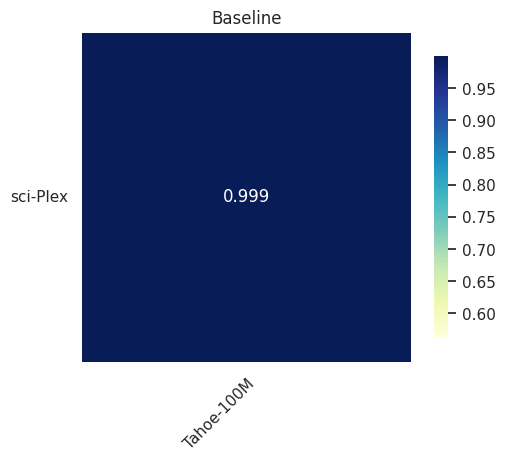

Saved heatmap to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_retrieval_metrics/tahoe__sciplex/dataset_pair_strict_matched_condition_logfc_baseline_normalized_rank_heatmap.pdf


In [14]:
plot_pair_metric_heatmap(
    strict_logfc_pair_summary,
    value_col="mean_baseline_normalized_best_positive_rank",
    title="Baseline",
    cmap="YlGnBu",
    output_path=RETRIEVAL_HEATMAP_OUTPUT_PATHS["baseline"],
    dataset_order=heatmap_dataset_order,
    vmin=observed_baseline_vmin,
    vmax=observed_baseline_vmax,
    cbar_label="Baseline normalized rank",
)


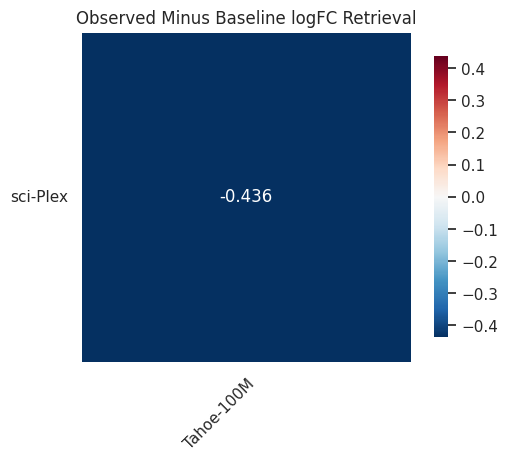

Saved heatmap to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_retrieval_metrics/tahoe__sciplex/dataset_pair_strict_matched_condition_logfc_delta_normalized_rank_heatmap.pdf


In [15]:
plot_pair_metric_heatmap(
    strict_logfc_pair_summary,
    value_col="mean_delta_vs_baseline_normalized_best_positive_rank",
    title="Observed Minus Baseline logFC Retrieval",
    cmap="RdBu_r",
    output_path=RETRIEVAL_HEATMAP_OUTPUT_PATHS["delta"],
    dataset_order=heatmap_dataset_order,
    vmin=None if delta_abs_max is None else -delta_abs_max,
    vmax=None if delta_abs_max is None else delta_abs_max,
    center=0.0,
    cbar_label="Observed - baseline normalized rank",
)


## Strict-logFC retrieval: fair cross-assay null and baseline diagnostics

This focused ablation leaves the full retrieval analysis above unchanged and reevaluates
only strict matched-condition retrieval on `logFC`.

Three similarities are reported on the same pairwise shared-gene vectors:

- `negative_l2`: the original negative Euclidean distance
- `cosine`: cosine similarity after row-wise normalization
- `spearman`: correlation of within-signature gene ranks

The primary null is an exact cross-assay target-decoy relabeling expectation. For each
query, it keeps the actual target-assay candidate pool and observed number of positives,
then computes the expected retrieval metrics under uniformly random positive labels.
The notebook also reports the centroid baseline, individual-signature baseline, and
within-dataset same-compound positive control. All three similarities are scored together
and cached in one output; no backup or addendum merge is required.


In [16]:
RETRIEVAL_ABLATION_SIMILARITIES = ("negative_l2", "cosine", "spearman")
SINGLE_SIGNATURE_BASELINE_CHUNK_SIZE = 512
RETRIEVAL_ABLATION_REPRESENTATION = "logFC"
RETRIEVAL_ABLATION_VARIANT = "strict_matched_condition"


def cosine_similarity_matrix(
    query_matrix: np.ndarray,
    candidate_matrix: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    query_matrix = np.asarray(query_matrix, dtype=np.float64)
    candidate_matrix = np.asarray(candidate_matrix, dtype=np.float64)
    query_norms = np.linalg.norm(query_matrix, axis=1)
    candidate_norms = np.linalg.norm(candidate_matrix, axis=1)
    valid_queries = np.isfinite(query_matrix).all(axis=1) & np.isfinite(query_norms) & (query_norms > 0.0)
    valid_candidates = (
        np.isfinite(candidate_matrix).all(axis=1)
        & np.isfinite(candidate_norms)
        & (candidate_norms > 0.0)
    )
    similarities = np.full((len(query_matrix), len(candidate_matrix)), np.nan, dtype=np.float64)
    if valid_queries.any() and valid_candidates.any():
        normalized_queries = query_matrix[valid_queries] / query_norms[valid_queries, None]
        normalized_candidates = (
            candidate_matrix[valid_candidates] / candidate_norms[valid_candidates, None]
        )
        similarities[np.ix_(valid_queries, valid_candidates)] = np.clip(
            normalized_queries @ normalized_candidates.T,
            -1.0,
            1.0,
        )
    return similarities, valid_queries, valid_candidates


def spearman_similarity_matrix(
    query_matrix: np.ndarray,
    candidate_matrix: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Spearman as cosine on mean-centered row ranks.

    Same validity conventions as `cosine_similarity_matrix`: rows with non-finite values
    or zero spread (a constant signature, whose ranks are all tied) are marked invalid and
    scored NaN. Verified against `scipy.stats.spearmanr` to 1e-17, including tied ranks.
    """
    def prepare(matrix: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        matrix = np.asarray(matrix, dtype=np.float64)
        ranks = np.atleast_2d(rankdata(matrix, method="average", axis=1)).astype(np.float64)
        centered = ranks - ranks.mean(axis=1, keepdims=True)
        norms = np.linalg.norm(centered, axis=1)
        valid = np.isfinite(matrix).all(axis=1) & np.isfinite(norms) & (norms > 0.0)
        prepared = np.zeros_like(centered)
        prepared[valid] = centered[valid] / norms[valid, None]
        return prepared, valid

    prepared_queries, valid_queries = prepare(query_matrix)
    prepared_candidates, valid_candidates = prepare(candidate_matrix)
    similarities = np.full(
        (len(prepared_queries), len(prepared_candidates)),
        np.nan,
        dtype=np.float64,
    )
    if valid_queries.any() and valid_candidates.any():
        similarities[np.ix_(valid_queries, valid_candidates)] = np.clip(
            prepared_queries[valid_queries] @ prepared_candidates[valid_candidates].T,
            -1.0,
            1.0,
        )
    return similarities, valid_queries, valid_candidates


def score_vector_against_matrix(
    query_vector: np.ndarray,
    candidate_matrix: np.ndarray,
    similarity_metric: str,
) -> np.ndarray:
    query_vector = np.asarray(query_vector, dtype=np.float64)
    candidate_matrix = np.asarray(candidate_matrix, dtype=np.float64)
    if candidate_matrix.ndim != 2:
        raise ValueError("candidate_matrix must be two-dimensional")
    if similarity_metric == "negative_l2":
        query_squared_norm = float(np.dot(query_vector, query_vector))
        candidate_squared_norms = np.einsum("ij,ij->i", candidate_matrix, candidate_matrix)
        squared_distances = (
            candidate_squared_norms
            + query_squared_norm
            - 2.0 * (candidate_matrix @ query_vector)
        )
        return -np.sqrt(np.maximum(squared_distances, 0.0))
    if similarity_metric == "cosine":
        query_norm = float(np.linalg.norm(query_vector))
        candidate_norms = np.linalg.norm(candidate_matrix, axis=1)
        if not np.isfinite(query_norm) or query_norm <= 0.0:
            return np.full(len(candidate_matrix), np.nan, dtype=np.float64)
        scores = np.full(len(candidate_matrix), np.nan, dtype=np.float64)
        valid = (
            np.isfinite(candidate_matrix).all(axis=1)
            & np.isfinite(candidate_norms)
            & (candidate_norms > 0.0)
        )
        if valid.any():
            scores[valid] = np.clip(
                (candidate_matrix[valid] @ query_vector)
                / (candidate_norms[valid] * query_norm),
                -1.0,
                1.0,
            )
        return scores
    if similarity_metric == "spearman":
        scores, valid_query, _ = spearman_similarity_matrix(
            query_vector[None, :],
            candidate_matrix,
        )
        if not bool(valid_query[0]):
            return np.full(len(candidate_matrix), np.nan, dtype=np.float64)
        return scores[0]
    raise KeyError(f"Unsupported similarity metric: {similarity_metric}")


def score_vector_pair(
    query_vector: np.ndarray,
    candidate_vector: np.ndarray,
    similarity_metric: str,
) -> float:
    scores = score_vector_against_matrix(
        query_vector,
        np.asarray(candidate_vector, dtype=np.float64)[None, :],
        similarity_metric,
    )
    return float(scores[0])



def ablation_exact_cross_assay_target_decoy_null(
    n_candidates: int,
    n_positives: int,
) -> dict[str, float]:
    """Expected metrics after uniformly relabeling K positives within N target candidates."""
    n_candidates = int(n_candidates)
    n_positives = int(n_positives)
    if n_candidates < 2 or n_positives < 1 or n_positives >= n_candidates:
        return {
            "best_rank": float("nan"),
            "normalized_rank": float("nan"),
            "recall_at_1": float("nan"),
            "auroc": float("nan"),
        }
    expected_best_rank = float((n_candidates + 1.0) / (n_positives + 1.0))
    expected_normalized_rank = 1.0 - (
        (expected_best_rank - 1.0) / (n_candidates - 1.0)
    )
    return {
        "best_rank": expected_best_rank,
        "normalized_rank": float(expected_normalized_rank),
        "recall_at_1": float(n_positives / n_candidates),
        "auroc": 0.5,
    }


def expected_single_signature_metrics(
    target_scores: np.ndarray,
    peer_scores: np.ndarray,
    *,
    chunk_size: int = SINGLE_SIGNATURE_BASELINE_CHUNK_SIZE,
) -> dict[str, float]:
    target_scores = np.asarray(target_scores, dtype=np.float64)
    peer_scores = np.asarray(peer_scores, dtype=np.float64)
    target_scores = target_scores[np.isfinite(target_scores)]
    peer_scores = peer_scores[np.isfinite(peer_scores)]
    if target_scores.size < 1 or peer_scores.size < 1:
        return {
            "n_peers": int(peer_scores.size),
            "best_rank": float("nan"),
            "normalized_rank": float("nan"),
            "recall_at_1": float("nan"),
            "auroc": float("nan"),
        }

    n_targets = int(target_scores.size)
    rank_values: list[np.ndarray] = []
    normalized_rank_values: list[np.ndarray] = []
    recall_values: list[np.ndarray] = []
    auroc_values: list[np.ndarray] = []
    for start in range(0, len(peer_scores), int(chunk_size)):
        peer_chunk = peer_scores[start : start + int(chunk_size)]
        peer_by_target = peer_chunk[:, None]
        target_by_peer = target_scores[None, :]
        n_strictly_better_targets = np.sum(target_by_peer > peer_by_target, axis=1)
        best_ranks = 1.0 + n_strictly_better_targets.astype(np.float64)
        normalized_ranks = 1.0 - (n_strictly_better_targets.astype(np.float64) / n_targets)
        recalls = (best_ranks == 1.0).astype(np.float64)
        wins = np.sum(peer_by_target > target_by_peer, axis=1).astype(np.float64)
        wins += 0.5 * np.sum(
            np.isclose(peer_by_target, target_by_peer, rtol=0.0, atol=1e-12),
            axis=1,
        )
        aurocs = wins / float(n_targets)
        rank_values.append(best_ranks)
        normalized_rank_values.append(normalized_ranks)
        recall_values.append(recalls)
        auroc_values.append(aurocs)

    return {
        "n_peers": int(peer_scores.size),
        "best_rank": float(np.mean(np.concatenate(rank_values))),
        "normalized_rank": float(np.mean(np.concatenate(normalized_rank_values))),
        "recall_at_1": float(np.mean(np.concatenate(recall_values))),
        "auroc": float(np.mean(np.concatenate(auroc_values))),
    }


def source_context_logfc_pool(
    source: LineSource,
    source_gene_positions: np.ndarray,
    finite_gene_mask: np.ndarray,
    *,
    time_key: str,
    dose_key: str,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    context_obs = source.obs.loc[
        (source.obs["time_key"].astype(str) == str(time_key))
        & (source.obs["dose_key"].astype(str) == str(dose_key))
    ].copy()
    if context_obs.empty:
        return (
            np.empty(0, dtype=np.int64),
            np.empty(0, dtype=object),
            np.empty((0, int(np.sum(finite_gene_mask))), dtype=np.float64),
        )
    source_rows = context_obs["source_row_pos"].to_numpy(dtype=np.int64)
    compounds = context_obs["pubchem_cid"].astype(str).to_numpy(dtype=object)
    stratum = source.get_value_stratum("logFC", dose_key, time_key)
    if not np.array_equal(compounds.astype(str), stratum.compounds):
        raise AssertionError("Cached source stratum row order changed")
    projected_matrix = stratum.values[:, source_gene_positions]
    projected_matrix = projected_matrix[:, finite_gene_mask]
    return source_rows, compounds, projected_matrix

In [17]:
import sys

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from scripts.notebook_cache import (
    ProgressReporter,
    cache_summary,
    cached_frame,
    force_recompute,
    frame_identity_fingerprint,
    is_cached,
    stable_json_fingerprint,
)

print("Notebook cache helpers loaded.")

Notebook cache helpers loaded.


In [18]:
RETRIEVAL_ABLATION_QUERY_PATH = (
    OUTPUT_DIR / "retrieval_similarity_baseline_ablation_query.tsv"
)
RETRIEVAL_ABLATION_FINGERPRINT = stable_json_fingerprint(
    {
        "version": "retrieval-ablation-v6-shared-core",
        "datasets": DATASET_ORDER,
        "metrics": RETRIEVAL_ABLATION_SIMILARITIES,
        "min_candidates": MIN_TARGET_CANDIDATES,
        "min_compounds": MIN_UNIQUE_COMPOUNDS_PER_SIDE,
        "contexts": frame_identity_fingerprint(pair_contexts),
        "sources": cross_source_core.line_source_inventory(
            matched_lines,
            resolve_line_path,
        ),
    }
)
ablation_is_cached = is_cached(
    "retrieval_ablation",
    RETRIEVAL_ABLATION_QUERY_PATH,
    fingerprint=RETRIEVAL_ABLATION_FINGERPRINT,
)

retrieval_ablation_records: list[dict[str, object]] = []
retrieval_ablation_skipped_records: list[dict[str, object]] = []

ablation_context_input = pair_contexts.iloc[0:0] if ablation_is_cached else pair_contexts
ablation_progress = ProgressReporter(
    total=len(ablation_context_input),
    label="retrieval_ablation_contexts",
    every=1,
    min_interval_seconds=20.0,
)
for context_index, (_, context_row) in enumerate(ablation_context_input.iterrows(), start=1):
    dataset_a = str(context_row["dataset_a"])
    dataset_b = str(context_row["dataset_b"])
    cell_type = str(context_row["cell_type"])
    time_key = str(context_row["time_key"])
    ablation_progress.update(
        completed=context_index - 1,
        detail=f"{pretty_label(dataset_a)} vs {pretty_label(dataset_b)} / {cell_type} / {time_key}",
        force=True,
    )

    left_pool = pool_frame_for_context(dataset_indices[dataset_a]["frame"], cell_type, time_key)
    right_pool = pool_frame_for_context(dataset_indices[dataset_b]["frame"], cell_type, time_key)
    if (
        len(left_pool) < MIN_TARGET_CANDIDATES
        or len(right_pool) < MIN_TARGET_CANDIDATES
        or left_pool["pubchem_cid"].astype(str).nunique() < MIN_UNIQUE_COMPOUNDS_PER_SIDE
        or right_pool["pubchem_cid"].astype(str).nunique() < MIN_UNIQUE_COMPOUNDS_PER_SIDE
    ):
        continue

    left_source = get_line_source(dataset_a, cell_type)
    right_source = get_line_source(dataset_b, cell_type)
    shared_genes, left_gene_pos, right_gene_pos = shared_gene_positions(left_source, right_source)
    if shared_genes.size < 2:
        continue

    left_adj_layer = get_adjusted_pvalue_layer(left_source)
    right_adj_layer = get_adjusted_pvalue_layer(right_source)
    (
        left_pool,
        left_logfc,
        left_t,
        left_adj_p,
        left_baseline_logfc,
        left_baseline_t,
        left_baseline_adj_p,
        left_baseline_peer_counts,
        _,
    ) = build_pool_matrices(
        left_pool,
        left_source,
        left_gene_pos,
        adj_layer_name=left_adj_layer,
    )
    (
        right_pool,
        right_logfc,
        right_t,
        right_adj_p,
        right_baseline_logfc,
        right_baseline_t,
        right_baseline_adj_p,
        right_baseline_peer_counts,
        _,
    ) = build_pool_matrices(
        right_pool,
        right_source,
        right_gene_pos,
        adj_layer_name=right_adj_layer,
    )
    if (
        len(left_pool) < MIN_TARGET_CANDIDATES
        or len(right_pool) < MIN_TARGET_CANDIDATES
        or left_pool["pubchem_cid"].astype(str).nunique() < MIN_UNIQUE_COMPOUNDS_PER_SIDE
        or right_pool["pubchem_cid"].astype(str).nunique() < MIN_UNIQUE_COMPOUNDS_PER_SIDE
    ):
        continue

    finite_gene_mask = (
        np.isfinite(left_logfc).all(axis=0)
        & np.isfinite(right_logfc).all(axis=0)
        & np.isfinite(left_t).all(axis=0)
        & np.isfinite(right_t).all(axis=0)
        & np.isfinite(left_adj_p).all(axis=0)
        & np.isfinite(right_adj_p).all(axis=0)
    )
    shared_genes = shared_genes[finite_gene_mask]
    left_logfc = left_logfc[:, finite_gene_mask]
    right_logfc = right_logfc[:, finite_gene_mask]
    left_baseline_logfc = left_baseline_logfc[:, finite_gene_mask]
    right_baseline_logfc = right_baseline_logfc[:, finite_gene_mask]
    if shared_genes.size < 2:
        continue

    directional_specs = [
        {
            "direction": "A_to_B",
            "query_dataset": dataset_a,
            "target_dataset": dataset_b,
            "query_pool": left_pool,
            "target_pool": right_pool,
            "query_matrix": left_logfc,
            "target_matrix": right_logfc,
            "centroid_matrix": left_baseline_logfc,
            "query_source": left_source,
            "query_gene_positions": left_gene_pos,
            "query_baseline_peer_counts": left_baseline_peer_counts,
            "strict_map": strict_positive_maps.get((dataset_a, dataset_b, "A_to_B"), {}),
        },
        {
            "direction": "B_to_A",
            "query_dataset": dataset_b,
            "target_dataset": dataset_a,
            "query_pool": right_pool,
            "target_pool": left_pool,
            "query_matrix": right_logfc,
            "target_matrix": left_logfc,
            "centroid_matrix": right_baseline_logfc,
            "query_source": right_source,
            "query_gene_positions": right_gene_pos,
            "query_baseline_peer_counts": right_baseline_peer_counts,
            "strict_map": strict_positive_maps.get((dataset_a, dataset_b, "B_to_A"), {}),
        },
    ]

    for direction_spec in directional_specs:
        query_pool = direction_spec["query_pool"].reset_index(drop=True)
        target_pool = direction_spec["target_pool"].reset_index(drop=True)
        query_matrix = np.asarray(direction_spec["query_matrix"], dtype=np.float64)
        target_matrix = np.asarray(direction_spec["target_matrix"], dtype=np.float64)
        centroid_matrix = np.asarray(direction_spec["centroid_matrix"], dtype=np.float64)
        query_baseline_peer_counts = np.asarray(
            direction_spec["query_baseline_peer_counts"],
            dtype=np.int64,
        )

        # Build and release one metric matrix at a time to bound peak memory.
        all_valid_queries = np.ones(len(query_pool), dtype=bool)
        all_valid_targets = np.ones(len(target_pool), dtype=bool)
        query_compounds = query_pool["pubchem_cid"].astype(str).to_numpy(dtype=object)
        query_obs_ids = query_pool["obs_id"].astype(str).to_numpy(dtype=object)
        query_dose_keys = query_pool["dose_key"].astype(str).to_numpy(dtype=object)
        query_doses_uM = query_pool["pert_dose_uM"].to_numpy(dtype=np.float64)
        target_obs_ids = target_pool["obs_id"].astype(str).to_numpy(dtype=object)
        peer_pool_cache: dict[str, tuple[np.ndarray, np.ndarray, np.ndarray]] = {}
        query_progress = ProgressReporter(
            total=len(query_pool) * len(RETRIEVAL_ABLATION_SIMILARITIES),
            label="retrieval_ablation_queries",
            every=100,
            min_interval_seconds=20.0,
        )
        query_progress_count = 0

        for similarity_metric in RETRIEVAL_ABLATION_SIMILARITIES:
            if similarity_metric == "negative_l2":
                similarity_matrix = negative_l2_similarity_matrix(query_matrix, target_matrix)
                valid_queries = all_valid_queries
                valid_targets = all_valid_targets
            elif similarity_metric == "cosine":
                similarity_matrix, valid_queries, valid_targets = cosine_similarity_matrix(
                    query_matrix,
                    target_matrix,
                )
            elif similarity_metric == "spearman":
                similarity_matrix, valid_queries, valid_targets = spearman_similarity_matrix(
                    query_matrix,
                    target_matrix,
                )
            else:
                raise ValueError(f"Unsupported retrieval similarity: {similarity_metric}")

            target_keep_indices = np.flatnonzero(valid_targets)
            filtered_target_obs_ids = target_obs_ids[target_keep_indices]
            n_zero_norm_target_candidates = int(len(target_pool) - len(target_keep_indices))
            if len(target_keep_indices) < MIN_TARGET_CANDIDATES:
                continue

            for query_idx in range(len(query_pool)):
                query_progress_count += 1
                query_progress.update(
                    completed=query_progress_count,
                    detail=f"{direction_spec['direction']} / {similarity_metric}",
                )
                query_compound = str(query_compounds[query_idx])
                query_obs_id = str(query_obs_ids[query_idx])
                query_dose_key = str(query_dose_keys[query_idx])
                query_dose_uM = float(query_doses_uM[query_idx])
                if not bool(valid_queries[query_idx]):
                    retrieval_ablation_skipped_records.append(
                        {
                            "dataset_a": dataset_a,
                            "dataset_b": dataset_b,
                            "direction": direction_spec["direction"],
                            "query_dataset": direction_spec["query_dataset"],
                            "target_dataset": direction_spec["target_dataset"],
                            "cell_type": cell_type,
                            "time_key": time_key,
                            "query_obs_id": query_obs_id,
                            "query_pubchem_cid": query_compound,
                            "query_dose_key": query_dose_key,
                            "similarity_metric": similarity_metric,
                            "reason": "zero_or_nonfinite_query_norm",
                        }
                    )
                    continue

                query_scores = similarity_matrix[query_idx, target_keep_indices]
                positive_mask = strict_positive_mask(
                    query_obs_id,
                    filtered_target_obs_ids,
                    direction_spec["strict_map"],
                )
                observed_metrics = summarize_retrieval_scores(query_scores, positive_mask)
                if observed_metrics["n_positives"] == 0 or observed_metrics["n_negatives"] == 0:
                    retrieval_ablation_skipped_records.append(
                        {
                            "dataset_a": dataset_a,
                            "dataset_b": dataset_b,
                            "direction": direction_spec["direction"],
                            "query_dataset": direction_spec["query_dataset"],
                            "target_dataset": direction_spec["target_dataset"],
                            "cell_type": cell_type,
                            "time_key": time_key,
                            "query_obs_id": query_obs_id,
                            "query_pubchem_cid": query_compound,
                            "query_dose_key": query_dose_key,
                            "similarity_metric": similarity_metric,
                            "reason": "no_positive_or_negative_candidates_after_filtering",
                        }
                    )
                    continue

                target_decoy_metrics = ablation_exact_cross_assay_target_decoy_null(
                    n_candidates=len(query_scores),
                    n_positives=int(observed_metrics["n_positives"]),
                )

                within_candidate_mask = np.arange(len(query_pool)) != query_idx
                within_candidate_matrix = query_matrix[within_candidate_mask]
                within_candidate_compounds = query_compounds[within_candidate_mask]
                within_candidate_doses_uM = query_doses_uM[within_candidate_mask]
                within_finite_mask = np.isfinite(within_candidate_matrix).all(axis=1)
                if similarity_metric == "cosine" and within_finite_mask.any():
                    within_finite_mask &= (
                        np.linalg.norm(within_candidate_matrix, axis=1) > 0.0
                    )
                within_candidate_matrix = within_candidate_matrix[within_finite_mask]
                within_candidate_compounds = within_candidate_compounds[within_finite_mask]
                within_candidate_doses_uM = within_candidate_doses_uM[within_finite_mask]
                within_dataset_metrics = {
                    "n_positives": 0,
                    "n_negatives": 0,
                    "best_rank": float("nan"),
                    "normalized_rank": float("nan"),
                    "recall_at_1": float("nan"),
                    "auroc": float("nan"),
                }
                if len(within_candidate_matrix) >= 2:
                    within_scores = score_vector_against_matrix(
                        query_matrix[query_idx],
                        within_candidate_matrix,
                        similarity_metric,
                    )
                    within_positive_mask = (
                        within_candidate_compounds.astype(str) == query_compound
                    ) & (
                        raw_dose_fold_differences(
                            query_dose_uM,
                            within_candidate_doses_uM,
                        )
                        <= MAX_DOSE_FOLD_DIFFERENCE + 1e-12
                    )
                    within_dataset_metrics = summarize_retrieval_scores(
                        within_scores,
                        within_positive_mask,
                    )

                centroid_similarity = float("nan")
                centroid_metrics = {
                    "best_rank": float("nan"),
                    "normalized_rank": float("nan"),
                    "recall_at_1": float("nan"),
                    "auroc": float("nan"),
                }
                centroid_vector = centroid_matrix[query_idx]
                if (
                    int(query_baseline_peer_counts[query_idx]) > 0
                    and np.isfinite(centroid_vector).all()
                ):
                    centroid_similarity = score_vector_pair(
                        query_matrix[query_idx],
                        centroid_vector,
                        similarity_metric,
                    )
                    if np.isfinite(centroid_similarity):
                        augmented_scores = np.concatenate(
                            [query_scores, np.asarray([centroid_similarity], dtype=np.float64)]
                        )
                        centroid_positive_mask = np.zeros(len(augmented_scores), dtype=bool)
                        centroid_positive_mask[-1] = True
                        centroid_metrics = summarize_retrieval_scores(
                            augmented_scores,
                            centroid_positive_mask,
                        )

                if query_dose_key not in peer_pool_cache:
                    peer_pool_cache[query_dose_key] = source_context_logfc_pool(
                        direction_spec["query_source"],
                        direction_spec["query_gene_positions"],
                        finite_gene_mask,
                        time_key=time_key,
                        dose_key=query_dose_key,
                    )
                peer_rows, peer_compounds, peer_matrix = peer_pool_cache[query_dose_key]
                eligible_peer_mask = peer_compounds.astype(str) != query_compound
                n_expected_peers = int(np.sum(eligible_peer_mask))
                if n_expected_peers != int(query_baseline_peer_counts[query_idx]):
                    raise AssertionError(
                        "Single-signature peer membership does not match the original centroid baseline "
                        f"for {direction_spec['query_dataset']} / {cell_type} / {query_obs_id}: "
                        f"{n_expected_peers} vs {int(query_baseline_peer_counts[query_idx])}."
                    )
                eligible_peer_matrix = peer_matrix[eligible_peer_mask]
                finite_peer_mask = np.isfinite(eligible_peer_matrix).all(axis=1)
                if similarity_metric == "cosine" and finite_peer_mask.any():
                    finite_peer_mask &= np.linalg.norm(eligible_peer_matrix, axis=1) > 0.0
                retained_peer_matrix = eligible_peer_matrix[finite_peer_mask]
                n_excluded_peer_signatures = int(len(eligible_peer_matrix) - len(retained_peer_matrix))
                peer_scores = score_vector_against_matrix(
                    query_matrix[query_idx],
                    retained_peer_matrix,
                    similarity_metric,
                )
                single_signature_metrics = expected_single_signature_metrics(
                    query_scores,
                    peer_scores,
                )

                retrieval_ablation_records.append(
                    {
                        "dataset_a": dataset_a,
                        "dataset_b": dataset_b,
                        "direction": direction_spec["direction"],
                        "query_dataset": direction_spec["query_dataset"],
                        "target_dataset": direction_spec["target_dataset"],
                        "cell_type": cell_type,
                        "time_key": time_key,
                        "representation": RETRIEVAL_ABLATION_REPRESENTATION,
                        "retrieval_variant": RETRIEVAL_ABLATION_VARIANT,
                        "similarity_metric": similarity_metric,
                        "query_obs_id": query_obs_id,
                        "query_pubchem_cid": query_compound,
                        "query_dose_key": query_dose_key,
                        "query_dose_uM": query_dose_uM,
                        "target_pool_size_before_similarity_filter": int(len(target_pool)),
                        "target_pool_size": int(len(query_scores)),
                        "n_zero_norm_target_candidates": n_zero_norm_target_candidates,
                        "n_shared_genes": int(shared_genes.size),
                        "n_positive_candidates": int(observed_metrics["n_positives"]),
                        "centroid_baseline_peer_count": int(query_baseline_peer_counts[query_idx]),
                        "single_signature_baseline_peer_count": int(single_signature_metrics["n_peers"]),
                        "n_excluded_single_signature_peers": n_excluded_peer_signatures,
                        "centroid_baseline_candidate_similarity": centroid_similarity,
                        "observed_best_positive_rank": observed_metrics["best_rank"],
                        "observed_normalized_best_positive_rank": observed_metrics["normalized_rank"],
                        "observed_recall_at_1": observed_metrics["recall_at_1"],
                        "observed_auroc": observed_metrics["auroc"],
                        "target_decoy_null_best_positive_rank": target_decoy_metrics["best_rank"],
                        "target_decoy_null_normalized_best_positive_rank": target_decoy_metrics["normalized_rank"],
                        "target_decoy_null_recall_at_1": target_decoy_metrics["recall_at_1"],
                        "target_decoy_null_auroc": target_decoy_metrics["auroc"],
                        # Backwards-compatible aliases now use the exact multi-positive expectation.
                        "random_normalized_best_positive_rank": target_decoy_metrics["normalized_rank"],
                        "random_recall_at_1": target_decoy_metrics["recall_at_1"],
                        "random_auroc": target_decoy_metrics["auroc"],
                        "centroid_baseline_best_positive_rank": centroid_metrics["best_rank"],
                        "centroid_baseline_normalized_best_positive_rank": centroid_metrics["normalized_rank"],
                        "centroid_baseline_recall_at_1": centroid_metrics["recall_at_1"],
                        "centroid_baseline_auroc": centroid_metrics["auroc"],
                        "single_signature_baseline_best_positive_rank": single_signature_metrics["best_rank"],
                        "single_signature_baseline_normalized_best_positive_rank": single_signature_metrics["normalized_rank"],
                        "single_signature_baseline_recall_at_1": single_signature_metrics["recall_at_1"],
                        "single_signature_baseline_auroc": single_signature_metrics["auroc"],
                        "within_dataset_positive_control_best_positive_rank": within_dataset_metrics["best_rank"],
                        "within_dataset_positive_control_normalized_best_positive_rank": within_dataset_metrics["normalized_rank"],
                        "within_dataset_positive_control_recall_at_1": within_dataset_metrics["recall_at_1"],
                        "within_dataset_positive_control_auroc": within_dataset_metrics["auroc"],
                        "delta_vs_target_decoy_null_normalized_best_positive_rank": difference_if_both_defined(
                            observed_metrics["normalized_rank"],
                            target_decoy_metrics["normalized_rank"],
                        ),
                        "delta_vs_target_decoy_null_recall_at_1": difference_if_both_defined(
                            observed_metrics["recall_at_1"],
                            target_decoy_metrics["recall_at_1"],
                        ),
                        "delta_vs_target_decoy_null_auroc": difference_if_both_defined(
                            observed_metrics["auroc"],
                            target_decoy_metrics["auroc"],
                        ),
                        "delta_vs_random_normalized_best_positive_rank": difference_if_both_defined(
                            observed_metrics["normalized_rank"],
                            target_decoy_metrics["normalized_rank"],
                        ),
                        "delta_vs_centroid_baseline_normalized_best_positive_rank": difference_if_both_defined(
                            observed_metrics["normalized_rank"],
                            centroid_metrics["normalized_rank"],
                        ),
                        "delta_vs_centroid_baseline_recall_at_1": difference_if_both_defined(
                            observed_metrics["recall_at_1"],
                            centroid_metrics["recall_at_1"],
                        ),
                        "delta_vs_centroid_baseline_auroc": difference_if_both_defined(
                            observed_metrics["auroc"],
                            centroid_metrics["auroc"],
                        ),
                        "delta_vs_single_signature_baseline_normalized_best_positive_rank": difference_if_both_defined(
                            observed_metrics["normalized_rank"],
                            single_signature_metrics["normalized_rank"],
                        ),
                        "delta_vs_single_signature_baseline_recall_at_1": difference_if_both_defined(
                            observed_metrics["recall_at_1"],
                            single_signature_metrics["recall_at_1"],
                        ),
                        "delta_vs_single_signature_baseline_auroc": difference_if_both_defined(
                            observed_metrics["auroc"],
                            single_signature_metrics["auroc"],
                        ),
                        "delta_vs_within_dataset_positive_control_normalized_best_positive_rank": difference_if_both_defined(
                            observed_metrics["normalized_rank"],
                            within_dataset_metrics["normalized_rank"],
                        ),
                        "delta_vs_within_dataset_positive_control_recall_at_1": difference_if_both_defined(
                            observed_metrics["recall_at_1"],
                            within_dataset_metrics["recall_at_1"],
                        ),
                        "delta_vs_within_dataset_positive_control_auroc": difference_if_both_defined(
                            observed_metrics["auroc"],
                            within_dataset_metrics["auroc"],
                        ),
                    }
                )

def build_retrieval_ablation() -> pd.DataFrame:
    frame = pd.DataFrame(retrieval_ablation_records)
    if frame.empty:
        raise ValueError("No strict-logFC retrieval similarity-ablation queries were scored.")
    return frame


retrieval_ablation_query_path = RETRIEVAL_ABLATION_QUERY_PATH
retrieval_similarity_baseline_ablation_query = cached_frame(
    "retrieval_ablation",
    retrieval_ablation_query_path,
    build_retrieval_ablation,
    fingerprint=RETRIEVAL_ABLATION_FINGERPRINT,
    required_columns=[
        "similarity_metric",
        "observed_normalized_best_positive_rank",
        "single_signature_baseline_normalized_best_positive_rank",
        "centroid_baseline_normalized_best_positive_rank",
    ],
)
present_ablation_metrics = set(
    retrieval_similarity_baseline_ablation_query["similarity_metric"].unique()
)
missing_ablation_metrics = (
    set(RETRIEVAL_ABLATION_SIMILARITIES) - present_ablation_metrics
)
if missing_ablation_metrics:
    raise ValueError(
        "Retrieval-ablation output is missing metrics: "
        f"{sorted(missing_ablation_metrics)}"
    )
print(
    "Metrics in retrieval ablation:",
    retrieval_similarity_baseline_ablation_query[
        "similarity_metric"
    ].value_counts().to_dict(),
)


baseline_long_specs = {
    "observed_cross_dataset": {
        "role": "observed",
        "prefix": "observed",
    },
    "cross_assay_target_decoy_null": {
        "role": "primary_null",
        "prefix": "target_decoy_null",
    },
    "expected_single_signature": {
        "role": "home_field_diagnostic",
        "prefix": "single_signature_baseline",
    },
    "centroid": {
        "role": "smoothing_home_field_diagnostic",
        "prefix": "centroid_baseline",
    },
    "within_dataset_same_compound": {
        "role": "positive_control",
        "prefix": "within_dataset_positive_control",
    },
}
baseline_long_id_columns = [
    "dataset_a",
    "dataset_b",
    "direction",
    "query_dataset",
    "target_dataset",
    "cell_type",
    "time_key",
    "representation",
    "retrieval_variant",
    "similarity_metric",
    "query_obs_id",
    "query_pubchem_cid",
    "query_dose_key",
    "query_dose_uM",
    "target_pool_size",
    "n_positive_candidates",
]
baseline_long_frames: list[pd.DataFrame] = []
for baseline_type, baseline_spec in baseline_long_specs.items():
    prefix = str(baseline_spec["prefix"])
    frame = retrieval_similarity_baseline_ablation_query[baseline_long_id_columns].copy()
    frame["baseline_type"] = baseline_type
    frame["baseline_role"] = str(baseline_spec["role"])
    frame["normalized_best_positive_rank"] = (
        retrieval_similarity_baseline_ablation_query[
            f"{prefix}_normalized_best_positive_rank"
        ]
    )
    frame["recall_at_1"] = retrieval_similarity_baseline_ablation_query[
        f"{prefix}_recall_at_1"
    ]
    frame["auroc"] = retrieval_similarity_baseline_ablation_query[f"{prefix}_auroc"]
    baseline_long_frames.append(frame)
retrieval_similarity_baseline_ablation_query_long = pd.concat(
    baseline_long_frames,
    ignore_index=True,
)
retrieval_ablation_query_long_path = (
    OUTPUT_DIR / "retrieval_similarity_baseline_ablation_query_long.tsv"
)
retrieval_similarity_baseline_ablation_query_long.to_csv(
    retrieval_ablation_query_long_path,
    sep="\t",
    index=False,
)
print(f"Saved long-form retrieval baseline table to {retrieval_ablation_query_long_path}")

retrieval_ablation_skipped = pd.DataFrame(retrieval_ablation_skipped_records)
if not retrieval_ablation_skipped.empty:
    retrieval_ablation_skipped_path = OUTPUT_DIR / "retrieval_similarity_baseline_ablation_skipped.tsv"
    retrieval_ablation_skipped.to_csv(retrieval_ablation_skipped_path, sep="\t", index=False)
    print(f"Saved skipped retrieval-ablation queries to {retrieval_ablation_skipped_path}")

retrieval_ablation_diagnostics = (
    retrieval_similarity_baseline_ablation_query.groupby("similarity_metric", as_index=False)
    .agg(
        n_scored_queries=("query_obs_id", "size"),
        n_queries_with_zero_norm_target_candidates=(
            "n_zero_norm_target_candidates",
            lambda values: int((values > 0).sum()),
        ),
        n_zero_norm_target_candidates=("n_zero_norm_target_candidates", "sum"),
        n_excluded_single_signature_peers=("n_excluded_single_signature_peers", "sum"),
    )
)
if not retrieval_ablation_skipped.empty:
    zero_query_counts = (
        retrieval_ablation_skipped.loc[
            retrieval_ablation_skipped["reason"] == "zero_or_nonfinite_query_norm"
        ]
        .groupby("similarity_metric")
        .size()
        .rename("n_zero_or_nonfinite_query_norms")
        .reset_index()
    )
    retrieval_ablation_diagnostics = retrieval_ablation_diagnostics.merge(
        zero_query_counts,
        on="similarity_metric",
        how="left",
    )
retrieval_ablation_diagnostics["n_zero_or_nonfinite_query_norms"] = (
    retrieval_ablation_diagnostics.get(
        "n_zero_or_nonfinite_query_norms",
        pd.Series(0, index=retrieval_ablation_diagnostics.index),
    )
    .fillna(0)
    .astype(int)
)
retrieval_ablation_diagnostics_path = OUTPUT_DIR / "retrieval_similarity_baseline_ablation_diagnostics.tsv"
retrieval_ablation_diagnostics.to_csv(
    retrieval_ablation_diagnostics_path,
    sep="\t",
    index=False,
)
display(retrieval_ablation_diagnostics)

parity_keys = [
    "dataset_a",
    "dataset_b",
    "direction",
    "cell_type",
    "time_key",
    "query_obs_id",
    "query_pubchem_cid",
    "query_dose_key",
]
original_strict_logfc = query_retrieval_metrics.loc[
    (query_retrieval_metrics["retrieval_variant"] == RETRIEVAL_ABLATION_VARIANT)
    & (query_retrieval_metrics["representation"] == RETRIEVAL_ABLATION_REPRESENTATION)
].copy()
original_parity = (
    original_strict_logfc.groupby(parity_keys, as_index=False)
    .agg(
        original_observed=("normalized_best_positive_rank", "mean"),
        original_centroid=("baseline_normalized_best_positive_rank", "mean"),
    )
)
ablation_parity = (
    retrieval_similarity_baseline_ablation_query.loc[
        retrieval_similarity_baseline_ablation_query["similarity_metric"] == "negative_l2"
    ]
    .groupby(parity_keys, as_index=False)
    .agg(
        ablation_observed=("observed_normalized_best_positive_rank", "mean"),
        ablation_centroid=("centroid_baseline_normalized_best_positive_rank", "mean"),
    )
)
euclidean_parity = original_parity.merge(
    ablation_parity,
    on=parity_keys,
    how="inner",
    validate="one_to_one",
)
for original_column, ablation_column in [
    ("original_observed", "ablation_observed"),
    ("original_centroid", "ablation_centroid"),
]:
    if not np.allclose(
        euclidean_parity[original_column].to_numpy(dtype=float),
        euclidean_parity[ablation_column].to_numpy(dtype=float),
        equal_nan=True,
        rtol=1e-12,
        atol=1e-12,
    ):
        raise AssertionError(
            f"Focused Euclidean ablation does not reproduce the original {original_column} values."
        )
print("Euclidean parity check passed for observed and centroid normalized-rank metrics.")

[retrieval_ablation] computed and saved 669 rows to retrieval_similarity_baseline_ablation_query.tsv
Metrics in retrieval ablation: {'negative_l2': 223, 'cosine': 223, 'spearman': 223}
Saved long-form retrieval baseline table to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_retrieval_metrics/tahoe__sciplex/retrieval_similarity_baseline_ablation_query_long.tsv
Saved skipped retrieval-ablation queries to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_retrieval_metrics/tahoe__sciplex/retrieval_similarity_baseline_ablation_skipped.tsv


,similarity_metric,n_scored_queries,n_queries_with_zero_norm_target_candidates,n_zero_norm_target_candidates,n_excluded_single_signature_peers,n_zero_or_nonfinite_query_norms
0,cosine,223,0,0,0,0
1,negative_l2,223,0,0,0,0
2,spearman,223,0,0,0,0


Euclidean parity check passed for observed and centroid normalized-rank metrics.


In [19]:
RETRIEVAL_ABLATION_METRIC_COLUMNS = [
    "observed_normalized_best_positive_rank",
    "observed_recall_at_1",
    "observed_auroc",
    "target_decoy_null_normalized_best_positive_rank",
    "target_decoy_null_recall_at_1",
    "target_decoy_null_auroc",
    "centroid_baseline_normalized_best_positive_rank",
    "centroid_baseline_recall_at_1",
    "centroid_baseline_auroc",
    "single_signature_baseline_normalized_best_positive_rank",
    "single_signature_baseline_recall_at_1",
    "single_signature_baseline_auroc",
    "within_dataset_positive_control_normalized_best_positive_rank",
    "within_dataset_positive_control_recall_at_1",
    "within_dataset_positive_control_auroc",
    "delta_vs_target_decoy_null_normalized_best_positive_rank",
    "delta_vs_target_decoy_null_recall_at_1",
    "delta_vs_target_decoy_null_auroc",
    "delta_vs_centroid_baseline_normalized_best_positive_rank",
    "delta_vs_centroid_baseline_recall_at_1",
    "delta_vs_centroid_baseline_auroc",
    "delta_vs_single_signature_baseline_normalized_best_positive_rank",
    "delta_vs_single_signature_baseline_recall_at_1",
    "delta_vs_single_signature_baseline_auroc",
    "delta_vs_within_dataset_positive_control_normalized_best_positive_rank",
    "delta_vs_within_dataset_positive_control_recall_at_1",
    "delta_vs_within_dataset_positive_control_auroc",
]

stratum_group_columns = [
    "dataset_a",
    "dataset_b",
    "direction",
    "query_dataset",
    "target_dataset",
    "cell_type",
    "time_key",
    "representation",
    "retrieval_variant",
    "similarity_metric",
]
stratum_agg: dict[str, tuple[str, object]] = {
    "n_queries": ("query_obs_id", "size"),
    "n_unique_query_compounds": ("query_pubchem_cid", "nunique"),
    "n_queries_with_centroid_baseline": (
        "centroid_baseline_normalized_best_positive_rank",
        lambda values: int(values.notna().sum()),
    ),
    "n_queries_with_single_signature_baseline": (
        "single_signature_baseline_normalized_best_positive_rank",
        lambda values: int(values.notna().sum()),
    ),
    "mean_target_pool_size": ("target_pool_size", "mean"),
    "mean_shared_genes": ("n_shared_genes", "mean"),
    "mean_centroid_baseline_peer_count": ("centroid_baseline_peer_count", "mean"),
    "mean_single_signature_baseline_peer_count": (
        "single_signature_baseline_peer_count",
        "mean",
    ),
}
for column_name in RETRIEVAL_ABLATION_METRIC_COLUMNS:
    stratum_agg[f"mean_{column_name}"] = (column_name, "mean")

retrieval_ablation_line_time_summary = (
    retrieval_similarity_baseline_ablation_query.groupby(
        stratum_group_columns,
        as_index=False,
    )
    .agg(**stratum_agg)
    .sort_values(stratum_group_columns)
    .reset_index(drop=True)
)

summary_mean_columns = [
    column_name
    for column_name in retrieval_ablation_line_time_summary.columns
    if column_name.startswith("mean_")
]


def aggregate_retrieval_ablation_summary(
    frame: pd.DataFrame,
    group_columns: list[str],
    *,
    include_direction_count: bool = False,
) -> pd.DataFrame:
    agg: dict[str, tuple[str, object]] = {
        "n_line_time_strata": ("cell_type", "size"),
        "n_queries": ("n_queries", "sum"),
        "n_queries_with_centroid_baseline": ("n_queries_with_centroid_baseline", "sum"),
        "n_queries_with_single_signature_baseline": (
            "n_queries_with_single_signature_baseline",
            "sum",
        ),
    }
    if include_direction_count:
        agg["n_directions"] = ("direction", "nunique")
    for column_name in summary_mean_columns:
        agg[column_name] = (column_name, "mean")
    return (
        frame.groupby(group_columns, as_index=False)
        .agg(**agg)
        .sort_values(group_columns)
        .reset_index(drop=True)
    )


retrieval_ablation_pair_direction_summary = aggregate_retrieval_ablation_summary(
    retrieval_ablation_line_time_summary,
    [
        "dataset_a",
        "dataset_b",
        "direction",
        "query_dataset",
        "target_dataset",
        "representation",
        "retrieval_variant",
        "similarity_metric",
    ],
)
pair_summary_agg: dict[str, tuple[str, object]] = {
    "n_directions": ("direction", "size"),
    "mean_line_time_strata": ("n_line_time_strata", "mean"),
    "n_queries": ("n_queries", "sum"),
    "n_queries_with_centroid_baseline": ("n_queries_with_centroid_baseline", "sum"),
    "n_queries_with_single_signature_baseline": (
        "n_queries_with_single_signature_baseline",
        "sum",
    ),
}
for column_name in summary_mean_columns:
    pair_summary_agg[column_name] = (column_name, "mean")
retrieval_ablation_pair_summary = (
    retrieval_ablation_pair_direction_summary.groupby(
        [
            "dataset_a",
            "dataset_b",
            "representation",
            "retrieval_variant",
            "similarity_metric",
        ],
        as_index=False,
    )
    .agg(**pair_summary_agg)
    .sort_values(["dataset_a", "dataset_b", "similarity_metric"])
    .reset_index(drop=True)
)
retrieval_ablation_line_summary = aggregate_retrieval_ablation_summary(
    retrieval_ablation_line_time_summary,
    [
        "dataset_a",
        "dataset_b",
        "cell_type",
        "representation",
        "retrieval_variant",
        "similarity_metric",
    ],
    include_direction_count=True,
)

retrieval_ablation_output_frames = {
    "retrieval_similarity_baseline_ablation_line_time_summary.tsv": retrieval_ablation_line_time_summary,
    "retrieval_similarity_baseline_ablation_dataset_pair_direction_summary.tsv": retrieval_ablation_pair_direction_summary,
    "retrieval_similarity_baseline_ablation_dataset_pair_summary.tsv": retrieval_ablation_pair_summary,
    "retrieval_similarity_baseline_ablation_dataset_pair_line_summary.tsv": retrieval_ablation_line_summary,
}
for filename, frame in retrieval_ablation_output_frames.items():
    output_path = OUTPUT_DIR / filename
    frame.to_csv(output_path, sep="\t", index=False)
    print(f"Saved retrieval-ablation summary to {output_path}")

retrieval_ablation_comparison_columns = [
    "dataset_a",
    "dataset_b",
    "similarity_metric",
    "n_queries",
    "mean_observed_normalized_best_positive_rank",
    "mean_target_decoy_null_normalized_best_positive_rank",
    "mean_centroid_baseline_normalized_best_positive_rank",
    "mean_single_signature_baseline_normalized_best_positive_rank",
    "mean_delta_vs_target_decoy_null_normalized_best_positive_rank",
    "mean_delta_vs_centroid_baseline_normalized_best_positive_rank",
    "mean_delta_vs_single_signature_baseline_normalized_best_positive_rank",
    "mean_observed_recall_at_1",
    "mean_centroid_baseline_recall_at_1",
    "mean_single_signature_baseline_recall_at_1",
    "mean_within_dataset_positive_control_normalized_best_positive_rank",
    "mean_within_dataset_positive_control_recall_at_1",
    "mean_observed_auroc",
    "mean_centroid_baseline_auroc",
    "mean_single_signature_baseline_auroc",
    "mean_within_dataset_positive_control_auroc",
]
retrieval_ablation_comparison = retrieval_ablation_pair_summary[
    retrieval_ablation_comparison_columns
].copy()
retrieval_ablation_comparison_path = OUTPUT_DIR / "retrieval_similarity_baseline_ablation_comparison.tsv"
retrieval_ablation_comparison.to_csv(
    retrieval_ablation_comparison_path,
    sep="\t",
    index=False,
)
print(f"Saved negative-L2/cosine/Spearman comparison table to {retrieval_ablation_comparison_path}")

retrieval_ablation_ci_columns = list(RETRIEVAL_ABLATION_METRIC_COLUMNS)
retrieval_ablation_ci_metrics = {
    column_name: column_name
    for column_name in retrieval_ablation_ci_columns
}
def build_ablation_ci() -> pd.DataFrame:
    retrieval_similarity_baseline_ablation_cluster_bca_ci = pd.concat(
        [
            cluster_bca_nested_mean_ci_table(
                retrieval_similarity_baseline_ablation_query,
                group_cols=[
                    "dataset_a",
                    "dataset_b",
                    "representation",
                    "retrieval_variant",
                    "similarity_metric",
                ],
                metric_cols=retrieval_ablation_ci_metrics,
                cluster_col="query_pubchem_cid",
                inner_cols=["direction", "cell_type", "time_key"],
                outer_cols=["direction"],
                n_boot=BOOTSTRAP_ITERATIONS,
                seed=BOOTSTRAP_RANDOM_SEED,
                summary_level="retrieval_ablation_dataset_pair",
            ),
            cluster_bca_nested_mean_ci_table(
                retrieval_similarity_baseline_ablation_query,
                group_cols=[
                    "dataset_a",
                    "dataset_b",
                    "direction",
                    "query_dataset",
                    "target_dataset",
                    "representation",
                    "retrieval_variant",
                    "similarity_metric",
                ],
                metric_cols=retrieval_ablation_ci_metrics,
                cluster_col="query_pubchem_cid",
                inner_cols=["cell_type", "time_key"],
                n_boot=BOOTSTRAP_ITERATIONS,
                seed=BOOTSTRAP_RANDOM_SEED,
                summary_level="retrieval_ablation_dataset_pair_direction",
            ),
            cluster_bca_nested_mean_ci_table(
                retrieval_similarity_baseline_ablation_query,
                group_cols=[
                    "dataset_a",
                    "dataset_b",
                    "cell_type",
                    "representation",
                    "retrieval_variant",
                    "similarity_metric",
                ],
                metric_cols=retrieval_ablation_ci_metrics,
                cluster_col="query_pubchem_cid",
                inner_cols=["time_key"],
                n_boot=BOOTSTRAP_ITERATIONS,
                seed=BOOTSTRAP_RANDOM_SEED,
                summary_level="retrieval_ablation_dataset_pair_line",
            ),
        ],
        ignore_index=True,
    )
    return retrieval_similarity_baseline_ablation_cluster_bca_ci


retrieval_similarity_baseline_ablation_cluster_bca_ci_path = OUTPUT_DIR / "retrieval_similarity_baseline_ablation_cluster_bca_ci.tsv"
retrieval_similarity_baseline_ablation_cluster_bca_ci = cached_frame(
    "ablation_ci",
    retrieval_similarity_baseline_ablation_cluster_bca_ci_path,
    build_ablation_ci,
    fingerprint=(
        f"retrieval-ablation-ci-v4|source={RETRIEVAL_ABLATION_FINGERPRINT}"
        f"|boot={BOOTSTRAP_ITERATIONS}|seed={BOOTSTRAP_RANDOM_SEED}"
    ),
)
retrieval_ablation_ci_path = OUTPUT_DIR / "retrieval_similarity_baseline_ablation_cluster_bca_ci.tsv"
print(f"Saved retrieval-ablation cluster-BCa CIs to {retrieval_ablation_ci_path}")

comparison_display = retrieval_ablation_comparison.copy()
comparison_display["dataset_a"] = comparison_display["dataset_a"].map(pretty_label)
comparison_display["dataset_b"] = comparison_display["dataset_b"].map(pretty_label)
display(comparison_display)

Saved retrieval-ablation summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_retrieval_metrics/tahoe__sciplex/retrieval_similarity_baseline_ablation_line_time_summary.tsv
Saved retrieval-ablation summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_retrieval_metrics/tahoe__sciplex/retrieval_similarity_baseline_ablation_dataset_pair_direction_summary.tsv
Saved retrieval-ablation summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_retrieval_metrics/tahoe__sciplex/retrieval_similarity_baseline_ablation_dataset_pair_summary.tsv
Saved retrieval-ablation summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_retrieval_metrics/tahoe__sciplex/retrieval_similarity_baseline_ablation_dataset_pair_line_summary.tsv
Saved negative-L2/cosine/Spearman comparison table to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_retrieval_metrics

,dataset_a,dataset_b,similarity_metric,n_queries,mean_observed_normalized_best_positive_rank,mean_target_decoy_null_normalized_best_positive_rank,mean_centroid_baseline_normalized_best_positive_rank,mean_single_signature_baseline_normalized_best_positive_rank,mean_delta_vs_target_decoy_null_normalized_best_positive_rank,mean_delta_vs_centroid_baseline_normalized_best_positive_rank,mean_delta_vs_single_signature_baseline_normalized_best_positive_rank,mean_observed_recall_at_1,mean_centroid_baseline_recall_at_1,mean_single_signature_baseline_recall_at_1,mean_within_dataset_positive_control_normalized_best_positive_rank,mean_within_dataset_positive_control_recall_at_1,mean_observed_auroc,mean_centroid_baseline_auroc,mean_single_signature_baseline_auroc,mean_within_dataset_positive_control_auroc
0,Tahoe-100M,sci-Plex,cosine,223,0.688655,0.601351,0.996941,0.794072,0.087303,-0.308287,-0.105417,0.078772,0.934356,0.442536,0.958824,0.764706,0.688194,0.996941,0.794072,0.918927
1,Tahoe-100M,sci-Plex,negative_l2,223,0.562807,0.601351,0.999217,0.524461,-0.038544,-0.436410,0.038346,0.034868,0.959250,0.465785,0.919320,0.735294,0.560593,0.999217,0.524461,0.820496
2,Tahoe-100M,sci-Plex,spearman,223,0.665267,0.601351,0.992794,0.786533,0.063916,-0.327528,-0.121266,0.051151,0.934356,0.455109,0.960706,0.770588,0.664742,0.992794,0.786533,0.918981


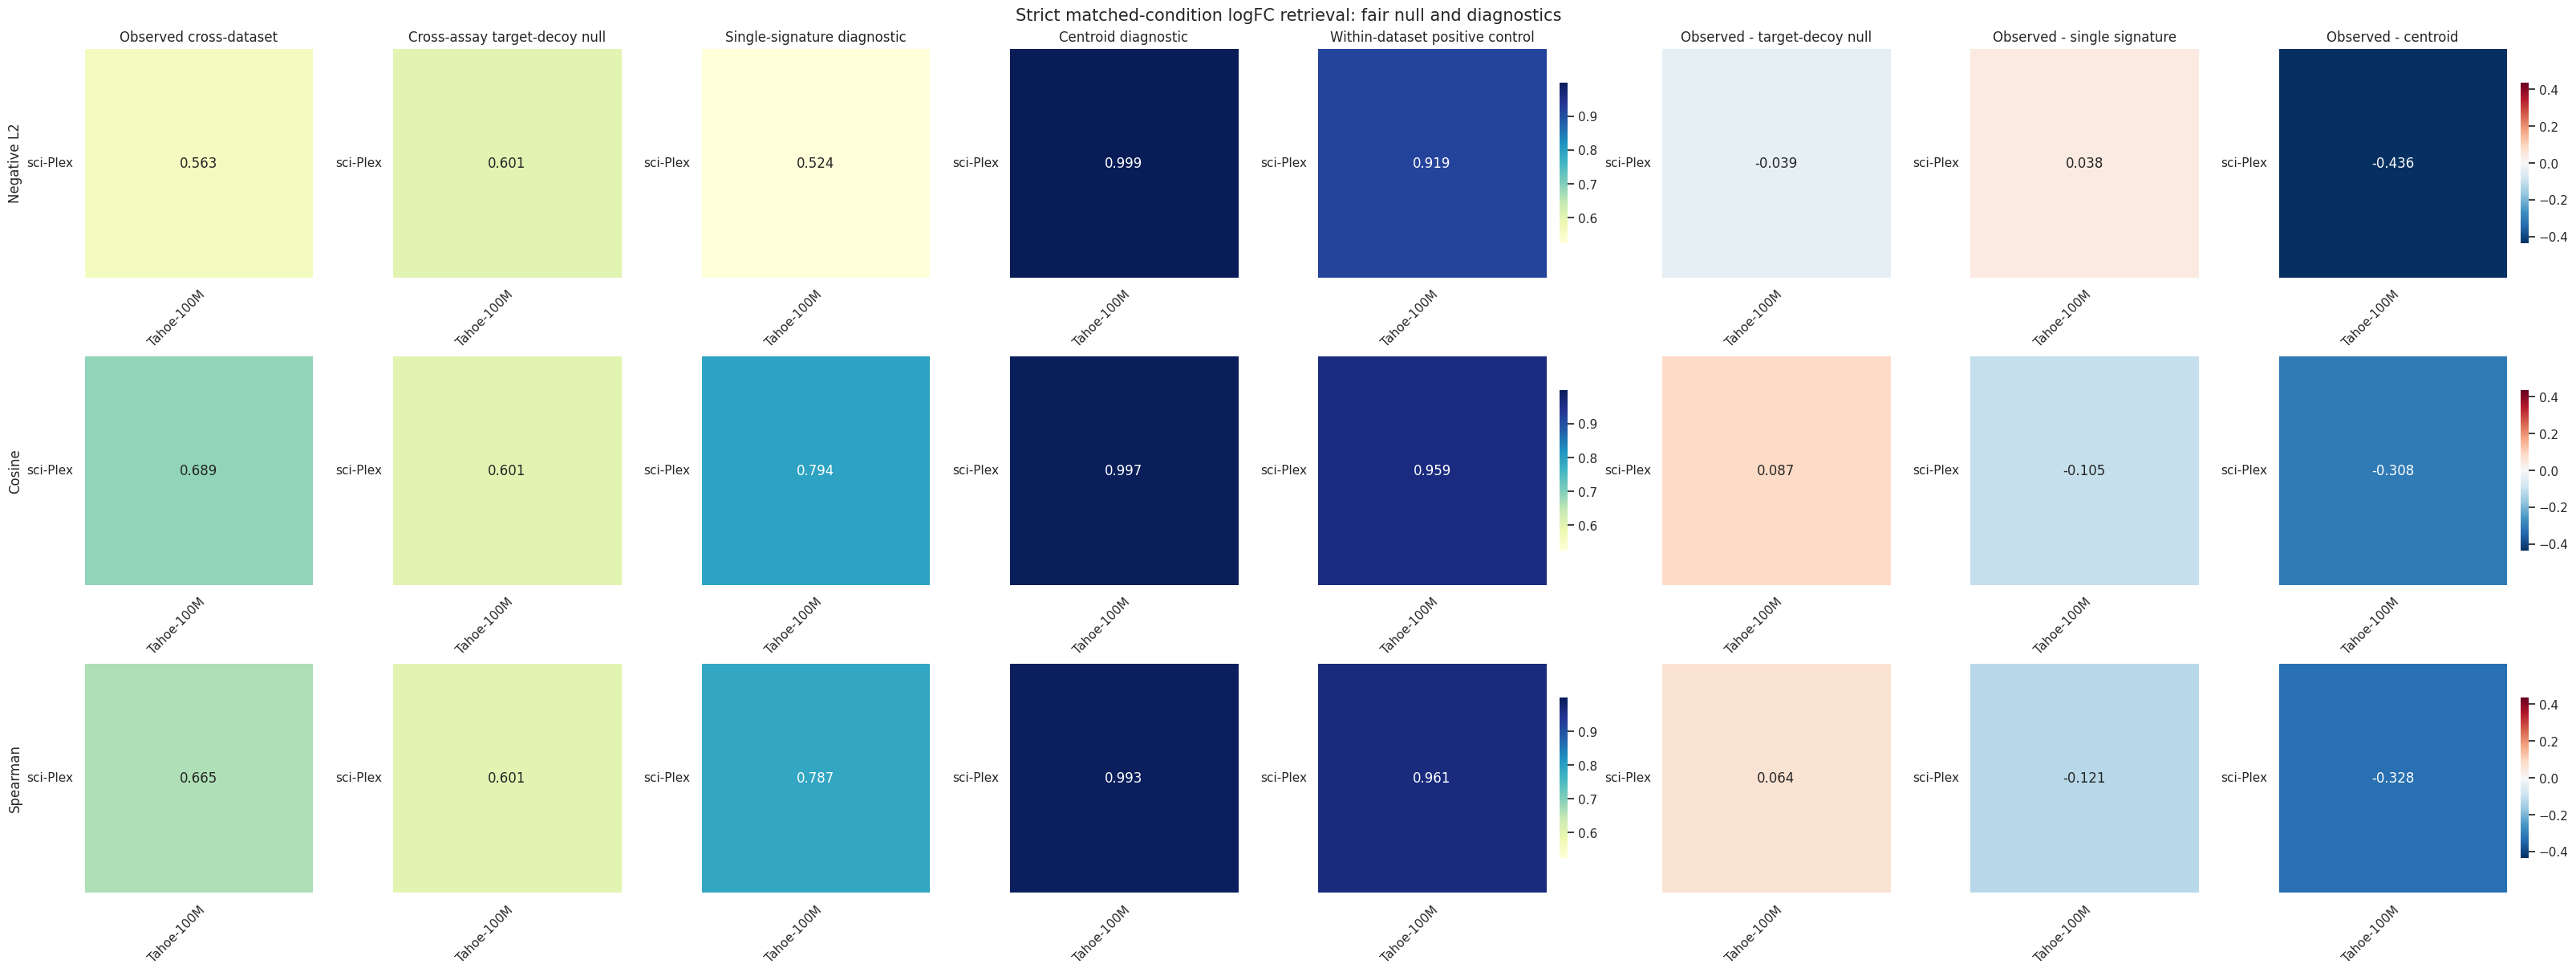

Saved fair-null retrieval heatmaps to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_retrieval_metrics/tahoe__sciplex/strict_logfc_euclidean_cosine_fair_null_heatmaps.pdf


In [20]:
retrieval_ablation_heatmap_path = (
    OUTPUT_DIR / "strict_logfc_euclidean_cosine_fair_null_heatmaps.pdf"
)
score_columns = [
    "mean_observed_normalized_best_positive_rank",
    "mean_target_decoy_null_normalized_best_positive_rank",
    "mean_single_signature_baseline_normalized_best_positive_rank",
    "mean_centroid_baseline_normalized_best_positive_rank",
    "mean_within_dataset_positive_control_normalized_best_positive_rank",
]
delta_columns = [
    "mean_delta_vs_target_decoy_null_normalized_best_positive_rank",
    "mean_delta_vs_single_signature_baseline_normalized_best_positive_rank",
    "mean_delta_vs_centroid_baseline_normalized_best_positive_rank",
]
score_values = pd.concat(
    [retrieval_ablation_pair_summary[column_name] for column_name in score_columns],
    ignore_index=True,
).replace([np.inf, -np.inf], np.nan).dropna()
score_vmin = None if score_values.empty else float(score_values.min())
score_vmax = None if score_values.empty else float(score_values.max())
delta_values = pd.concat(
    [retrieval_ablation_pair_summary[column_name] for column_name in delta_columns],
    ignore_index=True,
).replace([np.inf, -np.inf], np.nan).dropna()
delta_abs_max = (
    None
    if delta_values.empty
    else float(np.max(np.abs(delta_values.to_numpy(dtype=float))))
)

heatmap_specs = [
    (
        "mean_observed_normalized_best_positive_rank",
        "Observed cross-dataset",
        "YlGnBu",
        score_vmin,
        score_vmax,
        None,
    ),
    (
        "mean_target_decoy_null_normalized_best_positive_rank",
        "Cross-assay target-decoy null",
        "YlGnBu",
        score_vmin,
        score_vmax,
        None,
    ),
    (
        "mean_single_signature_baseline_normalized_best_positive_rank",
        "Single-signature diagnostic",
        "YlGnBu",
        score_vmin,
        score_vmax,
        None,
    ),
    (
        "mean_centroid_baseline_normalized_best_positive_rank",
        "Centroid diagnostic",
        "YlGnBu",
        score_vmin,
        score_vmax,
        None,
    ),
    (
        "mean_within_dataset_positive_control_normalized_best_positive_rank",
        "Within-dataset positive control",
        "YlGnBu",
        score_vmin,
        score_vmax,
        None,
    ),
    (
        "mean_delta_vs_target_decoy_null_normalized_best_positive_rank",
        "Observed - target-decoy null",
        "RdBu_r",
        None if delta_abs_max is None else -delta_abs_max,
        delta_abs_max,
        0.0,
    ),
    (
        "mean_delta_vs_single_signature_baseline_normalized_best_positive_rank",
        "Observed - single signature",
        "RdBu_r",
        None if delta_abs_max is None else -delta_abs_max,
        delta_abs_max,
        0.0,
    ),
    (
        "mean_delta_vs_centroid_baseline_normalized_best_positive_rank",
        "Observed - centroid",
        "RdBu_r",
        None if delta_abs_max is None else -delta_abs_max,
        delta_abs_max,
        0.0,
    ),
]
fig, axes = plt.subplots(
    nrows=len(RETRIEVAL_ABLATION_SIMILARITIES),
    ncols=len(heatmap_specs),
    figsize=(32, 4 * len(RETRIEVAL_ABLATION_SIMILARITIES)),
    constrained_layout=True,
)
for row_idx, similarity_metric in enumerate(RETRIEVAL_ABLATION_SIMILARITIES):
    similarity_frame = retrieval_ablation_pair_summary.loc[
        retrieval_ablation_pair_summary["similarity_metric"] == similarity_metric
    ].copy()
    for column_idx, (
        value_column,
        title,
        cmap,
        vmin,
        vmax,
        center,
    ) in enumerate(heatmap_specs):
        matrix = build_symmetric_pair_metric_matrix(
            similarity_frame,
            value_column,
            heatmap_dataset_order,
        )
        display_matrix = matrix.rename(
            index=pretty_label,
            columns=pretty_label,
        ).iloc[1:, :-1]
        mask = np.triu(np.ones(display_matrix.shape, dtype=bool), k=1)
        ax = axes[row_idx, column_idx]
        sns.heatmap(
            display_matrix,
            mask=mask,
            annot=True,
            fmt=".3f",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            center=center,
            linewidths=0.5,
            linecolor="white",
            square=True,
            cbar=column_idx in {4, 7},
            cbar_kws={"shrink": 0.7},
            ax=ax,
        )
        if row_idx == 0:
            ax.set_title(title)
        ax.set_xlabel("")
        row_label = {
            "negative_l2": "Negative L2",
            "cosine": "Cosine",
            "spearman": "Spearman",
        }[similarity_metric]
        ax.set_ylabel(row_label if column_idx == 0 else "")
        ax.set_xticklabels(
            ax.get_xticklabels(),
            rotation=45,
            ha="right",
            rotation_mode="anchor",
        )
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
        ax.grid(False)
fig.suptitle(
    "Strict matched-condition logFC retrieval: fair null and diagnostics",
    fontsize=15,
)
fig.savefig(retrieval_ablation_heatmap_path, bbox_inches="tight")
plt.show()
print(f"Saved fair-null retrieval heatmaps to {retrieval_ablation_heatmap_path}")

## Cosine/Spearman individual-signature baseline score distributions

These cells implement the reviewer's score-level sensitivity analysis for strict matched-condition `logFC` retrieval. For each query, the observed score is the **best strict positive** (matching the notebook's best-positive retrieval definition). Different-compound peers are scored separately and summarized without averaging their expression vectors.

- **Source individuals:** same query dataset, line, time, and exact raw dose; different compound.
- **Target individuals:** target dataset, line, time, and the exact raw dose of the best observed positive; different compound.
- **Source/target centroids:** gene-wise means of those same peer sets, retained as smoothing diagnostics.
- **Similarity:** cosine and Spearman; larger is always better.
- **Corrected percentile:** `(1 + number of peer scores below observed) / (K + 1)`.
- **Empirical one-sided p-value:** `(1 + number of peer scores at least as large as observed) / (K + 1)`.

Run the notebook setup through cell 23 first. These cells recompute only the focused logFC score distributions and their summaries.


In [21]:
RAW_SCORE_SIMILARITIES = ("cosine", "spearman")
RAW_SCORE_REPRESENTATION = "logFC"
RAW_SCORE_RETRIEVAL_VARIANT = "strict_matched_condition"


def focused_exact_cross_assay_target_decoy_null(
    n_candidates: int,
    n_positives: int,
) -> dict[str, float]:
    """Expected metrics after uniformly relabeling K positives among N targets."""
    n_candidates = int(n_candidates)
    n_positives = int(n_positives)
    if n_candidates < 2 or n_positives < 1 or n_positives >= n_candidates:
        return {
            "best_rank": float("nan"),
            "normalized_rank": float("nan"),
            "recall_at_1": float("nan"),
            "auroc": float("nan"),
        }
    expected_best_rank = float(
        (n_candidates + 1.0) / (n_positives + 1.0)
    )
    return {
        "best_rank": expected_best_rank,
        "normalized_rank": float(
            1.0
            - (expected_best_rank - 1.0) / (n_candidates - 1.0)
        ),
        "recall_at_1": float(n_positives / n_candidates),
        "auroc": 0.5,
    }


def rowwise_rank_matrix(matrix: np.ndarray) -> np.ndarray:
    matrix = np.asarray(matrix, dtype=np.float64)
    if matrix.ndim != 2:
        raise ValueError("matrix must be two-dimensional")
    if matrix.shape[0] == 0:
        return np.empty_like(matrix, dtype=np.float64)
    return np.asarray(
        rankdata(matrix, axis=1, method="average"),
        dtype=np.float64,
    )


def normalized_dot_similarity_matrix(
    query_matrix: np.ndarray,
    candidate_matrix: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    query_matrix = np.asarray(query_matrix, dtype=np.float64)
    candidate_matrix = np.asarray(candidate_matrix, dtype=np.float64)
    query_norms = np.linalg.norm(query_matrix, axis=1)
    candidate_norms = np.linalg.norm(candidate_matrix, axis=1)
    valid_queries = (
        np.isfinite(query_matrix).all(axis=1)
        & np.isfinite(query_norms)
        & (query_norms > 0.0)
    )
    valid_candidates = (
        np.isfinite(candidate_matrix).all(axis=1)
        & np.isfinite(candidate_norms)
        & (candidate_norms > 0.0)
    )
    scores = np.full(
        (len(query_matrix), len(candidate_matrix)),
        np.nan,
        dtype=np.float64,
    )
    if valid_queries.any() and valid_candidates.any():
        normalized_queries = (
            query_matrix[valid_queries] / query_norms[valid_queries, None]
        )
        normalized_candidates = (
            candidate_matrix[valid_candidates]
            / candidate_norms[valid_candidates, None]
        )
        scores[np.ix_(valid_queries, valid_candidates)] = np.clip(
            normalized_queries @ normalized_candidates.T,
            -1.0,
            1.0,
        )
    return scores, valid_queries, valid_candidates


def focused_similarity_matrix(
    query_matrix: np.ndarray,
    candidate_matrix: np.ndarray,
    similarity_metric: str,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    prepared_queries, valid_queries = prepare_focused_similarity_vectors(
        query_matrix,
        similarity_metric,
    )
    prepared_candidates, valid_candidates = (
        prepare_focused_similarity_vectors(
            candidate_matrix,
            similarity_metric,
        )
    )
    scores = np.full(
        (len(prepared_queries), len(prepared_candidates)),
        np.nan,
        dtype=np.float64,
    )
    if valid_queries.any() and valid_candidates.any():
        scores[np.ix_(valid_queries, valid_candidates)] = np.clip(
            prepared_queries[valid_queries]
            @ prepared_candidates[valid_candidates].T,
            -1.0,
            1.0,
        )
    return scores, valid_queries, valid_candidates


def prepare_focused_similarity_vectors(
    matrix: np.ndarray,
    similarity_metric: str,
) -> tuple[np.ndarray, np.ndarray]:
    """Rank/center/normalize each signature once for reusable dot products."""
    matrix = np.asarray(matrix, dtype=np.float64)
    if matrix.ndim != 2:
        raise ValueError("matrix must be two-dimensional")
    if similarity_metric == "cosine":
        transformed = matrix.copy()
    elif similarity_metric == "spearman":
        transformed = rowwise_rank_matrix(matrix)
        transformed -= transformed.mean(axis=1, keepdims=True)
    else:
        raise KeyError(
            f"Unsupported focused similarity metric: {similarity_metric}"
        )

    norms = np.linalg.norm(transformed, axis=1)
    valid = (
        np.isfinite(transformed).all(axis=1)
        & np.isfinite(norms)
        & (norms > 0.0)
    )
    prepared = np.zeros_like(transformed, dtype=np.float64)
    prepared[valid] = transformed[valid] / norms[valid, None]
    return prepared, valid


def focused_similarity_from_prepared_query(
    prepared_query: np.ndarray,
    raw_candidate: np.ndarray,
    similarity_metric: str,
) -> float:
    prepared_candidate, valid_candidate = (
        prepare_focused_similarity_vectors(
            np.asarray(raw_candidate, dtype=np.float64)[None, :],
            similarity_metric,
        )
    )
    if not bool(valid_candidate[0]):
        return float("nan")
    return float(
        np.clip(
            np.asarray(prepared_query, dtype=np.float64)
            @ prepared_candidate[0],
            -1.0,
            1.0,
        )
    )


def focused_vector_similarity(
    query_vector: np.ndarray,
    candidate_vector: np.ndarray,
    similarity_metric: str,
) -> float:
    scores, valid_query, valid_candidate = focused_similarity_matrix(
        np.asarray(query_vector, dtype=np.float64)[None, :],
        np.asarray(candidate_vector, dtype=np.float64)[None, :],
        similarity_metric,
    )
    if not bool(valid_query[0]) or not bool(valid_candidate[0]):
        return float("nan")
    return float(scores[0, 0])


def load_focused_logfc_pool(
    pool_frame: pd.DataFrame,
    source: LineSource,
    gene_positions: np.ndarray,
) -> tuple[pd.DataFrame, np.ndarray, list[dict[str, object]]]:
    resolved_records: list[dict[str, object]] = []
    unresolved_records: list[dict[str, object]] = []
    vectors: list[np.ndarray] = []
    for _, row in pool_frame.iterrows():
        lookup = {
            "pubchem_cid": str(row["pubchem_cid"]),
            "dose_key": str(row["dose_key"]),
            "time_key": str(row["time_key"]),
        }
        try:
            vector = source.get_vector(
                str(row["obs_id"]),
                "logFC",
                **lookup,
            )
            vectors.append(
                np.asarray(vector, dtype=np.float64)[gene_positions]
            )
            resolved_records.append(row.to_dict())
        except KeyError as exc:
            unresolved_records.append(
                {
                    **row.to_dict(),
                    "source_dataset": source.dataset_name,
                    "source_cell_type": source.cell_type,
                    "source_path": str(source.path),
                    "error": str(exc),
                }
            )
    if not vectors:
        return (
            pool_frame.iloc[0:0].copy(),
            np.empty((0, 0), dtype=np.float64),
            unresolved_records,
        )
    return (
        pd.DataFrame(resolved_records).reset_index(drop=True),
        np.vstack(vectors).astype(np.float64),
        unresolved_records,
    )


def peer_score_distribution_summary(
    observed_score: float,
    peer_scores: np.ndarray,
    prefix: str,
) -> dict[str, float | int]:
    peer_scores = np.asarray(peer_scores, dtype=np.float64)
    peer_scores = peer_scores[np.isfinite(peer_scores)]
    k = int(len(peer_scores))
    if k == 0 or not np.isfinite(observed_score):
        return {
            f"{prefix}_n": k,
            f"{prefix}_mean_similarity": float("nan"),
            f"{prefix}_sd_similarity": float("nan"),
            f"{prefix}_n_below_observed": 0,
            f"{prefix}_fraction_below_observed": float("nan"),
            f"{prefix}_corrected_percentile": float("nan"),
            f"{prefix}_n_at_least_observed": 0,
            f"{prefix}_empirical_p_upper": float("nan"),
        }

    n_below = int(np.sum(peer_scores < float(observed_score)))
    n_at_least = int(np.sum(peer_scores >= float(observed_score)))
    return {
        f"{prefix}_n": k,
        f"{prefix}_mean_similarity": float(np.mean(peer_scores)),
        f"{prefix}_sd_similarity": (
            float(np.std(peer_scores, ddof=1)) if k >= 2 else float("nan")
        ),
        f"{prefix}_n_below_observed": n_below,
        f"{prefix}_fraction_below_observed": float(n_below / k),
        f"{prefix}_corrected_percentile": float((n_below + 1.0) / (k + 1.0)),
        f"{prefix}_n_at_least_observed": n_at_least,
        f"{prefix}_empirical_p_upper": float(
            (n_at_least + 1.0) / (k + 1.0)
        ),
    }


def empty_peer_score_distribution_summary(
    prefix: str,
) -> dict[str, float | int]:
    return peer_score_distribution_summary(
        float("nan"),
        np.empty(0, dtype=np.float64),
        prefix,
    )


# Hand-check the score summaries and the add-one correction before the data loop.
_test_observed_score = 0.60
_test_peer_scores = np.asarray([0.10, 0.20, 0.55, 0.70])
_test_summary = peer_score_distribution_summary(
    _test_observed_score,
    _test_peer_scores,
    "test",
)
assert _test_summary["test_n"] == 4
assert _test_summary["test_n_below_observed"] == 3
assert np.isclose(_test_summary["test_fraction_below_observed"], 0.75)
assert np.isclose(_test_summary["test_corrected_percentile"], 0.80)
assert np.isclose(_test_summary["test_empirical_p_upper"], 0.40)

_test_q = np.asarray([[1.0, 2.0, 3.0]])
_test_c = np.asarray([[2.0, 4.0, 6.0], [3.0, 2.0, 1.0]])
_test_cosine, _, _ = focused_similarity_matrix(_test_q, _test_c, "cosine")
_test_spearman, _, _ = focused_similarity_matrix(_test_q, _test_c, "spearman")
assert np.isclose(_test_cosine[0, 0], 1.0)
assert np.isclose(_test_spearman[0, 0], 1.0)
assert np.isclose(_test_spearman[0, 1], -1.0)
print("Focused cosine/Spearman helper checks passed.")


Focused cosine/Spearman helper checks passed.


In [22]:
focused_score_records: list[dict[str, object]] = []
focused_score_skipped_records: list[dict[str, object]] = []
focused_score_unresolved_records: list[dict[str, object]] = []

focused_query_path = (
    OUTPUT_DIR / "retrieval_cosine_spearman_peer_baselines_query.tsv"
)
FOCUSED_RETRIEVAL_FINGERPRINT = stable_json_fingerprint(
    {
        "version": "focused-retrieval-v2",
        "ablation": RETRIEVAL_ABLATION_FINGERPRINT,
        "metrics": RAW_SCORE_SIMILARITIES,
        "contexts": frame_identity_fingerprint(pair_contexts),
    }
)
focused_is_cached = is_cached(
    "focused_retrieval",
    focused_query_path,
    fingerprint=FOCUSED_RETRIEVAL_FINGERPRINT,
)
focused_context_input = pair_contexts.iloc[0:0] if focused_is_cached else pair_contexts
focused_progress = ProgressReporter(
    total=len(focused_context_input),
    label="focused_retrieval_contexts",
    every=1,
    min_interval_seconds=20.0,
)
for context_index, (_, context_row) in enumerate(focused_context_input.iterrows(), start=1):
    dataset_a = str(context_row["dataset_a"])
    dataset_b = str(context_row["dataset_b"])
    cell_type = str(context_row["cell_type"])
    time_key = str(context_row["time_key"])
    focused_progress.update(
        completed=context_index - 1,
        detail=f"{pretty_label(dataset_a)} vs {pretty_label(dataset_b)} / {cell_type} / {time_key}",
        force=True,
    )

    left_pool = pool_frame_for_context(
        dataset_indices[dataset_a]["frame"],
        cell_type,
        time_key,
    )
    right_pool = pool_frame_for_context(
        dataset_indices[dataset_b]["frame"],
        cell_type,
        time_key,
    )
    if (
        len(left_pool) < MIN_TARGET_CANDIDATES
        or len(right_pool) < MIN_TARGET_CANDIDATES
    ):
        continue

    left_source = get_line_source(dataset_a, cell_type)
    right_source = get_line_source(dataset_b, cell_type)
    shared_genes, left_gene_pos, right_gene_pos = shared_gene_positions(
        left_source,
        right_source,
    )
    if shared_genes.size < 2:
        continue

    left_pool, left_logfc, left_unresolved = load_focused_logfc_pool(
        left_pool,
        left_source,
        left_gene_pos,
    )
    right_pool, right_logfc, right_unresolved = load_focused_logfc_pool(
        right_pool,
        right_source,
        right_gene_pos,
    )
    focused_score_unresolved_records.extend(
        [
            {
                **record,
                "dataset_a": dataset_a,
                "dataset_b": dataset_b,
                "direction": "A_to_B",
                "cell_type": cell_type,
                "time_key": time_key,
            }
            for record in left_unresolved
        ]
    )
    focused_score_unresolved_records.extend(
        [
            {
                **record,
                "dataset_a": dataset_a,
                "dataset_b": dataset_b,
                "direction": "B_to_A",
                "cell_type": cell_type,
                "time_key": time_key,
            }
            for record in right_unresolved
        ]
    )
    if (
        len(left_pool) < MIN_TARGET_CANDIDATES
        or len(right_pool) < MIN_TARGET_CANDIDATES
        or left_logfc.size == 0
        or right_logfc.size == 0
    ):
        continue

    finite_gene_mask = (
        np.isfinite(left_logfc).all(axis=0)
        & np.isfinite(right_logfc).all(axis=0)
    )
    shared_genes = shared_genes[finite_gene_mask]
    left_logfc = left_logfc[:, finite_gene_mask]
    right_logfc = right_logfc[:, finite_gene_mask]
    if shared_genes.size < 2:
        continue

    directional_specs = [
        {
            "direction": "A_to_B",
            "query_dataset": dataset_a,
            "target_dataset": dataset_b,
            "query_pool": left_pool,
            "target_pool": right_pool,
            "query_matrix": left_logfc,
            "target_matrix": right_logfc,
            "strict_map": strict_positive_maps.get(
                (dataset_a, dataset_b, "A_to_B"),
                {},
            ),
        },
        {
            "direction": "B_to_A",
            "query_dataset": dataset_b,
            "target_dataset": dataset_a,
            "query_pool": right_pool,
            "target_pool": left_pool,
            "query_matrix": right_logfc,
            "target_matrix": left_logfc,
            "strict_map": strict_positive_maps.get(
                (dataset_a, dataset_b, "B_to_A"),
                {},
            ),
        },
    ]

    for direction_spec in directional_specs:
        query_pool = direction_spec["query_pool"].reset_index(drop=True)
        target_pool = direction_spec["target_pool"].reset_index(drop=True)
        query_matrix = np.asarray(
            direction_spec["query_matrix"],
            dtype=np.float64,
        )
        target_matrix = np.asarray(
            direction_spec["target_matrix"],
            dtype=np.float64,
        )

        query_obs_ids = query_pool["obs_id"].astype(str).to_numpy(dtype=object)
        query_compounds = (
            query_pool["pubchem_cid"].astype(str).to_numpy(dtype=object)
        )
        query_dose_keys = (
            query_pool["dose_key"].astype(str).to_numpy(dtype=object)
        )
        query_doses_uM = query_pool["pert_dose_uM"].to_numpy(dtype=np.float64)
        target_obs_ids = target_pool["obs_id"].astype(str).to_numpy(dtype=object)
        target_compounds = (
            target_pool["pubchem_cid"].astype(str).to_numpy(dtype=object)
        )
        target_dose_keys = (
            target_pool["dose_key"].astype(str).to_numpy(dtype=object)
        )
        target_doses_uM = target_pool["pert_dose_uM"].to_numpy(dtype=np.float64)

        for similarity_metric in RAW_SCORE_SIMILARITIES:
            prepared_queries, valid_queries = (
                prepare_focused_similarity_vectors(
                    query_matrix,
                    similarity_metric,
                )
            )
            prepared_targets, valid_targets = (
                prepare_focused_similarity_vectors(
                    target_matrix,
                    similarity_metric,
                )
            )
            target_keep_indices = np.flatnonzero(valid_targets)
            if len(target_keep_indices) < MIN_TARGET_CANDIDATES:
                continue
            similarity_matrix = np.clip(
                prepared_queries
                @ prepared_targets[target_keep_indices].T,
                -1.0,
                1.0,
            )
            filtered_target_obs_ids = target_obs_ids[target_keep_indices]
            filtered_target_compounds = target_compounds[target_keep_indices]
            filtered_target_dose_keys = target_dose_keys[target_keep_indices]
            filtered_target_doses_uM = target_doses_uM[target_keep_indices]
            filtered_target_matrix = target_matrix[target_keep_indices]

            for query_idx in range(len(query_pool)):
                query_obs_id = str(query_obs_ids[query_idx])
                query_compound = str(query_compounds[query_idx])
                query_dose_key = str(query_dose_keys[query_idx])
                query_dose_uM = float(query_doses_uM[query_idx])
                if not bool(valid_queries[query_idx]):
                    focused_score_skipped_records.append(
                        {
                            "dataset_a": dataset_a,
                            "dataset_b": dataset_b,
                            "direction": direction_spec["direction"],
                            "query_dataset": direction_spec["query_dataset"],
                            "target_dataset": direction_spec["target_dataset"],
                            "cell_type": cell_type,
                            "time_key": time_key,
                            "query_obs_id": query_obs_id,
                            "query_pubchem_cid": query_compound,
                            "query_dose_key": query_dose_key,
                            "similarity_metric": similarity_metric,
                            "reason": "zero_norm_or_constant_query",
                        }
                    )
                    continue

                query_scores = similarity_matrix[query_idx]
                positive_mask = strict_positive_mask(
                    query_obs_id,
                    filtered_target_obs_ids,
                    direction_spec["strict_map"],
                )
                observed_metrics = summarize_retrieval_scores(
                    query_scores,
                    positive_mask,
                )
                if (
                    observed_metrics["n_positives"] == 0
                    or observed_metrics["n_negatives"] == 0
                ):
                    continue

                positive_indices = np.flatnonzero(positive_mask)
                positive_scores = query_scores[positive_indices]
                best_positive_local_idx = int(
                    positive_indices[int(np.argmax(positive_scores))]
                )
                observed_best_score = float(
                    query_scores[best_positive_local_idx]
                )
                observed_mean_positive_score = float(
                    np.mean(positive_scores)
                )
                observed_sd_positive_score = (
                    float(np.std(positive_scores, ddof=1))
                    if len(positive_scores) >= 2
                    else float("nan")
                )
                best_target_obs_id = str(
                    filtered_target_obs_ids[best_positive_local_idx]
                )
                best_target_dose_key = str(
                    filtered_target_dose_keys[best_positive_local_idx]
                )
                best_target_dose_uM = float(
                    filtered_target_doses_uM[best_positive_local_idx]
                )

                source_peer_mask = (
                    (query_dose_keys.astype(str) == query_dose_key)
                    & (query_compounds.astype(str) != query_compound)
                    & valid_queries
                )
                source_peer_matrix = query_matrix[source_peer_mask]
                source_peer_scores = np.clip(
                    prepared_queries[query_idx]
                    @ prepared_queries[source_peer_mask].T,
                    -1.0,
                    1.0,
                )
                source_summary = peer_score_distribution_summary(
                    observed_best_score,
                    source_peer_scores,
                    "source_individual",
                )
                source_centroid_similarity = float("nan")
                if len(source_peer_matrix) > 0:
                    source_centroid = source_peer_matrix.mean(
                        axis=0,
                        dtype=np.float64,
                    )
                    source_centroid_similarity = (
                        focused_similarity_from_prepared_query(
                            prepared_queries[query_idx],
                            source_centroid,
                            similarity_metric,
                        )
                    )

                target_peer_mask = (
                    (
                        filtered_target_dose_keys.astype(str)
                        == best_target_dose_key
                    )
                    & (
                        filtered_target_compounds.astype(str)
                        != query_compound
                    )
                )
                target_peer_scores = query_scores[target_peer_mask]
                target_peer_matrix = filtered_target_matrix[target_peer_mask]
                target_summary = peer_score_distribution_summary(
                    observed_best_score,
                    target_peer_scores,
                    "target_individual",
                )
                target_centroid_similarity = float("nan")
                if len(target_peer_matrix) > 0:
                    target_centroid = target_peer_matrix.mean(
                        axis=0,
                        dtype=np.float64,
                    )
                    target_centroid_similarity = (
                        focused_similarity_from_prepared_query(
                            prepared_queries[query_idx],
                            target_centroid,
                            similarity_metric,
                        )
                    )

                target_decoy_null = focused_exact_cross_assay_target_decoy_null(
                    n_candidates=len(query_scores),
                    n_positives=int(observed_metrics["n_positives"]),
                )
                focused_score_records.append(
                    {
                        "dataset_a": dataset_a,
                        "dataset_b": dataset_b,
                        "direction": direction_spec["direction"],
                        "query_dataset": direction_spec["query_dataset"],
                        "target_dataset": direction_spec["target_dataset"],
                        "cell_type": cell_type,
                        "time_key": time_key,
                        "representation": RAW_SCORE_REPRESENTATION,
                        "retrieval_variant": RAW_SCORE_RETRIEVAL_VARIANT,
                        "similarity_metric": similarity_metric,
                        "query_obs_id": query_obs_id,
                        "query_pubchem_cid": query_compound,
                        "query_dose_key": query_dose_key,
                        "query_dose_uM": query_dose_uM,
                        "best_target_obs_id": best_target_obs_id,
                        "best_target_dose_key": best_target_dose_key,
                        "best_target_dose_uM": best_target_dose_uM,
                        "best_target_dose_fold_difference": float(
                            max(
                                query_dose_uM / best_target_dose_uM,
                                best_target_dose_uM / query_dose_uM,
                            )
                        ),
                        "target_pool_size": int(len(query_scores)),
                        "n_positive_candidates": int(
                            observed_metrics["n_positives"]
                        ),
                        "n_shared_genes": int(shared_genes.size),
                        "observed_best_positive_similarity": (
                            observed_best_score
                        ),
                        "observed_mean_positive_similarity": (
                            observed_mean_positive_score
                        ),
                        "observed_sd_positive_similarity": (
                            observed_sd_positive_score
                        ),
                        "observed_normalized_best_positive_rank": (
                            observed_metrics["normalized_rank"]
                        ),
                        "observed_recall_at_1": (
                            observed_metrics["recall_at_1"]
                        ),
                        "observed_auroc": observed_metrics["auroc"],
                        "target_decoy_null_normalized_best_positive_rank": (
                            target_decoy_null["normalized_rank"]
                        ),
                        "target_decoy_null_recall_at_1": (
                            target_decoy_null["recall_at_1"]
                        ),
                        "target_decoy_null_auroc": (
                            target_decoy_null["auroc"]
                        ),
                        **source_summary,
                        **target_summary,
                        "source_centroid_similarity": (
                            source_centroid_similarity
                        ),
                        "target_centroid_similarity": (
                            target_centroid_similarity
                        ),
                        "delta_observed_vs_source_individual_mean": (
                            difference_if_both_defined(
                                observed_best_score,
                                source_summary[
                                    "source_individual_mean_similarity"
                                ],
                            )
                        ),
                        "delta_observed_vs_target_individual_mean": (
                            difference_if_both_defined(
                                observed_best_score,
                                target_summary[
                                    "target_individual_mean_similarity"
                                ],
                            )
                        ),
                        "delta_observed_vs_source_centroid": (
                            difference_if_both_defined(
                                observed_best_score,
                                source_centroid_similarity,
                            )
                        ),
                        "delta_observed_vs_target_centroid": (
                            difference_if_both_defined(
                                observed_best_score,
                                target_centroid_similarity,
                            )
                        ),
                        "delta_observed_vs_target_decoy_null_rank": (
                            difference_if_both_defined(
                                observed_metrics["normalized_rank"],
                                target_decoy_null["normalized_rank"],
                            )
                        ),
                        "delta_observed_vs_target_decoy_null_recall_at_1": (
                            difference_if_both_defined(
                                observed_metrics["recall_at_1"],
                                target_decoy_null["recall_at_1"],
                            )
                        ),
                        "delta_observed_vs_target_decoy_null_auroc": (
                            difference_if_both_defined(
                                observed_metrics["auroc"],
                                target_decoy_null["auroc"],
                            )
                        ),
                    }
                )

def build_focused_retrieval_metrics() -> pd.DataFrame:
    frame = pd.DataFrame(focused_score_records)
    if frame.empty:
        raise ValueError(
            "No strict-logFC cosine/Spearman peer-baseline queries were scored."
        )
    return frame

retrieval_cosine_spearman_peer_baselines_query = cached_frame(
    "focused_retrieval",
    focused_query_path,
    build_focused_retrieval_metrics,
    fingerprint=FOCUSED_RETRIEVAL_FINGERPRINT,
)

focused_score_skipped = pd.DataFrame(focused_score_skipped_records)
if not focused_score_skipped.empty:
    focused_skipped_path = (
        OUTPUT_DIR / "retrieval_cosine_spearman_peer_baselines_skipped.tsv"
    )
    focused_score_skipped.to_csv(
        focused_skipped_path,
        sep="\t",
        index=False,
    )
    print(f"Saved focused skipped-query diagnostics to {focused_skipped_path}")

focused_score_unresolved = pd.DataFrame(focused_score_unresolved_records)
if not focused_score_unresolved.empty:
    focused_unresolved_path = (
        OUTPUT_DIR / "retrieval_cosine_spearman_peer_baselines_unresolved.tsv"
    )
    focused_score_unresolved.to_csv(
        focused_unresolved_path,
        sep="\t",
        index=False,
    )
    print(f"Saved focused unresolved-signature diagnostics to {focused_unresolved_path}")

display(
    retrieval_cosine_spearman_peer_baselines_query.head()
)


Saved focused query-level score table to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_retrieval_metrics/tahoe__sciplex/retrieval_cosine_spearman_peer_baselines_query.tsv
Saved focused unresolved-signature diagnostics to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_retrieval_metrics/tahoe__sciplex/retrieval_cosine_spearman_peer_baselines_unresolved.tsv


,dataset_a,dataset_b,direction,query_dataset,target_dataset,cell_type,time_key,representation,retrieval_variant,similarity_metric,...,target_individual_empirical_p_upper,source_centroid_similarity,target_centroid_similarity,delta_observed_vs_source_individual_mean,delta_observed_vs_target_individual_mean,delta_observed_vs_source_centroid,delta_observed_vs_target_centroid,delta_observed_vs_target_decoy_null_rank,delta_observed_vs_target_decoy_null_recall_at_1,delta_observed_vs_target_decoy_null_auroc
0,tahoe,sciplex,A_to_B,tahoe,sciplex,CVCL_0023,24,logFC,strict_matched_condition,cosine,...,0.714286,0.495541,-0.005053,-0.258844,-0.013034,-0.510319,-0.009726,-0.298947,-0.004202,-0.132911
1,tahoe,sciplex,A_to_B,tahoe,sciplex,CVCL_0023,24,logFC,strict_matched_condition,cosine,...,0.007519,0.327089,-0.012992,-0.040561,0.127992,-0.200701,0.139380,0.324211,-0.004202,0.491561
2,tahoe,sciplex,A_to_B,tahoe,sciplex,CVCL_0023,24,logFC,strict_matched_condition,cosine,...,0.187970,0.398383,-0.018600,-0.182593,0.019579,-0.382961,0.034022,0.136842,-0.004202,0.303797
3,tahoe,sciplex,A_to_B,tahoe,sciplex,CVCL_0023,24,logFC,strict_matched_condition,cosine,...,0.488722,0.402830,-0.070678,-0.233632,-0.002220,-0.423352,0.050155,-0.145263,-0.004202,0.021097
4,tahoe,sciplex,A_to_B,tahoe,sciplex,CVCL_0023,24,logFC,strict_matched_condition,cosine,...,0.681818,0.611925,-0.004224,-0.348528,-0.014125,-0.628660,-0.012511,-0.345263,-0.004202,-0.179325


In [23]:
FOCUSED_COUNT_COLUMNS = {
    "target_pool_size",
    "n_positive_candidates",
    "n_shared_genes",
    "source_individual_n",
    "source_individual_n_below_observed",
    "source_individual_n_at_least_observed",
    "target_individual_n",
    "target_individual_n_below_observed",
    "target_individual_n_at_least_observed",
    "query_dose_uM",
    "best_target_dose_uM",
    "best_target_dose_fold_difference",
}
FOCUSED_ID_COLUMNS = {
    "dataset_a",
    "dataset_b",
    "direction",
    "query_dataset",
    "target_dataset",
    "cell_type",
    "time_key",
    "representation",
    "retrieval_variant",
    "similarity_metric",
    "query_obs_id",
    "query_pubchem_cid",
    "query_dose_key",
    "best_target_obs_id",
    "best_target_dose_key",
}
FOCUSED_METRIC_COLUMNS = [
    column_name
    for column_name in retrieval_cosine_spearman_peer_baselines_query.columns
    if column_name not in FOCUSED_ID_COLUMNS
    and column_name not in FOCUSED_COUNT_COLUMNS
    and pd.api.types.is_numeric_dtype(
        retrieval_cosine_spearman_peer_baselines_query[column_name]
    )
]

focused_line_time_group_columns = [
    "dataset_a",
    "dataset_b",
    "direction",
    "query_dataset",
    "target_dataset",
    "cell_type",
    "time_key",
    "representation",
    "retrieval_variant",
    "similarity_metric",
]
focused_line_time_agg: dict[str, tuple[str, object]] = {
    "n_queries": ("query_obs_id", "size"),
    "n_unique_query_compounds": ("query_pubchem_cid", "nunique"),
    "n_queries_with_source_individuals": (
        "source_individual_n",
        lambda values: int((values > 0).sum()),
    ),
    "n_queries_with_target_individuals": (
        "target_individual_n",
        lambda values: int((values > 0).sum()),
    ),
    "mean_source_individual_n": ("source_individual_n", "mean"),
    "mean_target_individual_n": ("target_individual_n", "mean"),
}
for column_name in FOCUSED_METRIC_COLUMNS:
    focused_line_time_agg[f"mean_{column_name}"] = (
        column_name,
        "mean",
    )

retrieval_cosine_spearman_line_time_summary = (
    retrieval_cosine_spearman_peer_baselines_query.groupby(
        focused_line_time_group_columns,
        as_index=False,
    )
    .agg(**focused_line_time_agg)
    .sort_values(focused_line_time_group_columns)
    .reset_index(drop=True)
)
focused_summary_mean_columns = [
    column_name
    for column_name in retrieval_cosine_spearman_line_time_summary.columns
    if column_name.startswith("mean_")
]


def aggregate_focused_score_summary(
    frame: pd.DataFrame,
    group_columns: list[str],
    *,
    include_direction_count: bool = False,
) -> pd.DataFrame:
    agg: dict[str, tuple[str, object]] = {
        "n_line_time_strata": ("cell_type", "size"),
        "n_queries": ("n_queries", "sum"),
        "n_queries_with_source_individuals": (
            "n_queries_with_source_individuals",
            "sum",
        ),
        "n_queries_with_target_individuals": (
            "n_queries_with_target_individuals",
            "sum",
        ),
    }
    if include_direction_count:
        agg["n_directions"] = ("direction", "nunique")
    for column_name in focused_summary_mean_columns:
        agg[column_name] = (column_name, "mean")
    return (
        frame.groupby(group_columns, as_index=False)
        .agg(**agg)
        .sort_values(group_columns)
        .reset_index(drop=True)
    )


retrieval_cosine_spearman_pair_direction_summary = (
    aggregate_focused_score_summary(
        retrieval_cosine_spearman_line_time_summary,
        [
            "dataset_a",
            "dataset_b",
            "direction",
            "query_dataset",
            "target_dataset",
            "representation",
            "retrieval_variant",
            "similarity_metric",
        ],
    )
)
focused_pair_agg: dict[str, tuple[str, object]] = {
    "n_directions": ("direction", "nunique"),
    "n_line_time_strata": ("n_line_time_strata", "sum"),
    "n_queries": ("n_queries", "sum"),
    "n_queries_with_source_individuals": (
        "n_queries_with_source_individuals",
        "sum",
    ),
    "n_queries_with_target_individuals": (
        "n_queries_with_target_individuals",
        "sum",
    ),
}
for column_name in focused_summary_mean_columns:
    focused_pair_agg[column_name] = (column_name, "mean")
retrieval_cosine_spearman_pair_summary = (
    retrieval_cosine_spearman_pair_direction_summary.groupby(
        [
            "dataset_a",
            "dataset_b",
            "representation",
            "retrieval_variant",
            "similarity_metric",
        ],
        as_index=False,
    )
    .agg(**focused_pair_agg)
    .sort_values(["dataset_a", "dataset_b", "similarity_metric"])
    .reset_index(drop=True)
)
retrieval_cosine_spearman_line_summary = aggregate_focused_score_summary(
    retrieval_cosine_spearman_line_time_summary,
    [
        "dataset_a",
        "dataset_b",
        "cell_type",
        "representation",
        "retrieval_variant",
        "similarity_metric",
    ],
    include_direction_count=True,
)

focused_summary_outputs = {
    "retrieval_cosine_spearman_peer_baselines_line_time_summary.tsv": (
        retrieval_cosine_spearman_line_time_summary
    ),
    "retrieval_cosine_spearman_peer_baselines_dataset_pair_direction_summary.tsv": (
        retrieval_cosine_spearman_pair_direction_summary
    ),
    "retrieval_cosine_spearman_peer_baselines_dataset_pair_summary.tsv": (
        retrieval_cosine_spearman_pair_summary
    ),
    "retrieval_cosine_spearman_peer_baselines_dataset_pair_line_summary.tsv": (
        retrieval_cosine_spearman_line_summary
    ),
}
for filename, frame in focused_summary_outputs.items():
    output_path = OUTPUT_DIR / filename
    frame.to_csv(output_path, sep="\t", index=False)
    print(f"Saved focused retrieval summary to {output_path}")

focused_ci_metric_columns = {
    column_name: column_name
    for column_name in FOCUSED_METRIC_COLUMNS
}
retrieval_cosine_spearman_cluster_bca_ci = pd.concat(
    [
        cluster_bca_nested_mean_ci_table(
            retrieval_cosine_spearman_peer_baselines_query,
            group_cols=[
                "dataset_a",
                "dataset_b",
                "representation",
                "retrieval_variant",
                "similarity_metric",
            ],
            metric_cols=focused_ci_metric_columns,
            cluster_col="query_pubchem_cid",
            inner_cols=["direction", "cell_type", "time_key"],
            outer_cols=["direction"],
            n_boot=BOOTSTRAP_ITERATIONS,
            seed=BOOTSTRAP_RANDOM_SEED,
            summary_level="focused_retrieval_dataset_pair",
        ),
        cluster_bca_nested_mean_ci_table(
            retrieval_cosine_spearman_peer_baselines_query,
            group_cols=[
                "dataset_a",
                "dataset_b",
                "direction",
                "query_dataset",
                "target_dataset",
                "representation",
                "retrieval_variant",
                "similarity_metric",
            ],
            metric_cols=focused_ci_metric_columns,
            cluster_col="query_pubchem_cid",
            inner_cols=["cell_type", "time_key"],
            n_boot=BOOTSTRAP_ITERATIONS,
            seed=BOOTSTRAP_RANDOM_SEED,
            summary_level="focused_retrieval_dataset_pair_direction",
        ),
        cluster_bca_nested_mean_ci_table(
            retrieval_cosine_spearman_peer_baselines_query,
            group_cols=[
                "dataset_a",
                "dataset_b",
                "cell_type",
                "representation",
                "retrieval_variant",
                "similarity_metric",
            ],
            metric_cols=focused_ci_metric_columns,
            cluster_col="query_pubchem_cid",
            inner_cols=["time_key"],
            n_boot=BOOTSTRAP_ITERATIONS,
            seed=BOOTSTRAP_RANDOM_SEED,
            summary_level="focused_retrieval_dataset_pair_line",
        ),
    ],
    ignore_index=True,
)
focused_ci_path = (
    OUTPUT_DIR / "retrieval_cosine_spearman_peer_baselines_cluster_bca_ci.tsv"
)
retrieval_cosine_spearman_cluster_bca_ci.to_csv(
    focused_ci_path,
    sep="\t",
    index=False,
)
print(f"Saved focused retrieval cluster-BCa CIs to {focused_ci_path}")

retrieval_cosine_spearman_ci_ranges = summarize_ci_half_width_ranges(
    retrieval_cosine_spearman_cluster_bca_ci
)
focused_ci_ranges_path = (
    OUTPUT_DIR
    / "retrieval_cosine_spearman_peer_baselines_cluster_bca_ci_ranges.tsv"
)
retrieval_cosine_spearman_ci_ranges.to_csv(
    focused_ci_ranges_path,
    sep="\t",
    index=False,
)
print(f"Saved focused retrieval CI ranges to {focused_ci_ranges_path}")

focused_pair_display = retrieval_cosine_spearman_pair_summary.copy()
focused_pair_display["dataset_a"] = focused_pair_display["dataset_a"].map(
    pretty_label
)
focused_pair_display["dataset_b"] = focused_pair_display["dataset_b"].map(
    pretty_label
)
display(focused_pair_display)
display(retrieval_cosine_spearman_cluster_bca_ci)


Saved focused retrieval summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_retrieval_metrics/tahoe__sciplex/retrieval_cosine_spearman_peer_baselines_line_time_summary.tsv
Saved focused retrieval summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_retrieval_metrics/tahoe__sciplex/retrieval_cosine_spearman_peer_baselines_dataset_pair_direction_summary.tsv
Saved focused retrieval summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_retrieval_metrics/tahoe__sciplex/retrieval_cosine_spearman_peer_baselines_dataset_pair_summary.tsv
Saved focused retrieval summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_retrieval_metrics/tahoe__sciplex/retrieval_cosine_spearman_peer_baselines_dataset_pair_line_summary.tsv
Saved focused retrieval cluster-BCa CIs to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_retrieval_metrics/tahoe_

,dataset_a,dataset_b,representation,retrieval_variant,similarity_metric,n_directions,n_line_time_strata,n_queries,n_queries_with_source_individuals,n_queries_with_target_individuals,...,mean_target_individual_empirical_p_upper,mean_source_centroid_similarity,mean_target_centroid_similarity,mean_delta_observed_vs_source_individual_mean,mean_delta_observed_vs_target_individual_mean,mean_delta_observed_vs_source_centroid,mean_delta_observed_vs_target_centroid,mean_delta_observed_vs_target_decoy_null_rank,mean_delta_observed_vs_target_decoy_null_recall_at_1,mean_delta_observed_vs_target_decoy_null_auroc
0,Tahoe-100M,sci-Plex,logFC,strict_matched_condition,cosine,2,2,223,223,223,...,0.315002,0.330202,0.023983,-0.071745,0.057035,-0.267265,0.038954,0.087303,0.073958,0.188194
1,Tahoe-100M,sci-Plex,logFC,strict_matched_condition,spearman,2,2,223,223,223,...,0.342847,0.318070,0.018317,-0.081258,0.049876,-0.264471,0.035282,0.063916,0.046337,0.164742


,dataset_a,dataset_b,representation,retrieval_variant,similarity_metric,summary_level,metric,value_col,mean,ci_low,...,n_finite_rows,n_compounds,cluster_col,inner_strata,outer_strata,uncertainty_scope,direction,query_dataset,target_dataset,cell_type
0,tahoe,sciplex,logFC,strict_matched_condition,cosine,focused_retrieval_dataset_pair,observed_best_positive_similarity,observed_best_positive_similarity,0.062937,0.030194,...,223,23,query_pubchem_cid,"direction,cell_type,time_key",direction,95% BCa bootstrap CI clustered by PubChem comp...,NaN,NaN,NaN,NaN
1,tahoe,sciplex,logFC,strict_matched_condition,cosine,focused_retrieval_dataset_pair,observed_mean_positive_similarity,observed_mean_positive_similarity,0.062693,0.031562,...,223,23,query_pubchem_cid,"direction,cell_type,time_key",direction,95% BCa bootstrap CI clustered by PubChem comp...,NaN,NaN,NaN,NaN
2,tahoe,sciplex,logFC,strict_matched_condition,cosine,focused_retrieval_dataset_pair,observed_sd_positive_similarity,observed_sd_positive_similarity,0.001712,0.000000,...,111,23,query_pubchem_cid,"direction,cell_type,time_key",direction,95% BCa bootstrap CI clustered by PubChem comp...,NaN,NaN,NaN,NaN
3,tahoe,sciplex,logFC,strict_matched_condition,cosine,focused_retrieval_dataset_pair,observed_normalized_best_positive_rank,observed_normalized_best_positive_rank,0.688655,0.621808,...,223,23,query_pubchem_cid,"direction,cell_type,time_key",direction,95% BCa bootstrap CI clustered by PubChem comp...,NaN,NaN,NaN,NaN
4,tahoe,sciplex,logFC,strict_matched_condition,cosine,focused_retrieval_dataset_pair,observed_recall_at_1,observed_recall_at_1,0.078772,0.039692,...,223,23,query_pubchem_cid,"direction,cell_type,time_key",direction,95% BCa bootstrap CI clustered by PubChem comp...,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,tahoe,sciplex,logFC,strict_matched_condition,spearman,focused_retrieval_dataset_pair_line,delta_observed_vs_source_centroid,delta_observed_vs_source_centroid,-0.238628,-0.269405,...,223,23,query_pubchem_cid,time_key,,95% BCa bootstrap CI clustered by PubChem comp...,NaN,NaN,NaN,CVCL_0023
220,tahoe,sciplex,logFC,strict_matched_condition,spearman,focused_retrieval_dataset_pair_line,delta_observed_vs_target_centroid,delta_observed_vs_target_centroid,0.036739,0.010543,...,223,23,query_pubchem_cid,time_key,,95% BCa bootstrap CI clustered by PubChem comp...,NaN,NaN,NaN,CVCL_0023
221,tahoe,sciplex,logFC,strict_matched_condition,spearman,focused_retrieval_dataset_pair_line,delta_observed_vs_target_decoy_null_rank,delta_observed_vs_target_decoy_null_rank,0.073720,0.007008,...,223,23,query_pubchem_cid,time_key,,95% BCa bootstrap CI clustered by PubChem comp...,NaN,NaN,NaN,CVCL_0023
222,tahoe,sciplex,logFC,strict_matched_condition,spearman,focused_retrieval_dataset_pair_line,delta_observed_vs_target_decoy_null_recall_at_1,delta_observed_vs_target_decoy_null_recall_at_1,0.044368,0.009367,...,223,23,query_pubchem_cid,time_key,,95% BCa bootstrap CI clustered by PubChem comp...,NaN,NaN,NaN,CVCL_0023


## Exact null calibration for the retrieval rank metric

The submission describes `0.5` as the random floor for normalized best-positive rank. That
holds only when a query has exactly one positive candidate. Under the strict
matched-condition variant most queries have several, and the expected best-of-K rank under
uniform relabeling is `(N + 1) / (K + 1)`, so the correct floor is well above `0.5` and
rises with K.

This cell calibrates each observed rank against the exact null *distribution* rather than
just its expectation. `null_pit` is the mid-P transform of the observed rank, which is
uniform on `(0, 1)` under the null and therefore averages `0.5`; values below `0.5` mean
better-than-chance retrieval. Because the null is discrete, it also reports the granularity
floor `min_achievable_null_p_value`: with several positives per query even a rank-1 hit can
carry a p-value above `0.05`, so a fixed-alpha significance count would be uninformative.

Read `null_pit` and `observed_auroc` together. AUROC is invariant to the number of
positives, so it is the metric that supports an above-chance claim; the mean difference of
observed-minus-null *rank* has bounded upside and large downside once the null sits high,
which makes its sign a poor summary of whether same-compound signal exists.

In [24]:
def null_best_rank_survival(n_candidates: int, n_positives: int, rank: int) -> float:
    """P(best positive rank > `rank`) when K positive labels are placed uniformly at random.

    Evaluated as prod_{i<K} (N - r - i) / (N - i) instead of a ratio of binomial
    coefficients, which stays finite for the pool sizes here.
    """
    n_candidates = int(n_candidates)
    n_positives = int(n_positives)
    rank = int(rank)
    if n_candidates < 1 or n_positives < 1 or n_positives > n_candidates:
        return float("nan")
    if rank >= n_candidates - n_positives + 1:
        return 0.0
    if rank < 1:
        return 1.0
    survival = 1.0
    for offset in range(n_positives):
        survival *= (n_candidates - rank - offset) / (n_candidates - offset)
    return float(max(0.0, min(1.0, survival)))


def exact_null_rank_calibration(
    n_candidates: int,
    n_positives: int,
    best_rank: float,
) -> dict[str, float]:
    """Calibrate an observed best-positive rank against its exact null distribution.

    `null_p_value` is P(rank <= observed): the chance of a rank at least this good under
    uniform relabeling, so small values mean strong retrieval. `null_pit` is the mid-P
    transform P(rank < observed) + 0.5 P(rank == observed), which is uniform on (0, 1)
    under the null and therefore averages 0.5; below 0.5 means better than chance.
    """
    if not np.isfinite(best_rank):
        return {"null_p_value": float("nan"), "null_pit": float("nan")}
    n_candidates = int(n_candidates)
    n_positives = int(n_positives)
    rank = int(best_rank)
    survival_at_rank = null_best_rank_survival(n_candidates, n_positives, rank)
    survival_below_rank = null_best_rank_survival(n_candidates, n_positives, rank - 1)
    if not (np.isfinite(survival_at_rank) and np.isfinite(survival_below_rank)):
        return {"null_p_value": float("nan"), "null_pit": float("nan")}
    probability_at_rank = max(0.0, survival_below_rank - survival_at_rank)
    p_at_most = 1.0 - survival_at_rank
    p_below = 1.0 - survival_below_rank
    return {
        "null_p_value": float(min(1.0, max(0.0, p_at_most))),
        "null_pit": float(min(1.0, max(0.0, p_below + 0.5 * probability_at_rank))),
    }


# Sanity checks: with one positive the rank is uniform, so the PIT is (2r-1)/(2N) and the
# one-sided p-value is r/N; the best and worst possible ranks bracket the range.
assert np.isclose(exact_null_rank_calibration(10, 1, 1)["null_p_value"], 0.1)
assert np.isclose(exact_null_rank_calibration(10, 1, 10)["null_p_value"], 1.0)
assert np.isclose(exact_null_rank_calibration(10, 1, 1)["null_pit"], 0.05)
assert np.isclose(exact_null_rank_calibration(10, 1, 6)["null_pit"], 0.55)
assert np.isclose(
    float(np.mean([exact_null_rank_calibration(10, 1, r)["null_pit"] for r in range(1, 11)])),
    0.5,
)
# With K positives the mid-P PIT still averages 0.5 over the exact null distribution.
for n_candidates, n_positives in ((20, 3), (50, 5), (200, 2)):
    probabilities = np.asarray(
        [
            null_best_rank_survival(n_candidates, n_positives, rank - 1)
            - null_best_rank_survival(n_candidates, n_positives, rank)
            for rank in range(1, n_candidates - n_positives + 2)
        ]
    )
    pit_values = np.asarray(
        [
            exact_null_rank_calibration(n_candidates, n_positives, rank)["null_pit"]
            for rank in range(1, n_candidates - n_positives + 2)
        ]
    )
    assert np.isclose(probabilities.sum(), 1.0, atol=1e-9), (n_candidates, n_positives)
    assert np.isclose(float(np.sum(probabilities * pit_values)), 0.5, atol=1e-9)
print("Exact null-distribution calibration checks passed.")

NULL_CALIBRATION_QUERY_PATH = OUTPUT_DIR / "retrieval_exact_null_calibration_query.tsv"
NULL_CALIBRATION_FINGERPRINT = (
    f"retrieval-null-v2|source={RETRIEVAL_ABLATION_FINGERPRINT}"
)
null_calibration_is_cached = is_cached(
    "null_calibration",
    NULL_CALIBRATION_QUERY_PATH,
    fingerprint=NULL_CALIBRATION_FINGERPRINT,
)

null_calibration_records: list[dict[str, float]] = []
for _, query_row in (
    retrieval_similarity_baseline_ablation_query.iloc[0:0]
    if null_calibration_is_cached
    else retrieval_similarity_baseline_ablation_query
).iterrows():
    calibration = exact_null_rank_calibration(
        query_row["target_pool_size"],
        query_row["n_positive_candidates"],
        query_row["observed_best_positive_rank"],
    )
    # With several positives per query the discrete null has a granularity floor: even a
    # rank-1 hit can carry p > 0.05, so a "fraction significant at 0.05" column would be
    # structurally zero. Report the achievable statistics and the floor itself instead.
    min_achievable_p = exact_null_rank_calibration(
        query_row["target_pool_size"],
        query_row["n_positive_candidates"],
        1,
    )["null_p_value"]
    null_calibration_records.append(
        {
            **calibration,
            "min_achievable_null_p_value": min_achievable_p,
            "null_pit_below_half": (
                float(calibration["null_pit"] < 0.5)
                if np.isfinite(calibration["null_pit"])
                else float("nan")
            ),
            "observed_auroc_minus_half": (
                float(query_row["observed_auroc"]) - 0.5
                if np.isfinite(query_row["observed_auroc"])
                else float("nan")
            ),
        }
    )

def build_null_calibration() -> pd.DataFrame:
    retrieval_null_calibration_query = pd.concat(
        [
            retrieval_similarity_baseline_ablation_query.reset_index(drop=True),
            pd.DataFrame(null_calibration_records),
        ],
        axis=1,
    )
    return retrieval_null_calibration_query


retrieval_null_calibration_query_path = NULL_CALIBRATION_QUERY_PATH
retrieval_null_calibration_query = cached_frame(
    "null_calibration",
    retrieval_null_calibration_query_path,
    build_null_calibration,
    fingerprint=NULL_CALIBRATION_FINGERPRINT,
)

null_calibration_metric_columns = [
    "target_pool_size",
    "n_positive_candidates",
    "observed_normalized_best_positive_rank",
    "target_decoy_null_normalized_best_positive_rank",
    "delta_vs_target_decoy_null_normalized_best_positive_rank",
    "null_pit",
    "null_p_value",
    "null_pit_below_half",
    "min_achievable_null_p_value",
    "observed_auroc",
    "observed_auroc_minus_half",
]
null_calibration_line_time_summary = (
    retrieval_null_calibration_query.groupby(
        [
            "dataset_a",
            "dataset_b",
            "direction",
            "cell_type",
            "time_key",
            "similarity_metric",
        ],
        as_index=False,
    )
    .agg(
        n_queries=("query_obs_id", "size"),
        **{f"mean_{column}": (column, "mean") for column in null_calibration_metric_columns},
    )
)
null_calibration_pair_summary = (
    null_calibration_line_time_summary.groupby(
        ["dataset_a", "dataset_b", "direction", "similarity_metric"], as_index=False
    )
    .agg(
        n_queries=("n_queries", "sum"),
        **{
            f"mean_{column}": (f"mean_{column}", "mean")
            for column in null_calibration_metric_columns
        },
    )
    .groupby(["dataset_a", "dataset_b", "similarity_metric"], as_index=False)
    .agg(
        n_queries=("n_queries", "sum"),
        **{
            f"mean_{column}": (f"mean_{column}", "mean")
            for column in null_calibration_metric_columns
        },
    )
)

def build_null_ci() -> pd.DataFrame:
    null_calibration_cluster_bca_ci = cluster_bca_nested_mean_ci_table(
        retrieval_null_calibration_query,
        group_cols=["dataset_a", "dataset_b", "representation", "retrieval_variant", "similarity_metric"],
        metric_cols={column: column for column in null_calibration_metric_columns},
        cluster_col="query_pubchem_cid",
        inner_cols=["direction", "cell_type", "time_key"],
        outer_cols=["direction"],
        n_boot=BOOTSTRAP_ITERATIONS,
        seed=BOOTSTRAP_RANDOM_SEED,
        summary_level="retrieval_exact_null_dataset_pair",
    )
    return null_calibration_cluster_bca_ci


null_calibration_cluster_bca_ci_path = OUTPUT_DIR / "retrieval_exact_null_calibration_cluster_bca_ci.tsv"
null_calibration_cluster_bca_ci = cached_frame(
    "null_ci",
    null_calibration_cluster_bca_ci_path,
    build_null_ci,
    fingerprint=(
        f"retrieval-null-ci-v3|source={NULL_CALIBRATION_FINGERPRINT}"
        f"|boot={BOOTSTRAP_ITERATIONS}|seed={BOOTSTRAP_RANDOM_SEED}"
    ),
)
null_calibration_ci_path = OUTPUT_DIR / "retrieval_exact_null_calibration_cluster_bca_ci.tsv"
print(f"Saved exact-null calibration CIs to {null_calibration_ci_path}")

null_calibration_display = null_calibration_pair_summary.copy()
null_calibration_display["dataset_a"] = null_calibration_display["dataset_a"].map(pretty_label)
null_calibration_display["dataset_b"] = null_calibration_display["dataset_b"].map(pretty_label)
display(
    null_calibration_display[
        [
            "dataset_a",
            "dataset_b",
            "similarity_metric",
            "n_queries",
            "mean_target_pool_size",
            "mean_n_positive_candidates",
            "mean_observed_normalized_best_positive_rank",
            "mean_target_decoy_null_normalized_best_positive_rank",
            "mean_null_pit",
            "mean_null_pit_below_half",
            "mean_min_achievable_null_p_value",
            "mean_observed_auroc",
        ]
    ]
)
print(
    "Reading guide: mean_n_positive_candidates > 1 is why 0.5 is not the random floor for "
    "normalized best-positive rank. mean_null_pit < 0.5 and mean_observed_auroc > 0.5 both "
    "indicate above-chance same-compound retrieval; mean_null_p_value_below_0p05 is the "
    "fraction of queries beating the null median. mean_min_achievable_null_p_value is the\n    "
    "granularity floor: with several positives per query even a rank-1 hit can carry a\n    "
    "p-value above 0.05, so a fixed-alpha significance count would be uninformative."
)

display(cache_summary())

Exact null-distribution calibration checks passed.
[null_calibration] computed and saved 669 rows to retrieval_exact_null_calibration_query.tsv
[null_ci] computed and saved 33 rows to retrieval_exact_null_calibration_cluster_bca_ci.tsv
Saved exact-null calibration CIs to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_retrieval_metrics/tahoe__sciplex/retrieval_exact_null_calibration_cluster_bca_ci.tsv


,dataset_a,dataset_b,similarity_metric,n_queries,mean_target_pool_size,mean_n_positive_candidates,mean_observed_normalized_best_positive_rank,mean_target_decoy_null_normalized_best_positive_rank,mean_null_pit,mean_null_pit_below_half,mean_min_achievable_null_p_value,mean_observed_auroc
0,Tahoe-100M,sci-Plex,cosine,223,351.5,1.615942,0.688655,0.601351,0.392755,0.605286,0.004814,0.688194
1,Tahoe-100M,sci-Plex,negative_l2,223,351.5,1.615942,0.562807,0.601351,0.534664,0.410656,0.004814,0.560593
2,Tahoe-100M,sci-Plex,spearman,223,351.5,1.615942,0.665267,0.601351,0.419581,0.558653,0.004814,0.664742


Reading guide: mean_n_positive_candidates > 1 is why 0.5 is not the random floor for normalized best-positive rank. mean_null_pit < 0.5 and mean_observed_auroc > 0.5 both indicate above-chance same-compound retrieval; mean_null_p_value_below_0p05 is the fraction of queries beating the null median. mean_min_achievable_null_p_value is the
    granularity floor: with several positives per query even a rank-1 hit can carry a
    p-value above 0.05, so a fixed-alpha significance count would be uninformative.


,stage,status
0,ablation_ci,computed
1,null_calibration,computed
2,null_ci,computed
3,retrieval_ablation,computed


## W4: per-gene population-standardized strict-logFC retrieval

This appended Table 9 sensitivity analysis keeps the raw strict-condition retrieval
results above intact. It reuses the same directional queries, target candidates,
strict-positive maps, shared-gene construction, and within-source controls, while
standardizing each source's logFC values with both dataset-by-cell-type and dataset-wide
per-gene population statistics.

Negative-L2, cosine, and Spearman are scored together. The output reports unadjusted
observed retrieval, the exact target-decoy null, source and target centroids, source and
target individual-signature baselines (including add-one-corrected score percentiles),
and within-source same-compound positive controls.


In [25]:
import hashlib
import importlib
import json

import scripts.peer_baselines as peer_baselines_module
importlib.reload(peer_baselines_module)

from scripts.peer_baselines import different_compound_peer_mask
import scripts.population_zscore as population_zscore_module
importlib.reload(population_zscore_module)

from scripts.population_zscore import (
    ENGINE_VERSION as W4_ENGINE_VERSION,
    POPULATION_SCALE_VARIANTS,
    PopulationStatsCatalog,
    stats_qc_record,
)

W4_SCALE_VARIANTS = POPULATION_SCALE_VARIANTS
ACTIVE_W4_SCALE_VARIANT = W4_SCALE_VARIANTS[0]
W4_RETRIEVAL_SIMILARITIES = ("negative_l2", "cosine", "spearman")
W4_SMOKE_COMPARISON_POPULATION = os.environ.get(
    "CPB_W4_SMOKE_COMPARISON_POPULATION", ""
).strip().lower() in {"1", "true", "yes"}
W4_PRECOMPUTE_MODE = os.environ.get(
    "CPB_W4_PRECOMPUTE_MODE", "wait"
).strip().lower()
if W4_PRECOMPUTE_MODE not in {"stop", "wait", "lazy"}:
    raise ValueError("CPB_W4_PRECOMPUTE_MODE must be stop, wait, or lazy")
W4_PRECOMPUTE_POLL_SECONDS = float(
    os.environ.get("CPB_W4_PRECOMPUTE_POLL_SECONDS", "30")
)
W4_PRECOMPUTE_TIMEOUT_SECONDS = 60.0 * float(
    os.environ.get("CPB_W4_PRECOMPUTE_TIMEOUT_MINUTES", "720")
)
if W4_SMOKE_COMPARISON_POPULATION and TEST_DATASET_SUBSET is None:
    raise ValueError(
        "CPB_W4_SMOKE_COMPARISON_POPULATION is smoke-only and requires "
        "CPB_DATASET_SUBSET."
    )
W4_STATS_CACHE_ROOT = (
    OUTPUT_DIR / "w4_population_zscore_stats_smoke"
    if W4_SMOKE_COMPARISON_POPULATION
    else REPO_ROOT / "results" / "w4_population_zscore_stats"
)

W4_STATS_CATALOG = PopulationStatsCatalog(
    source_dataset_dirs=SOURCE_DATASET_DIRS,
    matched_lines=matched_lines,
    matched_dataset_names=matched_active_datasets,
    resolve_line_path=resolve_line_path,
    cache_root=W4_STATS_CACHE_ROOT,
    smoke_comparison_population=W4_SMOKE_COMPARISON_POPULATION,
    precompute_mode=W4_PRECOMPUTE_MODE,
    poll_seconds=W4_PRECOMPUTE_POLL_SECONDS,
    timeout_seconds=W4_PRECOMPUTE_TIMEOUT_SECONDS,
)
W4_POPULATION_POLICY = W4_STATS_CATALOG.population_policy
W4_STATS_BY_SOURCE = W4_STATS_CATALOG.stats_by_source
W4_POOLED_STATS_BY_DATASET = W4_STATS_CATALOG.pooled_stats_by_dataset
w4_dataset_population_source_paths = (
    W4_STATS_CATALOG.dataset_population_source_paths
)
get_w4_population_stats = lambda source: W4_STATS_CATALOG.get_stats(
    source,
    scale_variant=ACTIVE_W4_SCALE_VARIANT,
)

def w4_standardize_selected_matrix(
    source: LineSource,
    matrix: np.ndarray,
    source_gene_positions: np.ndarray,
    selected_gene_mask: np.ndarray,
) -> np.ndarray:
    selected_gene_mask = np.asarray(selected_gene_mask, dtype=bool)
    positions = np.asarray(source_gene_positions, dtype=np.int64)[
        selected_gene_mask
    ]
    values = np.asarray(matrix, dtype=np.float64)[:, selected_gene_mask]
    if positions.size == 0:
        return np.empty((len(values), 0), dtype=np.float64)
    stats = get_w4_population_stats(source)
    if not np.all(stats.valid_mask[positions]):
        raise AssertionError("W4 retrieval retained an invalid population gene")
    return W4_STATS_CATALOG.standardize_aligned_matrix(
        source,
        values,
        positions,
        scale_variant=ACTIVE_W4_SCALE_VARIANT,
    )



def w4_retrieval_inventory_fingerprint() -> str:
    inventory: list[dict[str, object]] = []
    for dataset_name in matched_active_datasets:
        for cell_type in matched_lines.get(dataset_name, []):
            source_path = resolve_line_path(dataset_name, cell_type)
            source_stat = source_path.stat()
            inventory.append(
                {
                    "dataset": dataset_name,
                    "cell_type": cell_type,
                    "name": source_path.name,
                    "path": str(source_path.resolve()),
                    "size": int(source_stat.st_size),
                    "mtime_ns": int(source_stat.st_mtime_ns),
                }
            )
    population_inventory: list[dict[str, object]] = []
    for dataset_name in matched_active_datasets:
        for cell_type, source_path in w4_dataset_population_source_paths(
            dataset_name
        ).items():
            source_stat = source_path.stat()
            population_inventory.append(
                {
                    "dataset": dataset_name,
                    "cell_type": cell_type,
                    "path": str(source_path.resolve()),
                    "size": int(source_stat.st_size),
                    "mtime_ns": int(source_stat.st_mtime_ns),
                }
            )
    payload = {
        "w4_engine": W4_ENGINE_VERSION,
        "datasets": list(matched_active_datasets),
        "sources": inventory,
        "population_sources": population_inventory,
        "population_policy": W4_POPULATION_POLICY,
        "similarities": list(W4_RETRIEVAL_SIMILARITIES),
        "representation": RETRIEVAL_ABLATION_REPRESENTATION,
        "retrieval_variant": RETRIEVAL_ABLATION_VARIANT,
        "min_candidates": MIN_TARGET_CANDIDATES,
        "min_compounds": MIN_UNIQUE_COMPOUNDS_PER_SIDE,
        "scale_variants": list(W4_SCALE_VARIANTS),
    }
    return hashlib.sha256(
        json.dumps(payload, sort_keys=True, separators=(",", ":")).encode("utf-8")
    ).hexdigest()


W4_RETRIEVAL_FINGERPRINT = w4_retrieval_inventory_fingerprint()
print(f"W4 retrieval fingerprint: {W4_RETRIEVAL_FINGERPRINT[:12]}")


W4 retrieval fingerprint: 84d566f3ca7b


In [26]:
def w4_augmented_candidate_metrics(
    target_scores: np.ndarray,
    candidate_similarity: float,
) -> dict[str, float]:
    if not np.isfinite(candidate_similarity):
        return {
            "best_rank": float("nan"),
            "normalized_rank": float("nan"),
            "recall_at_1": float("nan"),
            "auroc": float("nan"),
        }
    augmented_scores = np.concatenate(
        [
            np.asarray(target_scores, dtype=np.float64),
            np.asarray([candidate_similarity], dtype=np.float64),
        ]
    )
    positive_mask = np.zeros(len(augmented_scores), dtype=bool)
    positive_mask[-1] = True
    return summarize_retrieval_scores(augmented_scores, positive_mask)


def w4_empty_retrieval_metrics() -> dict[str, float]:
    return {
        "best_rank": float("nan"),
        "normalized_rank": float("nan"),
        "recall_at_1": float("nan"),
        "auroc": float("nan"),
    }


W4_ASSERTED_RETRIEVAL_CENTROIDS: set[tuple[str, ...]] = set()


def assert_w4_retrieval_centroid_equivalence(
    raw_peer_matrix: np.ndarray,
    standardized_peer_matrix: np.ndarray,
    population_means: np.ndarray,
    population_sds: np.ndarray,
    *,
    key: tuple[str, ...],
) -> None:
    """Check a representative retrieval-pool centroid under the affine transform."""
    if key in W4_ASSERTED_RETRIEVAL_CENTROIDS:
        return
    raw_peer_matrix = np.asarray(raw_peer_matrix, dtype=np.float64)
    standardized_peer_matrix = np.asarray(
        standardized_peer_matrix,
        dtype=np.float64,
    )
    if raw_peer_matrix.shape != standardized_peer_matrix.shape:
        raise AssertionError(f"W4 retrieval centroid shapes changed for {key}")
    if raw_peer_matrix.shape[0] == 0:
        return
    raw_centroid = raw_peer_matrix.mean(axis=0, dtype=np.float64)
    with np.errstate(invalid="ignore", divide="ignore"):
        expected = (
            raw_centroid - np.asarray(population_means, dtype=np.float64)
        ) / np.asarray(population_sds, dtype=np.float64)
    observed = standardized_peer_matrix.mean(axis=0, dtype=np.float64)
    if not np.allclose(
        expected,
        observed,
        rtol=1e-6,
        atol=1e-6,
        equal_nan=True,
    ):
        raise AssertionError(
            f"W4 retrieval-pool centroid affine-equivalence failed for {key}"
        )
    W4_ASSERTED_RETRIEVAL_CENTROIDS.add(key)

def build_w4_retrieval_metrics_active_scope() -> pd.DataFrame:
    records: list[dict[str, object]] = []
    progress = ProgressReporter(
        total=len(pair_contexts),
        label="w4_retrieval_contexts",
        every=1,
        min_interval_seconds=20.0,
    )
    for context_index, (_, context_row) in enumerate(pair_contexts.iterrows(), start=1):
        dataset_a = str(context_row["dataset_a"])
        dataset_b = str(context_row["dataset_b"])
        cell_type = str(context_row["cell_type"])
        time_key = str(context_row["time_key"])
        progress.update(
            completed=context_index - 1,
            detail=f"{ACTIVE_W4_SCALE_VARIANT}: {dataset_a} vs {dataset_b} / {cell_type} / {time_key}",
            force=True,
        )

        left_pool = pool_frame_for_context(
            dataset_indices[dataset_a]["frame"],
            cell_type,
            time_key,
        )
        right_pool = pool_frame_for_context(
            dataset_indices[dataset_b]["frame"],
            cell_type,
            time_key,
        )
        if (
            len(left_pool) < MIN_TARGET_CANDIDATES
            or len(right_pool) < MIN_TARGET_CANDIDATES
            or left_pool["pubchem_cid"].astype(str).nunique()
            < MIN_UNIQUE_COMPOUNDS_PER_SIDE
            or right_pool["pubchem_cid"].astype(str).nunique()
            < MIN_UNIQUE_COMPOUNDS_PER_SIDE
        ):
            continue

        left_source = get_line_source(dataset_a, cell_type)
        right_source = get_line_source(dataset_b, cell_type)
        shared_genes, left_gene_pos, right_gene_pos = shared_gene_positions(
            left_source,
            right_source,
        )
        if shared_genes.size < 2:
            continue

        left_adj_layer = get_adjusted_pvalue_layer(left_source)
        right_adj_layer = get_adjusted_pvalue_layer(right_source)
        (
            left_pool,
            left_logfc_raw,
            left_t,
            left_adj,
            _,
            _,
            _,
            _,
            _,
        ) = build_pool_matrices(
            left_pool,
            left_source,
            left_gene_pos,
            adj_layer_name=left_adj_layer,
            include_baselines=False,
        )
        (
            right_pool,
            right_logfc_raw,
            right_t,
            right_adj,
            _,
            _,
            _,
            _,
            _,
        ) = build_pool_matrices(
            right_pool,
            right_source,
            right_gene_pos,
            adj_layer_name=right_adj_layer,
            include_baselines=False,
        )
        if (
            len(left_pool) < MIN_TARGET_CANDIDATES
            or len(right_pool) < MIN_TARGET_CANDIDATES
            or left_pool["pubchem_cid"].astype(str).nunique()
            < MIN_UNIQUE_COMPOUNDS_PER_SIDE
            or right_pool["pubchem_cid"].astype(str).nunique()
            < MIN_UNIQUE_COMPOUNDS_PER_SIDE
        ):
            continue

        # This is exactly the raw strict-logFC gene eligibility used above. W4 adds only
        # the requirement that both source-context population transforms are defined.
        raw_finite_gene_mask = (
            np.isfinite(left_logfc_raw).all(axis=0)
            & np.isfinite(right_logfc_raw).all(axis=0)
            & np.isfinite(left_t).all(axis=0)
            & np.isfinite(right_t).all(axis=0)
            & np.isfinite(left_adj).all(axis=0)
            & np.isfinite(right_adj).all(axis=0)
        )
        left_stats = get_w4_population_stats(left_source)
        right_stats = get_w4_population_stats(right_source)
        population_valid_gene_mask = (
            left_stats.valid_mask[np.asarray(left_gene_pos, dtype=np.int64)]
            & right_stats.valid_mask[np.asarray(right_gene_pos, dtype=np.int64)]
        )
        invalid_raw_shared_genes = raw_finite_gene_mask & ~population_valid_gene_mask
        if bool(np.any(invalid_raw_shared_genes)):
            raise AssertionError(
                "W4 population validity would change the raw strict-logFC shared-gene set "
                f"for {dataset_a}/{dataset_b}/{cell_type}/{time_key}: "
                f"{int(invalid_raw_shared_genes.sum())} genes"
            )
        w4_gene_mask = raw_finite_gene_mask.copy()
        if int(w4_gene_mask.sum()) < 2:
            continue

        left_logfc = w4_standardize_selected_matrix(
            left_source,
            left_logfc_raw,
            left_gene_pos,
            w4_gene_mask,
        )
        right_logfc = w4_standardize_selected_matrix(
            right_source,
            right_logfc_raw,
            right_gene_pos,
            w4_gene_mask,
        )
        left_positions = np.asarray(left_gene_pos, dtype=np.int64)[w4_gene_mask]
        right_positions = np.asarray(right_gene_pos, dtype=np.int64)[w4_gene_mask]
        left_population_means = left_stats.means[left_positions]
        left_population_sds = left_stats.population_sds[left_positions]
        right_population_means = right_stats.means[right_positions]
        right_population_sds = right_stats.population_sds[right_positions]

        directional_specs = [
            {
                "direction": "A_to_B",
                "query_dataset": dataset_a,
                "target_dataset": dataset_b,
                "query_pool": left_pool,
                "target_pool": right_pool,
                "query_matrix": left_logfc,
                "target_matrix": right_logfc,
                "raw_query_matrix": left_logfc_raw[:, raw_finite_gene_mask],
                "raw_target_matrix": right_logfc_raw[:, raw_finite_gene_mask],
                "query_population_means": left_population_means,
                "query_population_sds": left_population_sds,
                "target_population_means": right_population_means,
                "target_population_sds": right_population_sds,
                "strict_map": strict_positive_maps.get(
                    (dataset_a, dataset_b, "A_to_B"),
                    {},
                ),
            },
            {
                "direction": "B_to_A",
                "query_dataset": dataset_b,
                "target_dataset": dataset_a,
                "query_pool": right_pool,
                "target_pool": left_pool,
                "query_matrix": right_logfc,
                "target_matrix": left_logfc,
                "raw_query_matrix": right_logfc_raw[:, raw_finite_gene_mask],
                "raw_target_matrix": left_logfc_raw[:, raw_finite_gene_mask],
                "query_population_means": right_population_means,
                "query_population_sds": right_population_sds,
                "target_population_means": left_population_means,
                "target_population_sds": left_population_sds,
                "strict_map": strict_positive_maps.get(
                    (dataset_a, dataset_b, "B_to_A"),
                    {},
                ),
            },
        ]

        for spec in directional_specs:
            query_pool = spec["query_pool"].reset_index(drop=True)
            target_pool = spec["target_pool"].reset_index(drop=True)
            query_matrix = np.asarray(spec["query_matrix"], dtype=np.float64)
            target_matrix = np.asarray(spec["target_matrix"], dtype=np.float64)
            raw_query_matrix = np.asarray(
                spec["raw_query_matrix"],
                dtype=np.float64,
            )
            raw_target_matrix = np.asarray(
                spec["raw_target_matrix"],
                dtype=np.float64,
            )
            query_population_means = np.asarray(
                spec["query_population_means"],
                dtype=np.float64,
            )
            query_population_sds = np.asarray(
                spec["query_population_sds"],
                dtype=np.float64,
            )
            target_population_means = np.asarray(
                spec["target_population_means"],
                dtype=np.float64,
            )
            target_population_sds = np.asarray(
                spec["target_population_sds"],
                dtype=np.float64,
            )
            query_obs_ids = query_pool["obs_id"].astype(str).to_numpy(dtype=object)
            query_compounds = (
                query_pool["pubchem_cid"].astype(str).to_numpy(dtype=object)
            )
            query_dose_keys = (
                query_pool["dose_key"].astype(str).to_numpy(dtype=object)
            )
            query_doses = query_pool["pert_dose_uM"].to_numpy(dtype=np.float64)
            target_obs_ids = target_pool["obs_id"].astype(str).to_numpy(dtype=object)
            target_compounds = (
                target_pool["pubchem_cid"].astype(str).to_numpy(dtype=object)
            )
            target_dose_keys = (
                target_pool["dose_key"].astype(str).to_numpy(dtype=object)
            )
            target_doses = target_pool["pert_dose_uM"].to_numpy(dtype=np.float64)

            for similarity_metric in W4_RETRIEVAL_SIMILARITIES:
                # Reproduce the raw metric-specific validity filters first, then score W4
                # on exactly those query and candidate identities.
                if similarity_metric == "negative_l2":
                    raw_valid_queries = np.ones(len(query_pool), dtype=bool)
                    raw_valid_targets = np.ones(len(target_pool), dtype=bool)
                elif similarity_metric == "cosine":
                    _, raw_valid_queries, raw_valid_targets = cosine_similarity_matrix(
                        raw_query_matrix,
                        raw_target_matrix,
                    )
                else:
                    _, raw_valid_queries, raw_valid_targets = spearman_similarity_matrix(
                        raw_query_matrix,
                        raw_target_matrix,
                    )
                target_keep_indices = np.flatnonzero(raw_valid_targets)
                filtered_target_matrix = target_matrix[target_keep_indices]
                filtered_raw_target_matrix = raw_target_matrix[target_keep_indices]
                if similarity_metric == "negative_l2":
                    similarity_matrix = negative_l2_similarity_matrix(
                        query_matrix,
                        filtered_target_matrix,
                    )
                    w4_valid_queries = np.isfinite(similarity_matrix).all(axis=1)
                    w4_valid_targets = np.isfinite(similarity_matrix).all(axis=0)
                elif similarity_metric == "cosine":
                    (
                        similarity_matrix,
                        w4_valid_queries,
                        w4_valid_targets,
                    ) = cosine_similarity_matrix(
                        query_matrix,
                        filtered_target_matrix,
                    )
                else:
                    (
                        similarity_matrix,
                        w4_valid_queries,
                        w4_valid_targets,
                    ) = spearman_similarity_matrix(
                        query_matrix,
                        filtered_target_matrix,
                    )
                if (
                    not bool(np.all(w4_valid_queries[raw_valid_queries]))
                    or not bool(np.all(w4_valid_targets))
                ):
                    raise AssertionError(
                        "W4 created a zero-norm/constant signature among the raw-valid "
                        f"retrieval geometry for {dataset_a}/{dataset_b}/{cell_type}/"
                        f"{time_key}/{similarity_metric}"
                    )
                filtered_target_obs_ids = target_obs_ids[target_keep_indices]
                filtered_target_compounds = target_compounds[target_keep_indices]
                filtered_target_dose_keys = target_dose_keys[target_keep_indices]
                filtered_target_doses = target_doses[target_keep_indices]

                for query_idx in range(len(query_pool)):
                    if not bool(raw_valid_queries[query_idx]):
                        continue
                    query_obs_id = str(query_obs_ids[query_idx])
                    query_compound = str(query_compounds[query_idx])
                    query_dose_key = str(query_dose_keys[query_idx])
                    query_dose = float(query_doses[query_idx])
                    query_scores = similarity_matrix[query_idx]
                    positive_mask = strict_positive_mask(
                        query_obs_id,
                        filtered_target_obs_ids,
                        spec["strict_map"],
                    )
                    observed = summarize_retrieval_scores(
                        query_scores,
                        positive_mask,
                    )
                    if observed["n_positives"] == 0 or observed["n_negatives"] == 0:
                        continue

                    positive_indices = np.flatnonzero(positive_mask)
                    positive_scores = query_scores[positive_indices]
                    best_target_idx = int(
                        positive_indices[int(np.argmax(positive_scores))]
                    )
                    observed_best_similarity = float(query_scores[best_target_idx])
                    best_target_dose_key = str(
                        filtered_target_dose_keys[best_target_idx]
                    )

                    source_peer_mask = different_compound_peer_mask(
                        query_dose_keys,
                        query_compounds,
                        dose_key=query_dose_key,
                        excluded_compound=query_compound,
                        valid_mask=raw_valid_queries,
                    )
                    target_peer_mask = different_compound_peer_mask(
                        filtered_target_dose_keys,
                        filtered_target_compounds,
                        dose_key=best_target_dose_key,
                        excluded_compound=query_compound,
                    )
                    source_peer_matrix = query_matrix[source_peer_mask]
                    target_peer_matrix = filtered_target_matrix[target_peer_mask]
                    source_peer_scores = score_vector_against_matrix(
                        query_matrix[query_idx],
                        source_peer_matrix,
                        similarity_metric,
                    )
                    target_peer_scores = score_vector_against_matrix(
                        query_matrix[query_idx],
                        target_peer_matrix,
                        similarity_metric,
                    )
                    source_peer_metrics = expected_single_signature_metrics(
                        query_scores,
                        source_peer_scores,
                    )
                    target_peer_metrics = expected_single_signature_metrics(
                        query_scores,
                        target_peer_scores,
                    )
                    source_peer_distribution = peer_score_distribution_summary(
                        observed_best_similarity,
                        source_peer_scores,
                        "source_peer",
                    )
                    target_peer_distribution = peer_score_distribution_summary(
                        observed_best_similarity,
                        target_peer_scores,
                        "target_peer",
                    )
                    if (
                        int(source_peer_distribution["source_peer_n"])
                        != int(source_peer_mask.sum())
                        or int(target_peer_distribution["target_peer_n"])
                        != int(target_peer_mask.sum())
                    ):
                        raise AssertionError(
                            "W4 retrieval centroid and individual-peer populations differ"
                        )

                    source_centroid_similarity = float("nan")
                    if len(source_peer_matrix) > 0:
                        assert_w4_retrieval_centroid_equivalence(
                            raw_query_matrix[source_peer_mask],
                            source_peer_matrix,
                            query_population_means,
                            query_population_sds,
                            key=(
                                str(spec["query_dataset"]),
                                cell_type,
                                time_key,
                                query_dose_key,
                                similarity_metric,
                                "source",
                            ),
                        )
                        source_centroid = source_peer_matrix.mean(
                            axis=0,
                            dtype=np.float64,
                        )
                        source_centroid_similarity = score_vector_pair(
                            query_matrix[query_idx],
                            source_centroid,
                            similarity_metric,
                        )
                    target_centroid_similarity = float("nan")
                    if len(target_peer_matrix) > 0:
                        assert_w4_retrieval_centroid_equivalence(
                            filtered_raw_target_matrix[target_peer_mask],
                            target_peer_matrix,
                            target_population_means,
                            target_population_sds,
                            key=(
                                str(spec["target_dataset"]),
                                cell_type,
                                time_key,
                                best_target_dose_key,
                                similarity_metric,
                                "target",
                            ),
                        )
                        target_centroid = target_peer_matrix.mean(
                            axis=0,
                            dtype=np.float64,
                        )
                        target_centroid_similarity = score_vector_pair(
                            query_matrix[query_idx],
                            target_centroid,
                            similarity_metric,
                        )
                    source_centroid_metrics = w4_augmented_candidate_metrics(
                        query_scores,
                        source_centroid_similarity,
                    )
                    target_centroid_metrics = w4_augmented_candidate_metrics(
                        query_scores,
                        target_centroid_similarity,
                    )

                    within_mask = (
                        (np.arange(len(query_pool)) != query_idx)
                        & raw_valid_queries
                    )
                    within_scores = score_vector_against_matrix(
                        query_matrix[query_idx],
                        query_matrix[within_mask],
                        similarity_metric,
                    )
                    within_compounds = query_compounds[within_mask]
                    within_doses = query_doses[within_mask]
                    within_positive = (
                        (within_compounds.astype(str) == query_compound)
                        & (
                            raw_dose_fold_differences(
                                query_dose,
                                within_doses,
                            )
                            <= MAX_DOSE_FOLD_DIFFERENCE + 1e-12
                        )
                    )
                    within_metrics = summarize_retrieval_scores(
                        within_scores,
                        within_positive,
                    )
                    if (
                        within_metrics["n_positives"] == 0
                        or within_metrics["n_negatives"] == 0
                    ):
                        within_metrics = w4_empty_retrieval_metrics()

                    target_decoy = exact_cross_assay_target_decoy_null(
                        n_candidates=len(query_scores),
                        n_positives=int(observed["n_positives"]),
                    )
                    record: dict[str, object] = {
                        "dataset_a": dataset_a,
                        "dataset_b": dataset_b,
                        "direction": spec["direction"],
                        "query_dataset": spec["query_dataset"],
                        "target_dataset": spec["target_dataset"],
                        "cell_type": cell_type,
                        "time_key": time_key,
                        "representation": RETRIEVAL_ABLATION_REPRESENTATION,
                        "retrieval_variant": RETRIEVAL_ABLATION_VARIANT,
                        "similarity_metric": similarity_metric,
                        "scale_variant": ACTIVE_W4_SCALE_VARIANT,
                        "query_obs_id": query_obs_id,
                        "query_pubchem_cid": query_compound,
                        "query_dose_key": query_dose_key,
                        "query_dose_uM": query_dose,
                        "best_target_obs_id": str(
                            filtered_target_obs_ids[best_target_idx]
                        ),
                        "best_target_dose_key": best_target_dose_key,
                        "best_target_dose_uM": float(
                            filtered_target_doses[best_target_idx]
                        ),
                        "target_pool_size": int(len(query_scores)),
                        "n_positive_candidates": int(observed["n_positives"]),
                        "n_raw_shared_genes": int(raw_finite_gene_mask.sum()),
                        "n_shared_genes": int(w4_gene_mask.sum()),
                        "source_centroid_peer_count": int(source_peer_mask.sum()),
                        "target_centroid_peer_count": int(target_peer_mask.sum()),
                        "observed_best_positive_similarity": observed_best_similarity,
                        "observed_mean_positive_similarity": float(
                            np.mean(positive_scores)
                        ),
                        "observed_sd_positive_similarity": (
                            float(np.std(positive_scores, ddof=1))
                            if len(positive_scores) >= 2
                            else float("nan")
                        ),
                        "source_centroid_similarity": source_centroid_similarity,
                        "target_centroid_similarity": target_centroid_similarity,
                        **source_peer_distribution,
                        **target_peer_distribution,
                    }
                    metric_variants = {
                        "observed": observed,
                        "target_decoy_null": target_decoy,
                        "source_centroid": source_centroid_metrics,
                        "target_centroid": target_centroid_metrics,
                        "source_peer": source_peer_metrics,
                        "target_peer": target_peer_metrics,
                        "within_dataset_positive_control": within_metrics,
                    }
                    for variant, values in metric_variants.items():
                        for field in (
                            "best_rank",
                            "normalized_rank",
                            "recall_at_1",
                            "auroc",
                        ):
                            record[f"{variant}_{field}"] = values.get(
                                field,
                                float("nan"),
                            )
                    for variant in (
                        "target_decoy_null",
                        "source_centroid",
                        "target_centroid",
                        "source_peer",
                        "target_peer",
                        "within_dataset_positive_control",
                    ):
                        for field in (
                            "normalized_rank",
                            "recall_at_1",
                            "auroc",
                        ):
                            record[f"delta_vs_{variant}_{field}"] = (
                                difference_if_both_defined(
                                    observed[field],
                                    metric_variants[variant][field],
                                )
                            )
                    records.append(record)
    frame = pd.DataFrame(records)
    if frame.empty:
        raise ValueError("No W4 strict-logFC retrieval queries were scored")
    progress.update(
        completed=len(pair_contexts),
        detail=ACTIVE_W4_SCALE_VARIANT,
        force=True,
    )
    return frame


def build_w4_retrieval_metrics() -> pd.DataFrame:
    global ACTIVE_W4_SCALE_VARIANT
    frames: list[pd.DataFrame] = []
    for scale_variant in W4_SCALE_VARIANTS:
        ACTIVE_W4_SCALE_VARIANT = scale_variant
        W4_ASSERTED_RETRIEVAL_CENTROIDS.clear()
        print(f"[w4_retrieval] starting {scale_variant}", flush=True)
        frames.append(build_w4_retrieval_metrics_active_scope())
    return pd.concat(frames, ignore_index=True)


w4_retrieval_query_path = OUTPUT_DIR / "w4_retrieval_query_metrics.tsv"
W4_RETRIEVAL_METRICS_FINGERPRINT = (
    f"w4-retrieval-v4|source={W4_RETRIEVAL_FINGERPRINT}"
)
w4_retrieval_query_metrics = cached_frame(
    "w4_retrieval_metrics",
    w4_retrieval_query_path,
    build_w4_retrieval_metrics,
    fingerprint=W4_RETRIEVAL_METRICS_FINGERPRINT,
    required_columns=[
        "scale_variant",
        "similarity_metric",
        "observed_normalized_rank",
        "source_peer_corrected_percentile",
        "target_peer_corrected_percentile",
    ],
)

# The task geometry must be identical to the existing raw strict-logFC ablation.
w4_identity_columns = [
    "dataset_a",
    "dataset_b",
    "direction",
    "query_dataset",
    "target_dataset",
    "cell_type",
    "time_key",
    "representation",
    "retrieval_variant",
    "similarity_metric",
    "query_obs_id",
    "query_pubchem_cid",
    "query_dose_key",
]
w4_raw_identity = retrieval_similarity_baseline_ablation_query[
    w4_identity_columns
].astype(str)
w4_standardized_identity = w4_retrieval_query_metrics[
    ["scale_variant", *w4_identity_columns]
].astype(str)
expected_w4_retrieval_identity = {
    (scale_variant, *identity)
    for scale_variant in W4_SCALE_VARIANTS
    for identity in map(tuple, w4_raw_identity.to_numpy())
}
if (
    len(w4_standardized_identity) != len(w4_raw_identity) * len(W4_SCALE_VARIANTS)
    or expected_w4_retrieval_identity
    != set(map(tuple, w4_standardized_identity.to_numpy()))
):
    raise AssertionError(
        "W4 retrieval did not preserve the raw strict-logFC query identifiers"
    )
w4_geometry_check = w4_retrieval_query_metrics.merge(
    retrieval_similarity_baseline_ablation_query[
        w4_identity_columns + ["target_pool_size", "n_positive_candidates"]
    ],
    on=w4_identity_columns,
    suffixes=("_w4", "_raw"),
    validate="many_to_one",
)
for column in ("target_pool_size", "n_positive_candidates"):
    if not np.array_equal(
        w4_geometry_check[f"{column}_w4"].to_numpy(),
        w4_geometry_check[f"{column}_raw"].to_numpy(),
    ):
        raise AssertionError(f"W4 retrieval changed raw {column}")

peer_id_columns = ["scale_variant", *w4_identity_columns] + [
    "best_target_obs_id",
    "best_target_dose_key",
    "observed_best_positive_similarity",
]
w4_peer_frames: list[pd.DataFrame] = []
for baseline_variant in ("source_peer", "target_peer"):
    peer_frame = w4_retrieval_query_metrics[peer_id_columns].copy()
    peer_frame["baseline_variant"] = baseline_variant
    for source_name, output_name in (
        (f"{baseline_variant}_n", "n_peer_scores"),
        (f"{baseline_variant}_mean_similarity", "mean_peer_score"),
        (f"{baseline_variant}_sd_similarity", "sd_peer_score"),
        (
            f"{baseline_variant}_fraction_below_observed",
            "fraction_below_observed",
        ),
        (
            f"{baseline_variant}_corrected_percentile",
            "corrected_percentile",
        ),
        (
            f"{baseline_variant}_empirical_p_upper",
            "empirical_p_upper",
        ),
    ):
        peer_frame[output_name] = w4_retrieval_query_metrics[source_name]
    w4_peer_frames.append(peer_frame)
w4_retrieval_peer_scores = pd.concat(w4_peer_frames, ignore_index=True)
w4_retrieval_peer_scores.to_csv(
    OUTPUT_DIR / "w4_retrieval_peer_scores.tsv",
    sep="\t",
    index=False,
)
print(f"W4 Table 9 scored {len(w4_retrieval_query_metrics):,} query-metric rows")


[w4_stats] reloaded tahoe/CVCL_0023: 20,363/20,363 valid genes
[w4_stats] reloaded sciplex/CVCL_0023: 7,199/7,199 valid genes


AssertionError: W4 retrieval centroid membership changed for tahoe/CVCL_0023/24/dose=0.05: 47 vs 377

In [ ]:
W4_RETRIEVAL_COUNT_COLUMNS = {
    "query_dose_uM",
    "best_target_dose_uM",
    "target_pool_size",
    "n_positive_candidates",
    "n_raw_shared_genes",
    "n_shared_genes",
    "source_centroid_peer_count",
    "target_centroid_peer_count",
    "source_peer_n",
    "source_peer_n_below_observed",
    "source_peer_n_at_least_observed",
    "target_peer_n",
    "target_peer_n_below_observed",
    "target_peer_n_at_least_observed",
}
W4_RETRIEVAL_ID_COLUMNS = set(w4_identity_columns) | {
    "scale_variant",
    "best_target_obs_id",
    "best_target_dose_key",
}
W4_RETRIEVAL_METRIC_COLUMNS = [
    column
    for column in w4_retrieval_query_metrics.columns
    if column not in W4_RETRIEVAL_ID_COLUMNS
    and column not in W4_RETRIEVAL_COUNT_COLUMNS
    and pd.api.types.is_numeric_dtype(w4_retrieval_query_metrics[column])
]
w4_retrieval_line_time_groups = [
    "dataset_a",
    "dataset_b",
    "direction",
    "query_dataset",
    "target_dataset",
    "cell_type",
    "time_key",
    "representation",
    "retrieval_variant",
    "similarity_metric",
    "scale_variant",
]
w4_retrieval_line_time_agg: dict[str, tuple[str, object]] = {
    "n_queries": ("query_obs_id", "size"),
    "n_unique_query_compounds": ("query_pubchem_cid", "nunique"),
    "mean_target_pool_size": ("target_pool_size", "mean"),
    "mean_n_positive_candidates": ("n_positive_candidates", "mean"),
    "mean_n_raw_shared_genes": ("n_raw_shared_genes", "mean"),
    "mean_n_shared_genes": ("n_shared_genes", "mean"),
    "mean_source_peer_count": ("source_peer_n", "mean"),
    "mean_target_peer_count": ("target_peer_n", "mean"),
}
for column in W4_RETRIEVAL_METRIC_COLUMNS:
    w4_retrieval_line_time_agg[f"mean_{column}"] = (column, "mean")
w4_retrieval_line_time_summary = (
    w4_retrieval_query_metrics.groupby(
        w4_retrieval_line_time_groups,
        as_index=False,
    )
    .agg(**w4_retrieval_line_time_agg)
    .sort_values(w4_retrieval_line_time_groups)
    .reset_index(drop=True)
)
w4_retrieval_mean_columns = [
    column
    for column in w4_retrieval_line_time_summary.columns
    if column.startswith("mean_")
]
w4_retrieval_direction_groups = [
    "dataset_a",
    "dataset_b",
    "direction",
    "query_dataset",
    "target_dataset",
    "representation",
    "retrieval_variant",
    "similarity_metric",
    "scale_variant",
]
w4_direction_agg: dict[str, tuple[str, object]] = {
    "n_line_time_strata": ("cell_type", "size"),
    "n_queries": ("n_queries", "sum"),
}
for column in w4_retrieval_mean_columns:
    w4_direction_agg[column] = (column, "mean")
w4_retrieval_direction_summary = (
    w4_retrieval_line_time_summary.groupby(
        w4_retrieval_direction_groups,
        as_index=False,
    )
    .agg(**w4_direction_agg)
    .reset_index(drop=True)
)
w4_pair_groups = [
    "dataset_a",
    "dataset_b",
    "representation",
    "retrieval_variant",
    "similarity_metric",
    "scale_variant",
]
w4_pair_agg: dict[str, tuple[str, object]] = {
    "n_directions": ("direction", "nunique"),
    "n_line_time_strata": ("n_line_time_strata", "sum"),
    "n_queries": ("n_queries", "sum"),
}
for column in w4_retrieval_mean_columns:
    w4_pair_agg[column] = (column, "mean")
w4_retrieval_pair_summary = (
    w4_retrieval_direction_summary.groupby(
        w4_pair_groups,
        as_index=False,
    )
    .agg(**w4_pair_agg)
    .sort_values(["dataset_a", "dataset_b", "similarity_metric"])
    .reset_index(drop=True)
)
w4_retrieval_pair_summary.to_csv(
    OUTPUT_DIR / "w4_retrieval_dataset_pair_summary.tsv",
    sep="\t",
    index=False,
)

w4_retrieval_ci_columns = [
    column
    for column in W4_RETRIEVAL_METRIC_COLUMNS
    if (
        column.startswith("observed_")
        or column.startswith("target_decoy_null_")
        or column.startswith("source_centroid_")
        or column.startswith("target_centroid_")
        or column.startswith("source_peer_")
        or column.startswith("target_peer_")
        or column.startswith("within_dataset_positive_control_")
        or column.startswith("delta_vs_")
    )
]
w4_retrieval_ci_metrics = {
    column: column for column in w4_retrieval_ci_columns
}


def build_w4_retrieval_ci() -> pd.DataFrame:
    return cluster_bca_nested_mean_ci_table(
        w4_retrieval_query_metrics,
        group_cols=[
            "dataset_a",
            "dataset_b",
            "representation",
            "retrieval_variant",
            "similarity_metric",
            "scale_variant",
        ],
        metric_cols=w4_retrieval_ci_metrics,
        cluster_col="query_pubchem_cid",
        inner_cols=["direction", "cell_type", "time_key"],
        outer_cols=["direction"],
        n_boot=BOOTSTRAP_ITERATIONS,
        seed=BOOTSTRAP_RANDOM_SEED,
        summary_level="w4_retrieval_dataset_pair",
    )


w4_retrieval_ci_path = OUTPUT_DIR / "w4_retrieval_cluster_bca_ci.tsv"
W4_RETRIEVAL_CI_FINGERPRINT = cross_source_core.ci_fingerprint(
    version="w4-retrieval-ci-v4",
    upstream_fingerprint=W4_RETRIEVAL_METRICS_FINGERPRINT,
    n_boot=BOOTSTRAP_ITERATIONS,
    seed=BOOTSTRAP_RANDOM_SEED,
    metric_columns=list(w4_retrieval_ci_metrics),
    group_columns=[
        "dataset_a",
        "dataset_b",
        "scale_variant",
        "similarity_metric",
        "direction",
    ],
)
w4_retrieval_ci = cached_frame(
    "w4_retrieval_ci",
    w4_retrieval_ci_path,
    build_w4_retrieval_ci,
    fingerprint=W4_RETRIEVAL_CI_FINGERPRINT,
)

# Table 9 keeps the complete existing raw rows and aligns the W4 source baseline names
# with their raw counterparts. Target-source variants remain additional W4 columns.
w4_raw_table9 = retrieval_ablation_pair_summary.copy()
w4_raw_table9["scale_variant"] = "raw_logfc"
w4_standardized_table9 = w4_retrieval_pair_summary.rename(
    columns={
        "mean_source_centroid_normalized_rank": (
            "mean_centroid_baseline_normalized_best_positive_rank"
        ),
        "mean_source_centroid_recall_at_1": (
            "mean_centroid_baseline_recall_at_1"
        ),
        "mean_source_centroid_auroc": "mean_centroid_baseline_auroc",
        "mean_source_centroid_peer_count": (
            "mean_centroid_baseline_peer_count"
        ),
        "mean_source_peer_normalized_rank": (
            "mean_single_signature_baseline_normalized_best_positive_rank"
        ),
        "mean_source_peer_recall_at_1": (
            "mean_single_signature_baseline_recall_at_1"
        ),
        "mean_source_peer_auroc": "mean_single_signature_baseline_auroc",
        "mean_source_peer_count": (
            "mean_single_signature_baseline_peer_count"
        ),
        "mean_observed_normalized_rank": (
            "mean_observed_normalized_best_positive_rank"
        ),
        "mean_target_decoy_null_normalized_rank": (
            "mean_target_decoy_null_normalized_best_positive_rank"
        ),
        "mean_within_dataset_positive_control_normalized_rank": (
            "mean_within_dataset_positive_control_normalized_best_positive_rank"
        ),
        "mean_delta_vs_target_decoy_null_normalized_rank": (
            "mean_delta_vs_target_decoy_null_normalized_best_positive_rank"
        ),
        "mean_delta_vs_source_centroid_normalized_rank": (
            "mean_delta_vs_centroid_baseline_normalized_best_positive_rank"
        ),
        "mean_delta_vs_source_centroid_recall_at_1": (
            "mean_delta_vs_centroid_baseline_recall_at_1"
        ),
        "mean_delta_vs_source_centroid_auroc": (
            "mean_delta_vs_centroid_baseline_auroc"
        ),
        "mean_delta_vs_source_peer_normalized_rank": (
            "mean_delta_vs_single_signature_baseline_normalized_best_positive_rank"
        ),
        "mean_delta_vs_source_peer_recall_at_1": (
            "mean_delta_vs_single_signature_baseline_recall_at_1"
        ),
        "mean_delta_vs_source_peer_auroc": (
            "mean_delta_vs_single_signature_baseline_auroc"
        ),
        "mean_delta_vs_within_dataset_positive_control_normalized_rank": (
            "mean_delta_vs_within_dataset_positive_control_normalized_best_positive_rank"
        ),
    }
)
w4_table9 = pd.concat(
    [w4_raw_table9, w4_standardized_table9],
    ignore_index=True,
    sort=False,
)
w4_table9["w4_population_policy"] = W4_POPULATION_POLICY
w4_table9_path = OUTPUT_DIR / "w4_table_9_standardization.tsv"
w4_table9.to_csv(w4_table9_path, sep="\t", index=False)

for scale_variant in W4_SCALE_VARIANTS:
    ACTIVE_W4_SCALE_VARIANT = scale_variant
    for dataset_name in matched_active_datasets:
        for cell_type in matched_lines.get(dataset_name, []):
            get_w4_population_stats(get_line_source(dataset_name, cell_type))
w4_stats_qc = pd.DataFrame(
    [
        {
            **stats_qc_record(stats),
            "scale_variant": cache_key[0],
            "applied_cell_type": cache_key[2],
            "population_policy": W4_POPULATION_POLICY,
        }
        for cache_key, stats in sorted(W4_STATS_BY_SOURCE.items())
    ]
)
w4_stats_qc.to_csv(
    OUTPUT_DIR / "w4_population_stats_qc.tsv",
    sep="\t",
    index=False,
)

print(f"Saved raw-versus-standardized Table 9 to {w4_table9_path}")
display(w4_table9)
display(w4_retrieval_ci)
display(cache_summary())
